# Bitcoin Whale Intelligence - Erklärt


Dieses Notebook erklärt Schritt für Schritt, wie wir Bitcoin-"Wale" (große Besitzer) identifizieren und deren Vermögensentwicklung über Zeit analysieren.

**Das Problem:** Auf der Blockchain sind nur Adressen sichtbar, nicht Personen. Ein Besitzer kann hunderte Adressen haben.

**Die Lösung:** 
1. **Clustering:** Adressen, die derselben Person gehören, werden gruppiert
2. **Zeitreihen:** Die Balance-Entwicklung jeder Entität wird über Zeit verfolgt

---

## Inhaltsverzeichnis

### Grundlagen & Pipeline
| Abschnitt | Beschreibung |
|-----------|--------------|
| 0. Methodische Grundlagen | Quellen und Referenzimplementierung |
| 1. Das Problem | Warum Whale-Analyse? |
| 2. UTXO-Modell | Bitcoin hat keine Konten |
| 3. Setup | Konfiguration, Parallelisierung |
| 3.1 Schemas & Helper | Datenstrukturen, Fail-Safe |
| 4. Daten laden | JSON zu Spark DataFrames |
| 5. Outputs extrahieren | Nested zu Flach |
| 6. Inputs extrahieren | Nested zu Flach |
| 7. UTXO berechnen | Unspent Outputs finden |
| 8. Common Input Heuristic | Adressen gruppieren |
| 8.1 CoinJoin-Filterung | Privacy-TXs ausfiltern |
| 9. Graph bauen | Adressen als Netzwerk |
| 10. Connected Components | Entities finden |
| 11. Whale Detection | Große Besitzer finden |
| 12. Visualisierung | Whale-Verteilung |
| 13. Zeitreihen-Analyse | Balance über Zeit |
| 14. Executive Summary | Ergebnisse & Erkenntnisse |
| 15. Zusammenfassung | Die komplette Pipeline |

### Experiment Mode
| Abschnitt | Beschreibung |
|-----------|--------------|
| 16. ResourceMonitor Framework | CPU, RAM, Disk I/O Messung während Pipeline-Ausführung |
| 17. CPU-Skalierungsexperiment | Performance mit verschiedenen Core-Anzahlen, Speedup-Analyse |
| 18. RAM-Skalierungsexperiment | Memory-Bottlenecks identifizieren, Spilling-Schwellwerte |
| 19. Daten-Skalierungsexperiment | Skalierungsverhalten (linear/quadratisch) bestimmen |
| 20. Kombinierte Skalierungsexperimente | CPU×Daten und RAM×Daten Matrizen für 2D-Heatmaps |
| 21. Bottleneck-Analyse | CPU-bound, Memory-bound, I/O-bound Klassifizierung pro Step |
| 22. Visualisierungen | Automatische Plot-Generierung für alle Experiment-Ergebnisse |
| 23. Skalierungsempfehlungen | Konkrete Hardware- und Tuning-Empfehlungen für Produktion |
| 24. Automatische Ausführung | Orchestrierung aller Experimente mit einer Funktion |
| 25. Ergebnisse & Display-Funktionen | Inline-Anzeige aller Experiment-Ergebnisse |
| 26. Experimente Ausführen | Start aller Experimente (30-90 Minuten) |


---
## 0. Methodische Grundlagen

Diese Analyse basiert auf etablierten Methoden der Bitcoin-Blockchain-Forschung:

### UTXO-Modell (Unspent Transaction Output)
Das fundamentale Transaktionsmodell von Bitcoin. Jede Transaktion verbraucht vorherige Outputs als Inputs und erzeugt neue Outputs.
- [Bitcoin Developer Documentation](https://developer.bitcoin.org/devguide/transactions.html)
- [Learn Me A Bitcoin - UTXO](https://learnmeabitcoin.com/technical/transaction/utxo/)

### Common-Input-Ownership Heuristik
Die Annahme, dass alle Inputs einer Transaktion derselben Entität gehören, da der Sender alle zugehörigen privaten Schlüssel besitzen muss.
- [Bitcoin Wiki - Common-input-ownership heuristic](https://en.bitcoin.it/wiki/Common-input-ownership_heuristic)
- [River Financial Glossary](https://river.com/learn/terms/c/common-input-ownership-heuristic/)

### Address Clustering
Die Gruppierung von Bitcoin-Adressen zu Entitäten mittels Heuristiken, etabliert durch akademische Forschung.
- [Meiklejohn et al., "A Fistful of Bitcoins"](https://cseweb.ucsd.edu/~smeiklejohn/files/imc13.pdf)
- [Chainalysis - Blockchain Intelligence](https://www.chainalysis.com/blockchain-intelligence/)
- [He et al., IET Blockchain](https://ietresearch.onlinelibrary.wiley.com/doi/full/10.1049/blc2.12014)

### CoinJoin-Erkennung
Die Filterung von Privacy-Transaktionen (CoinJoin), um False Positives beim Clustering zu vermeiden.
- [Schnoering & Vazirgiannis, "Heuristics for Detecting CoinJoin Transactions on the Bitcoin Blockchain"](https://arxiv.org/abs/2311.12491) - Akademische Heuristiken für Whirlpool, Wasabi und JoinMarket
- [Stütz et al. (2022), "Adoption and Actual Privacy of Decentralized CoinJoin", ACM AFT](https://arxiv.org/pdf/2109.10229) - Whirlpool-Struktur (5 Inputs, 5 Outputs, Pool-Denominationen)
- [Tironsakkul et al. (2022), "Wasabi CoinJoin Transaction Detection", ACM EICC](https://dl.acm.org/doi/10.1145/3528580.3528585) - Wasabi-Transaktionsmuster

### Whale-Klassifikation
Die Kategorisierung von Bitcoin-Besitzern nach Größe (Entity-basiert, nicht Adress-basiert).
- [Glassnode - Ultimate Guide to Bitcoin Whales](https://insights.glassnode.com/content/the-ultimate-guide-to-bitcoin-whales-2/)
- [Glassnode - Bitcoin Supply Distribution](https://insights.glassnode.com/bitcoin-supply-distribution/)

---


---
## 1. Das Problem: Adressen sind nicht Personen

```
┌─────────────────────────────────────────────────────────────────────┐
│                    WAS WIR AUF DER BLOCKCHAIN SEHEN                 │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│   ┌───────────────┐   ┌───────────────┐   ┌───────────────┐         │
│   │  Adresse A    │   │  Adresse B    │   │  Adresse C    │         │
│   │   500 BTC     │   │   300 BTC     │   │   200 BTC     │         │
│   └───────────────┘   └───────────────┘   └───────────────┘         │
│                                                                     │
│   Sieht aus wie 3 verschiedene Besitzer mit je 200-500 BTC          │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
                              │
                              ▼ Analyse
┌─────────────────────────────────────────────────────────────────────┐
│                    DIE REALITÄT (versteckt)                         │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│           ┌───────────────────────────────────────┐                 │
│           │         EINE PERSON / ENTITY          │                 │
│           │              1.000 BTC                │                 │
│           │   (kontrolliert A, B und C)           │                 │
│           └───────────────────────────────────────┘                 │
│                                                                     │
│   Das ist ein WAL! Aber ohne Analyse bliebe dies verborgen.         │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

**Warum ist das wichtig?**
- Börsen haben tausende Adressen
- Privacy-bewusste Nutzer verwenden neue Adressen pro Transaktion
- Echte Vermögensverteilung ist ohne Clustering unsichtbar

---
## 2. Das UTXO-Modell: Bitcoin hat keine "Konten"

Das UTXO-Modell (Unspent Transaction Output) ist fundamental für das Verständnis von Bitcoin. Im Gegensatz zu traditionellen Bankensystemen speichert Bitcoin keine Kontostände, sondern verwaltet eine Menge von "unverbrauchten Outputs".

```
┌─────────────────────────────────────────────────────────────────────┐
│                      BANK-MODELL (Nicht Bitcoin!)                   │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│   Konto 123:  Kontostand = 1.000 EUR                                │
│               ─────────────────────                                 │
│               Eine Zahl, die aktualisiert wird                      │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│                      BITCOIN: UTXO-MODELL                           │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│   Adresse A besitzt diese "Münzen" (UTXOs):                         │
│                                                                     │
│   ┌─────────┐  ┌─────────┐  ┌─────────┐                             │
│   │ 0.5 BTC │  │ 0.3 BTC │  │ 0.2 BTC │  = 1.0 BTC Guthaben         │
│   └─────────┘  └─────────┘  └─────────┘                             │
│                                                                     │
│   Wie Bargeld-Scheine: Jeder UTXO ist eine separate "Münze"         │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

**Eine Bitcoin-Transaktion funktioniert so:**

```
┌─────────────────┐                         ┌─────────────────┐
│    INPUTS       │                         │    OUTPUTS      │
│  (ausgeben)     │                         │  (neue UTXOs)   │
├─────────────────┤     ┌───────────┐       ├─────────────────┤
│  ┌───────────┐  │     │           │       │  ┌───────────┐  │
│  │  0.5 BTC  │──┼────▶│           │──────▶│  │  0.7 BTC  │  │  Empfänger
│  └───────────┘  │     │    TX     │       │  └───────────┘  │
│  ┌───────────┐  │     │           │       │  ┌───────────┐  │
│  │  0.3 BTC  │──┼────▶│           │──────▶│  │ 0.09 BTC  │  │  Wechselgeld
│  └───────────┘  │     └───────────┘       │  └───────────┘  │
└─────────────────┘      Gebühr: 0.01       └─────────────────┘
    0.8 BTC rein             BTC               0.79 BTC raus
```

**Wichtig:** Um einen UTXO auszugeben, braucht man den Private Key der Adresse!

---
## 3. Setup und Konfiguration

```
┌─────────────────────────────────────────────────────────────────────┐
│                        DATENQUELLE                                  │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  ┌──────────────┐      ┌──────────────┐      ┌──────────────┐       │
│  │   Bitcoin    │      │  bitcoin-etl │      │    JSON      │       │
│  │  Full Node   │─────▶│   (Export)   │─────▶│   Dateien    │       │
│  └──────────────┘      └──────────────┘      └──────────────┘       │
│                                                                     │
│  Die Blockchain        Konvertiert zu        Unser Input            │
│  (raw 900+ GB)         lesbarem Format       (Blocks + TXs)         │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

**Warum Spark?** Die Blockchain ist zu groß für Pandas. Spark verteilt die Arbeit auf alle CPU-Kerne.

```
┌─────────────────────────────────────────────────────────────────────┐
│                    PARALLELISIERUNGS-STRATEGIE                      │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│   ┌─────────────────────────────────────────────────────────────┐   │
│   │                    Spark Cluster (local[*])                 │   │
│   │  ┌─────┐  ┌─────┐  ┌─────┐  ┌─────┐  ┌─────┐  ┌─────┐       │   │
│   │  │Core1│  │Core2│  │Core3│  │Core4│  │ ... │  │CoreN│       │   │
│   │  └──┬──┘  └──┬──┘  └──┬──┘  └──┬──┘  └──┬──┘  └──┬──┘       │   │
│   │     └────────┴────────┴────────┴────────┴────────┘          │   │
│   │                         │                                   │   │
│   │              ┌──────────▼──────────┐                        │   │
│   │              │ Adaptive Query Exec │                        │   │
│   │              │  - Partition Tuning │                        │   │
│   │              │  - Skew Handling    │                        │   │
│   │              └─────────────────────┘                        │   │
│   └─────────────────────────────────────────────────────────────┘   │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

**Parallelisierungs-Konfiguration:**

| Parameter | Wert | Erklärung |
|-----------|------|-----------|
| `local[*]` | Alle Cores | Nutzt alle verfügbaren CPU-Kerne |
| `shuffle.partitions` | Dynamisch | Berechnet aus RAM/Cores via `get_optimal_partitions()` |
| `adaptive.enabled` | true | Spark optimiert Query-Pläne zur Laufzeit |
| `skewJoin.enabled` | true | Verhindert Hotspots bei ungleich verteilten Daten |
| `autoBroadcastJoinThreshold` | 10MB | Kleine Tabellen werden an alle Executors verteilt |

In [ ]:
# ==============================================================================
# IMPORTS
# ==============================================================================
import os
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    avg,
    col,
    collect_list,
    collect_set,
    count,
    desc,
    element_at,
    explode,
    explode_outer,
    from_unixtime,
    lit,
    to_timestamp,
    udf,
    when,
)
from pyspark.sql.functions import (
    max as spark_max,
)
from pyspark.sql.functions import (
    round as spark_round,
)
from pyspark.sql.functions import (
    size as spark_size,
)
from pyspark.sql.functions import (
    sum as spark_sum,
)
from pyspark.sql.types import ArrayType, BooleanType, IntegerType, LongType, StringType, StructField, StructType

# Visualization style
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (12, 6),
        "figure.dpi": 100,
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "font.size": 10,
    }
)
COLORS = {"primary": "#2E86AB", "secondary": "#A23B72", "accent": "#F18F01", "dark": "#1B1B1E"}

In [2]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║              KONFIGURATION AUS .env LADEN                                 ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

import os
from pathlib import Path


def load_env_file(filepath: Path) -> dict:
    """Lädt .env Datei manuell (ohne python-dotenv Abhängigkeit).
    
    Args:
        filepath: Pfad zur .env Datei
    
    Returns:
        Dictionary mit Key-Value Paaren
    """
    env_vars = {}
    if not filepath.exists():
        return env_vars
    
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            # Überspringe Kommentare und leere Zeilen
            if not line or line.startswith("#"):
                continue
            # Parse KEY=VALUE
            if "=" in line:
                key, value = line.split("=", 1)
                key = key.strip()
                value = value.strip()
                # Entferne Anführungszeichen falls vorhanden
                if value.startswith('"') and value.endswith('"'):
                    value = value[1:-1]
                elif value.startswith("'") and value.endswith("'"):
                    value = value[1:-1]
                # Entferne Inline-Kommentare
                if " #" in value:
                    value = value.split(" #")[0].strip()
                env_vars[key] = value
                # Setze auch in os.environ
                os.environ[key] = value
    return env_vars


# =============================================================================
# .env Datei laden
# =============================================================================

# Suche .env im Notebook-Verzeichnis
env_file = Path(".env")
if not env_file.exists():
    # Fallback: Eine Ebene höher
    env_file = Path("../.env")

print("=" * 60)
print("KONFIGURATION LADEN")
print("=" * 60)

if env_file.exists():
    print(f"✓ .env gefunden: {env_file.absolute()}")
    env_vars = load_env_file(env_file)
    print(f"✓ {len(env_vars)} Variablen geladen")
    
    # Debug: Zeige geladene Experiment-Variablen
    for key in sorted(env_vars.keys()):
        if key.startswith("EXPERIMENT") or key.startswith("SPARK") or key.startswith("BLOCKCHAIN") or key.startswith("OUTPUT"):
            print(f"  {key} = {env_vars[key]}")
else:
    print(f"⚠ Keine .env gefunden, verwende Defaults")
    print(f"  Gesucht in: {Path('.env').absolute()}")

print("=" * 60)

# =============================================================================
# Variablen auslesen (mit Defaults)
# =============================================================================

# Pfade
BLOCKCHAIN_DATA_PATH = os.getenv("BLOCKCHAIN_DATA_PATH", "../blockchain_exports")
OUTPUT_PATH = os.getenv("OUTPUT_PATH", "../output")

# Spark-Konfiguration
DRIVER_MEMORY = os.getenv("SPARK_DRIVER_MEMORY", "8g")
LARGE_DATASET_MODE = os.getenv("LARGE_DATASET_MODE", "true").lower() == "true"

# Output-Ordner erstellen
Path(OUTPUT_PATH).mkdir(parents=True, exist_ok=True)

# Prüfung Blockchain-Pfad
if not Path(BLOCKCHAIN_DATA_PATH).exists():
    print(f"❌ FEHLER: Ordner nicht gefunden: {BLOCKCHAIN_DATA_PATH}")
    print(f"   Bitte BLOCKCHAIN_DATA_PATH in der .env Datei anpassen!")
    raise FileNotFoundError(f"Ordner nicht gefunden: {BLOCKCHAIN_DATA_PATH}")

print(f"\n✓ Konfiguration OK:")
print(f"  Dataset:    {BLOCKCHAIN_DATA_PATH}")
print(f"  Output:     {OUTPUT_PATH}")
print(f"  Memory:     {DRIVER_MEMORY}")
print(f"  Large Mode: {LARGE_DATASET_MODE}")


KONFIGURATION LADEN
✓ .env gefunden: /Users/roman/spark_project/bitcoin-whale-intelligence/notebooks/.env
✓ 16 Variablen geladen
  BLOCKCHAIN_DATA_PATH = ../blockchain_exports
  EXPERIMENT_CPU_CONFIGS = 1,2,4,8
  EXPERIMENT_CPU_DATA_MATRIX = 2,4,8
  EXPERIMENT_DATA_FRACTIONS = 0.25,0.5,0.75,1.0
  EXPERIMENT_MATRIX_DATA_FRACTIONS = 0.5,1.0
  EXPERIMENT_MODE = true
  EXPERIMENT_OUTPUT_DIR = ../output/experiments
  EXPERIMENT_RAM_CONFIGS = 8g,12g,16g,20g
  EXPERIMENT_RAM_DATA_MATRIX = 12g,16g,20g
  EXPERIMENT_REPETITIONS = 1
  EXPERIMENT_SAMPLE_INTERVAL = 0.5
  EXPERIMENT_WARMUP_RUNS = 0
  OUTPUT_PATH = ../output
  SPARK_DRIVER_MEMORY = 20g
  SPARK_NUM_CORES = 8

✓ Konfiguration OK:
  Dataset:    ../blockchain_exports
  Output:     ../output
  Memory:     20g
  Large Mode: True


---
## 3.1 Schemas und Helper-Funktionen

```
┌─────────────────────────────────────────────────────────────────────┐
│                    JSON STRUKTUR (bitcoin-etl)                      │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  Transaction JSON:                                                  │
│  {                                                                  │
│    "hash": "abc123...",                                             │
│    "block_number": 100000,                                          │
│    "inputs": [                      <-- Array von Inputs            │
│      { "spent_transaction_hash": "xyz", "value": 50000000 }         │
│    ],                                                               │
│    "outputs": [                     <-- Array von Outputs           │
│      { "index": 0, "value": 40000000, "addresses": ["1A..."] }      │
│    ]                                                                │
│  }                                                                  │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

**Schemas:** Durch vordefinierte StructTypes wird das JSON-Parsing beschleunigt - Spark muss die Struktur nicht selbst inferieren.

```
┌─────────────────────────────────────────────────────────────────────┐
│                    FAIL-SAFE MECHANISMEN                            │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│   ┌─────────────┐     ┌─────────────┐     ┌─────────────┐           │
│   │   Logging   │────▶│   Retry     │────▶│  Checkpoint │           │
│   │  (Tracking) │     │ (Recovery)  │     │ (Persistenz)│           │
│   └─────────────┘     └─────────────┘     └─────────────┘           │
│                                                                     │
│   1. Logging: Alle Operationen werden protokolliert                 │
│   2. Retry: Automatische Wiederholung bei transienten Fehlern       │
│   3. Checkpointing: Zwischenergebnisse als Parquet materialisiert   │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

**Implementierte Fail-Safe Mechanismen:**

| Mechanismus | Funktion | Zweck |
|-------------|----------|-------|
| `retry_on_failure()` | Decorator | Exponential Backoff bei I/O-Fehlern |
| `safe_write_parquet()` | Helper | Schreiben mit Fehlerbehandlung |
| `logging` | Framework | Strukturierte Protokollierung statt print() |

In [3]:
# ==============================================================================
# SCHEMAS FÜR BITCOIN-ETL JSON DATEN
# ==============================================================================

INPUT_SCHEMA = StructType(
    [
        StructField("index", IntegerType(), True),
        StructField("spent_transaction_hash", StringType(), True),
        StructField("spent_output_index", IntegerType(), True),
        StructField("script_asm", StringType(), True),
        StructField("script_hex", StringType(), True),
        StructField("sequence", LongType(), True),
        StructField("required_signatures", IntegerType(), True),
        StructField("type", StringType(), True),
        StructField("addresses", ArrayType(StringType()), True),
        StructField("value", LongType(), True),
    ]
)

OUTPUT_SCHEMA = StructType(
    [
        StructField("index", IntegerType(), True),
        StructField("script_asm", StringType(), True),
        StructField("script_hex", StringType(), True),
        StructField("required_signatures", IntegerType(), True),
        StructField("type", StringType(), True),
        StructField("addresses", ArrayType(StringType()), True),
        StructField("value", LongType(), True),
    ]
)

TRANSACTION_SCHEMA = StructType(
    [
        StructField("hash", StringType(), False),
        StructField("size", IntegerType(), True),
        StructField("virtual_size", IntegerType(), True),
        StructField("version", IntegerType(), True),
        StructField("lock_time", LongType(), True),
        StructField("block_number", LongType(), True),
        StructField("block_hash", StringType(), True),
        StructField("block_timestamp", LongType(), True),
        StructField("is_coinbase", BooleanType(), True),
        StructField("index", IntegerType(), True),
        StructField("inputs", ArrayType(INPUT_SCHEMA), True),
        StructField("outputs", ArrayType(OUTPUT_SCHEMA), True),
        StructField("input_count", IntegerType(), True),
        StructField("output_count", IntegerType(), True),
        StructField("input_value", LongType(), True),
        StructField("output_value", LongType(), True),
        StructField("fee", LongType(), True),
    ]
)

BLOCK_SCHEMA = StructType(
    [
        StructField("hash", StringType(), False),
        StructField("size", IntegerType(), True),
        StructField("stripped_size", IntegerType(), True),
        StructField("weight", IntegerType(), True),
        StructField("number", LongType(), True),
        StructField("version", IntegerType(), True),
        StructField("merkle_root", StringType(), True),
        StructField("timestamp", LongType(), True),
        StructField("nonce", StringType(), True),
        StructField("bits", StringType(), True),
        StructField("coinbase_param", StringType(), True),
        StructField("transaction_count", IntegerType(), True),
    ]
)

print("Schemas definiert.")

Schemas definiert.


In [ ]:
# ==============================================================================
# HELPER FUNKTIONEN
# ==============================================================================

import logging
import time
from collections.abc import Callable
from functools import wraps
from pathlib import Path
from typing import ParamSpec, TypeVar

import psutil
from pyspark.sql import DataFrame

# ------------------------------------------------------------------------------
# LOGGING FRAMEWORK
# Ersetzt print() durch strukturiertes Logging für bessere Nachvollziehbarkeit
# ------------------------------------------------------------------------------
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
logger = logging.getLogger(__name__)


# ------------------------------------------------------------------------------
# FAIL-SAFE: RETRY DECORATOR
# Automatische Wiederholung bei transienten Fehlern mit Exponential Backoff
# ------------------------------------------------------------------------------

P = ParamSpec("P")
T = TypeVar("T")


def retry_on_failure(max_attempts: int = 3, delay: int = 1) -> Callable[[Callable[P, T]], Callable[P, T]]:
    """Wiederholt Funktionsaufrufe automatisch bei Fehlern.

    Implementiert exponentielles Backoff: Wartezeit verdoppelt sich mit jedem Versuch.
    Typische Anwendung: I/O-Operationen, Netzwerkzugriffe, Spark-Jobs.

    Args:
        max_attempts: Maximale Anzahl der Versuche (default: 3)
        delay: Initiale Wartezeit in Sekunden (default: 1)

    Returns:
        Decorator-Funktion

    """

    def decorator(func: Callable[P, T]) -> Callable[P, T]:
        @wraps(func)
        def wrapper(*args: P.args, **kwargs: P.kwargs) -> T:
            last_exception: Exception | None = None
            for attempt in range(max_attempts):
                try:
                    return func(*args, **kwargs)
                except Exception as e:
                    last_exception = e
                    if attempt < max_attempts - 1:
                        wait_time = delay * (2**attempt)  # Exponential backoff
                        logger.warning("Versuch %d/%d fehlgeschlagen: %s", attempt + 1, max_attempts, e)
                        logger.info("Warte %ds vor nächstem Versuch...", wait_time)
                        time.sleep(wait_time)
                    else:
                        logger.error("Alle %d Versuche fehlgeschlagen für %s", max_attempts, func.__name__)

            # If we get here, all attempts failed
            if last_exception is not None:
                raise last_exception
            # This should never happen, but satisfies type checker
            msg = f"Unexpected error in retry_on_failure for {func.__name__}"
            raise RuntimeError(msg)

        return wrapper

    return decorator


# ------------------------------------------------------------------------------
# FAIL-SAFE: SAFE WRITE FUNKTION
# Sicheres Schreiben mit Fehlerbehandlung und Logging
# ------------------------------------------------------------------------------
def safe_write_parquet(df: DataFrame, path: str, name: str = "DataFrame") -> bool:
    """Schreibt DataFrame mit Fehlerbehandlung und Logging.

    Features:
    - Ausführliches Logging vor/nach Schreibvorgang
    - Validierung dass Datei erstellt wurde
    - Exception Handling mit informativen Fehlermeldungen

    Args:
        df: Spark DataFrame zum Speichern
        path: Zielpfad für Parquet-Datei
        name: Beschreibender Name für Logging

    Returns:
        bool: True bei Erfolg

    """
    try:
        logger.info("Schreibe %s nach %s...", name, path)
        df.write.mode("overwrite").parquet(path)

        if Path(path).exists():
            logger.info("[OK] %s erfolgreich gespeichert: %s", name, path)
            return True
        msg = f"Datei wurde nicht erstellt: {path}"
        raise OSError(msg)

    except Exception as e:
        logger.error("[FEHLER] Fehler beim Speichern von %s: %s", name, e)
        raise


# ------------------------------------------------------------------------------
# PARALLELISIERUNG: DYNAMISCHE PARTITION-BERECHNUNG
# Optimiert Partitions basierend auf verfügbaren System-Ressourcen
# ------------------------------------------------------------------------------
def get_optimal_partitions(
    num_cores: int | None = None,
    memory_gb: float | None = None,
) -> int:
    """Berechnet optimale Partition-Anzahl basierend auf System-Ressourcen.

    Strategie:
    - Basis: 2-4 Partitions pro CPU-Core für gute Parallelisierung
    - Skalierung mit RAM: Mehr Speicher erlaubt mehr parallele Tasks
    - Minimum 200 Partitions für ausreichende Granularität
    - Maximum begrenzt um Scheduling-Overhead zu vermeiden

    Args:
        num_cores: Anzahl der Cores (None = System-Default)
        memory_gb: RAM in GB (None = System-Default)

    Returns:
        int: Optimale Anzahl der Shuffle-Partitions

    """
    cores = num_cores if num_cores is not None else (os.cpu_count() or 4)
    mem = memory_gb if memory_gb is not None else (psutil.virtual_memory().total / (1024**3))
    # Faustregel: 2-4 Partitions pro Core, skaliert mit RAM
    return max(200, min(cores * 4, int(mem * 10)))


# ------------------------------------------------------------------------------
# MEMORY PARSING HELPER
# ------------------------------------------------------------------------------
def parse_memory_string(mem_str: str) -> float:
    """Parst Spark Memory-String zu GB.
    
    Args:
        mem_str: Memory-String (z.B. "4g", "2048m", "1024k")
    
    Returns:
        Memory in GB als float
    
    Raises:
        ValueError: Bei ungültigem Format
    """
    mem_str = mem_str.strip().lower()
    if mem_str.endswith('g'):
        return float(mem_str[:-1])
    elif mem_str.endswith('m'):
        return float(mem_str[:-1]) / 1024
    elif mem_str.endswith('k'):
        return float(mem_str[:-1]) / (1024 * 1024)
    else:
        # Versuche als reine Zahl (angenommen in Bytes)
        try:
            return float(mem_str) / (1024**3)
        except ValueError:
            raise ValueError(f"Ungültiges Memory-Format: {mem_str}. Erwartet: '4g', '2048m', etc.")


# ------------------------------------------------------------------------------
# SPARK SESSION MIT OPTIMIERTER PARALLELISIERUNG
# ------------------------------------------------------------------------------
def create_spark_session(
    app_name: str = "Bitcoin Whale Intelligence",
    driver_memory: str = "8g",
    num_cores: int | None = None,
    *,
    enable_graphframes: bool = True,
    suppress_logs: bool = True,
) -> SparkSession:
    """Erstellt eine optimierte Spark Session für Bitcoin-Datenverarbeitung.

    Optimiert für große Datasets (20GB+).

    Parallelisierungs-Strategie:
    - local[*]: Nutzt alle verfügbaren CPU-Kerne
    - Dynamische Partition-Berechnung statt statischer Werte
    - Adaptive Query Execution (AQE) für Laufzeit-Optimierung
    - Skew-Join Handling für ungleich verteilte Daten
    - Broadcast-Joins für kleine Lookup-Tabellen (< 10MB)

    Args:
        app_name: Name der Spark Application
        driver_memory: RAM für den Driver (z.B. "4g", "8g")
        num_cores: Anzahl der Worker-Cores (None = alle verfügbaren, max 8)
        enable_graphframes: GraphFrames-Package laden
        suppress_logs: Java-Startup-Meldungen unterdrücken

    Returns:
        Konfigurierte SparkSession

    """
    # RAM in GB extrahieren für Partition-Berechnung
    mem_for_partitions = parse_memory_string(driver_memory)

    # Dynamische Partition-Berechnung basierend auf Konfiguration
    optimal_partitions = get_optimal_partitions(num_cores, mem_for_partitions)

    system_cores = os.cpu_count() or 4
    system_memory = psutil.virtual_memory().total / (1024**3)

    # Effektive Cores: Parameter oder System
    effective_cores = num_cores if num_cores is not None else system_cores

    # Windows fix: local[*] causes Python worker crashes on Windows + PySpark 4.x
    # Use fixed number of workers to avoid process spawning issues
    workers = min(effective_cores, 8)  # Cap at 8 to avoid Windows process spawning overhead

    logger.info("Config: %d/%d Cores, %s RAM -> %d Partitions", workers, system_cores, driver_memory, optimal_partitions)

    builder = (
        SparkSession.builder.appName(app_name)
        .master(f"local[{workers}]")
        .config("spark.driver.memory", driver_memory)
        .config("spark.driver.maxResultSize", "8g")  # Erhoeht fuer groessere Datasets
        .config("spark.driver.bindAddress", "127.0.0.1")
        .config("spark.driver.host", "127.0.0.1")
        .config("spark.driver.port", "0")  # 0 = auto-assign, but with explicit host
        .config("spark.network.timeout", "800s")
        .config("spark.executor.heartbeatInterval", "60s")
        # Off-Heap Memory fuer bessere Performance bei grossen Datasets (6GB+)
        .config("spark.memory.offHeap.enabled", "true")
        .config("spark.memory.offHeap.size", "6g")  # 6GB Off-Heap fuer Daten-Caching
        .config("spark.sql.adaptive.enabled", "true")
        .config("spark.sql.execution.pyspark.udf.faulthandler.enabled", "true")
        .config("spark.python.worker.faulthandler.enabled", "true")
        .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
        .config("spark.sql.adaptive.skewJoin.enabled", "true")
        .config("spark.sql.shuffle.partitions", str(optimal_partitions))
        .config("spark.sql.debug.maxToStringFields", "100")
        .config("spark.ui.showConsoleProgress", "false")
        .config("spark.memory.fraction", "0.8")
        .config("spark.memory.storageFraction", "0.2")
        .config("spark.sql.files.maxPartitionBytes", "64m")
        .config("spark.sql.autoBroadcastJoinThreshold", "10485760")
    )  # 10MB Broadcast-Threshold

    if enable_graphframes:
        builder = builder.config("spark.jars.packages", "io.graphframes:graphframes-spark4_2.13:0.10.1")

    if suppress_logs:
        devnull = os.open(os.devnull, os.O_WRONLY)
        old_stdout_fd = os.dup(1)
        old_stderr_fd = os.dup(2)
        os.dup2(devnull, 1)
        os.dup2(devnull, 2)
        try:
            spark = builder.getOrCreate()
            spark.sparkContext.setLogLevel("ERROR")
        finally:
            os.dup2(old_stdout_fd, 1)
            os.dup2(old_stderr_fd, 2)
            os.close(devnull)
            os.close(old_stdout_fd)
            os.close(old_stderr_fd)
    else:
        spark = builder.getOrCreate()
        spark.sparkContext.setLogLevel("ERROR")

    logger.info("Spark Session erstellt: %s Driver Memory, AQE aktiviert", driver_memory)
    return spark




# ------------------------------------------------------------------------------
# RESSOURCEN-CLEANUP
# Räumt gecachte DataFrames und Spark-Ressourcen zwischen Experiment-Runs auf
# ------------------------------------------------------------------------------
def cleanup_experiment_resources(
    spark: SparkSession,
    cached_dataframes: list[DataFrame],
    checkpoint_dir: Path | None = None
) -> None:
    """Räumt alle Ressourcen eines Experiments auf.
    
    Args:
        spark: Spark Session zum Clearen
        cached_dataframes: Liste aller gecachten DataFrames
        checkpoint_dir: GraphFrames Checkpoint-Verzeichnis (optional)
    """
    # 1. Unpersist alle gecachten DataFrames
    for df in cached_dataframes:
        try:
            df.unpersist()
        except Exception:
            pass  # Ignoriere Fehler bei bereits unpersisted DFs
    
    # 2. Lösche Checkpoint-Verzeichnis
    if checkpoint_dir and checkpoint_dir.exists():
        import shutil
        try:
            shutil.rmtree(checkpoint_dir)
        except Exception as e:
            logger.warning(f"Konnte Checkpoint-Dir nicht löschen: {e}")
    
    # 3. Clear Spark Catalog Cache
    try:
        spark.catalog.clearCache()
    except Exception:
        pass

# ------------------------------------------------------------------------------
# DATEN LADEN MIT RETRY-LOGIK
# ------------------------------------------------------------------------------
@retry_on_failure(max_attempts=3, delay=2)
def load_transactions(spark: SparkSession, base_path: str, use_schema: bool = True) -> DataFrame:
    """Lädt bitcoin-etl Transaktionsdaten aus Hive-partitionierten JSON-Dateien.

    Mit automatischer Wiederholung bei Fehlern (Retry-Decorator).

    """
    logger.info("Lade Transaktionen aus %s", base_path)

    base = Path(base_path)
    batch_folders = [d for d in base.iterdir() if d.is_dir() and not d.name.startswith(".")]

    if not batch_folders:
        msg = f"Keine Batch-Ordner gefunden in {base_path}"
        raise ValueError(msg)

    tx_paths = []
    for batch in batch_folders:
        tx_path = batch / "transactions"
        if tx_path.exists():
            tx_paths.append(str(tx_path))

    if not tx_paths:
        msg = "Keine transactions/ Ordner gefunden"
        raise ValueError(msg)

    logger.info("Gefunden: %d Transaction-Ordner", len(tx_paths))

    df = spark.read.schema(TRANSACTION_SCHEMA).json(tx_paths) if use_schema else spark.read.json(tx_paths)

    df = df.withColumn("block_datetime", to_timestamp(from_unixtime(col("block_timestamp"))))
    logger.info("Transaktionen erfolgreich geladen")
    return df


@retry_on_failure(max_attempts=3, delay=2)
def load_blocks(spark: SparkSession, base_path: str, use_schema: bool = True) -> DataFrame:
    """Lädt bitcoin-etl Block-Daten aus Hive-partitionierten JSON-Dateien.

    Mit automatischer Wiederholung bei Fehlern (Retry-Decorator).

    """
    logger.info("Lade Blöcke aus %s", base_path)

    base = Path(base_path)
    batch_folders = [d for d in base.iterdir() if d.is_dir() and not d.name.startswith(".")]

    block_paths = []
    for batch in batch_folders:
        block_path = batch / "blocks"
        if block_path.exists():
            block_paths.append(str(block_path))

    if not block_paths:
        msg = "Keine blocks/ Ordner gefunden"
        raise ValueError(msg)

    logger.info("Gefunden: %d Block-Ordner", len(block_paths))

    df = spark.read.schema(BLOCK_SCHEMA).json(block_paths) if use_schema else spark.read.json(block_paths)

    df = df.withColumn("timestamp_dt", to_timestamp(from_unixtime(col("timestamp"))))
    logger.info("Blöcke erfolgreich geladen")
    return df




# ------------------------------------------------------------------------------
# SYSTEM-INFO: REFERENZSYSTEM DOKUMENTATION
# Sammelt alle relevanten System-Informationen für Experiment-Reproduzierbarkeit
# ------------------------------------------------------------------------------
def get_system_info() -> dict:
    """Sammelt alle System-Informationen für das Referenzsystem.
    
    Returns:
        dict: Dictionary mit System-Metriken für Experiment-Dokumentation
    """
    import platform
    import psutil
    import os
    from datetime import datetime
    
    # CPU Info
    cpu_count_logical = os.cpu_count() or 0
    cpu_count_physical = psutil.cpu_count(logical=False) or cpu_count_logical
    
    try:
        cpu_freq = psutil.cpu_freq()
        cpu_freq_max = cpu_freq.max if cpu_freq else 0
        cpu_freq_current = cpu_freq.current if cpu_freq else 0
    except Exception:
        cpu_freq_max = 0
        cpu_freq_current = 0
    
    # Memory Info
    memory = psutil.virtual_memory()
    
    # Disk Info
    disk = psutil.disk_usage('/')
    
    # Spark Version (falls verfügbar)
    try:
        from pyspark import __version__ as spark_version
    except ImportError:
        spark_version = "unknown"
    
    # Python Version
    python_version = platform.python_version()
    
    return {
        "timestamp": datetime.now().isoformat(),
        "hostname": platform.node(),
        "platform": platform.system(),
        "platform_release": platform.release(),
        "platform_version": platform.version(),
        "architecture": platform.machine(),
        "processor": platform.processor(),
        "python_version": python_version,
        "spark_version": spark_version,
        
        # CPU
        "cpu_physical_cores": cpu_count_physical,
        "cpu_logical_cores": cpu_count_logical,
        "cpu_freq_max_mhz": round(cpu_freq_max, 2),
        "cpu_freq_current_mhz": round(cpu_freq_current, 2),
        
        # Memory
        "memory_total_gb": round(memory.total / (1024**3), 2),
        "memory_available_gb": round(memory.available / (1024**3), 2),
        "memory_used_percent": memory.percent,
        
        # Disk
        "disk_total_gb": round(disk.total / (1024**3), 2),
        "disk_free_gb": round(disk.free / (1024**3), 2),
        "disk_used_percent": disk.percent,
    }


def format_system_info(info: dict | None = None) -> str:
    """Formatiert System-Informationen als lesbare Tabelle.
    
    Args:
        info: System-Info Dictionary (None = neu ermitteln)
    
    Returns:
        str: Formatierte System-Info als String
    """
    if info is None:
        info = get_system_info()
    
    lines = [
        "=" * 60,
        "REFERENZSYSTEM",
        "=" * 60,
        f"Datum/Zeit:      {info['timestamp'][:19]}",
        f"Hostname:        {info['hostname']}",
        f"Platform:        {info['platform']} {info['platform_release']}",
        f"Architektur:     {info['architecture']}",
        f"Prozessor:       {info['processor'][:40]}..." if len(info.get('processor', '')) > 40 else f"Prozessor:       {info.get('processor', 'N/A')}",
        "",
        f"Python:          {info['python_version']}",
        f"Spark:           {info['spark_version']}",
        "",
        "--- CPU ---",
        f"Physische Cores: {info['cpu_physical_cores']}",
        f"Logische Cores:  {info['cpu_logical_cores']}",
        f"Max Frequenz:    {info['cpu_freq_max_mhz']} MHz",
        "",
        "--- RAM ---",
        f"Total:           {info['memory_total_gb']} GB",
        f"Verfügbar:       {info['memory_available_gb']} GB",
        f"Nutzung:         {info['memory_used_percent']}%",
        "",
        "--- Disk ---",
        f"Total:           {info['disk_total_gb']} GB",
        f"Frei:            {info['disk_free_gb']} GB",
        f"Nutzung:         {info['disk_used_percent']}%",
        "=" * 60,
    ]
    return "\n".join(lines)



def compute_entity_balances(df_utxo, df_components):
    """Berechnet Entity-Balances aus UTXO und Connected Components.
    
    Args:
        df_utxo: DataFrame mit UTXO-Set (columns: tx_hash, output_index, value, addresses)
        df_components: DataFrame von GraphFrame Connected Components (columns: id, component)
    
    Returns:
        DataFrame mit Entity-Balances (columns: entity_id, total_balance, utxo_count)
    """
    from pyspark.sql.functions import explode, sum as spark_sum, count, col
    
    # 1. UTXO explodieren: Eine Zeile pro Address
    utxo_exploded = df_utxo.select(
        col("tx_hash"),
        col("output_index"),
        col("value"),
        explode(col("addresses")).alias("address")
    )
    
    # 2. Join mit Components: address -> entity_id (component)
    # df_components hat Spalten: id (=address), component (=entity_id)
    utxo_with_entities = utxo_exploded.join(
        df_components.select(
            col("id").alias("address"),
            col("component").alias("entity_id")
        ),
        on="address",
        how="inner"
    )
    
    # 3. Aggregation: Summe pro Entity
    entity_balances = (
        utxo_with_entities.groupBy("entity_id")
        .agg(
            spark_sum("value").alias("total_balance"),
            count("*").alias("utxo_count")
        )
        .orderBy(col("total_balance").desc())
    )
    
    return entity_balances


logger.info("Helper-Funktionen definiert (mit Fail-Safe & Parallelisierung).")
print("Helper-Funktionen definiert (mit Fail-Safe & Parallelisierung).")


2026-02-04 01:03:12,782 - INFO - Helper-Funktionen definiert (mit Fail-Safe & Parallelisierung).


Helper-Funktionen definiert (mit Fail-Safe & Parallelisierung).


In [5]:
# =============================================================================
# Abschnitt 3.1: Experiment-Konfiguration
# =============================================================================
# Hinweis: .env wird in Zelle 7 geladen. Hier werden die Variablen ausgelesen.

import os
from pathlib import Path


def parse_env_list(key: str, default: str, dtype: type = str) -> list:
    """Parst kommagetrennte Umgebungsvariable in Liste."""
    value = os.getenv(key, default)
    items = [item.strip() for item in value.split(",") if item.strip()]
    try:
        if dtype == int:
            return [int(x) for x in items]
        elif dtype == float:
            return [float(x) for x in items]
        return items
    except ValueError as e:
        logger.error(f"Ungültiger Wert in {key}: {value}")
        raise ValueError(f"Konvertierungsfehler in {key}: {e}") from e


# =============================================================================
# Experiment-Konfiguration aus .env
# =============================================================================

print("=" * 60)
print("EXPERIMENT-KONFIGURATION")
print("=" * 60)

# Experiment-Modus - WICHTIG: Zeige den Wert!
_exp_mode_raw = os.getenv("EXPERIMENT_MODE", "false")
print(f"EXPERIMENT_MODE aus .env: '{_exp_mode_raw}'")
EXPERIMENT_MODE = _exp_mode_raw.lower() == "true"
print(f"EXPERIMENT_MODE (bool):   {EXPERIMENT_MODE}")

# CPU-Skalierung
EXPERIMENT_CPU_CONFIGS = parse_env_list("EXPERIMENT_CPU_CONFIGS", "1,2,4,8", int)
print(f"CPU Configs: {EXPERIMENT_CPU_CONFIGS}")

# RAM-Skalierung
EXPERIMENT_RAM_CONFIGS = parse_env_list("EXPERIMENT_RAM_CONFIGS", "1g,2g,4g,8g")
print(f"RAM Configs: {EXPERIMENT_RAM_CONFIGS}")

# Daten-Skalierung
EXPERIMENT_DATA_FRACTIONS = parse_env_list("EXPERIMENT_DATA_FRACTIONS", "0.1,0.25,0.5,0.75,1.0", float)
print(f"Data Fractions: {EXPERIMENT_DATA_FRACTIONS}")

# Matrix-Experimente
EXPERIMENT_CPU_DATA_MATRIX = parse_env_list("EXPERIMENT_CPU_DATA_MATRIX", "2,4,8", int)
EXPERIMENT_RAM_DATA_MATRIX = parse_env_list("EXPERIMENT_RAM_DATA_MATRIX", "2g,4g,8g")
EXPERIMENT_MATRIX_DATA_FRACTIONS = parse_env_list("EXPERIMENT_MATRIX_DATA_FRACTIONS", "0.25,0.5,1.0", float)

# Experiment-Einstellungen
EXPERIMENT_REPETITIONS = int(os.getenv("EXPERIMENT_REPETITIONS", "1"))
EXPERIMENT_WARMUP_RUNS = int(os.getenv("EXPERIMENT_WARMUP_RUNS", "0"))
EXPERIMENT_SAMPLE_INTERVAL = float(os.getenv("EXPERIMENT_SAMPLE_INTERVAL", "0.5"))
print(f"Repetitions: {EXPERIMENT_REPETITIONS}")

# Spark-Konfiguration
SPARK_NUM_CORES = int(os.getenv("SPARK_NUM_CORES", "4"))
SPARK_DRIVER_MEMORY = os.getenv("SPARK_DRIVER_MEMORY", "8g")
print(f"Spark: {SPARK_NUM_CORES} cores, {SPARK_DRIVER_MEMORY} RAM")

# Output-Pfad für Experimente
EXPERIMENT_OUTPUT_DIR = Path(os.getenv("EXPERIMENT_OUTPUT_DIR", "../output/experiments"))
EXPERIMENT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output Dir: {EXPERIMENT_OUTPUT_DIR}")

print("=" * 60)

# Status-Meldung
if EXPERIMENT_MODE:
    print("\n🚀 EXPERIMENT MODE: AKTIVIERT")
    logger.info("=== EXPERIMENT MODE AKTIVIERT ===")
else:
    print("\n⏸️  EXPERIMENT MODE: DEAKTIVIERT")
    print("   Setze EXPERIMENT_MODE=true in .env und starte Kernel neu")
    logger.info("Normaler Modus aktiv")


2026-02-04 01:03:12,789 - INFO - === EXPERIMENT MODE AKTIVIERT ===


EXPERIMENT-KONFIGURATION
EXPERIMENT_MODE aus .env: 'true'
EXPERIMENT_MODE (bool):   True
CPU Configs: [1, 2, 4, 8]
RAM Configs: ['8g', '12g', '16g', '20g']
Data Fractions: [0.25, 0.5, 0.75, 1.0]
Repetitions: 1
Spark: 8 cores, 20g RAM
Output Dir: ../output/experiments

🚀 EXPERIMENT MODE: AKTIVIERT


In [6]:
%%time

import sys

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
# Spark initialisieren
spark = create_spark_session(app_name="Bitcoin Whale Analysis", driver_memory=DRIVER_MEMORY, enable_graphframes=True)
spark.sparkContext.setCheckpointDir(str(Path(OUTPUT_PATH) / "checkpoints"))
print(f"Spark {spark.version} initialisiert | UI: {spark.sparkContext.uiWebUrl}")

2026-02-04 01:03:12,793 - INFO - Config: 8/10 Cores, 20g RAM -> 200 Partitions
2026-02-04 01:03:15,958 - INFO - Spark Session erstellt: 20g Driver Memory, AQE aktiviert


Spark 4.1.1 initialisiert | UI: http://air-von-roman:4040
CPU times: user 163 ms, sys: 54.4 ms, total: 218 ms
Wall time: 3.17 s


---
## 4. Daten laden: JSON zu Spark DataFrames

```
┌─────────────────────────────────────────────────────────────────────┐
│                         DATEN LADEN                                 │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  blockchain_exports/           ← BLOCKCHAIN_DATA_PATH               │
│  └── 2024-01-15_2024-02-04/   ← Dataset (Datumsbereich)             │
│      ├── blocks/                                                    │
│      │   └── *.json         ──┐                                     │
│      └── transactions/         │                                    │
│          └── *.json         ───┼──▶  Spark DataFrame                │
│                                │     (verteilt auf alle Kerne)      │
│                             ───┘                                    │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
                                 │
                                 ▼
┌─────────────────────────────────────────────────────────────────────┐
│  tx_df:                                                             │
│  ┌────────────┬─────────────┬────────────┬────────────┐             │
│  │    hash    │ block_num   │  inputs[]  │ outputs[]  │             │
│  ├────────────┼─────────────┼────────────┼────────────┤             │
│  │  abc123... │   100000    │   [...]    │   [...]    │             │
│  │  def456... │   100000    │   [...]    │   [...]    │             │
│  │    ...     │    ...      │    ...     │    ...     │             │
│  └────────────┴─────────────┴────────────┴────────────┘             │
└─────────────────────────────────────────────────────────────────────┘
```

**Warum Parquet-Materialisierung statt .cache()?** Bei großen Datasets (20GB+) reicht der RAM nicht aus. Stattdessen werden Zwischenergebnisse als Parquet-Dateien auf die Festplatte geschrieben und später zurückgelesen. Das ist langsamer als RAM-Caching, aber skaliert besser.

In [7]:
%%time
# Transaktionen und Blöcke laden (OHNE .cache() - Spark verarbeitet lazy)
tx_df = load_transactions(spark, BLOCKCHAIN_DATA_PATH)
blocks_df = load_blocks(spark, BLOCKCHAIN_DATA_PATH)

# Bei großen Datasets: Count übersprungen (dauert sonst ewig)
if LARGE_DATASET_MODE:
    print("Large Dataset Mode: Count wird übersprungen (Lazy Evaluation)")
    TX_COUNT = None
    BLOCK_COUNT = None
else:
    TX_COUNT = tx_df.count()
    BLOCK_COUNT = blocks_df.count()
    print(f"Geladen: {TX_COUNT:,} Transaktionen aus {BLOCK_COUNT:,} Blöcken")


2026-02-04 01:03:15,970 - INFO - Lade Transaktionen aus ../blockchain_exports
2026-02-04 01:03:15,972 - INFO - Gefunden: 1 Transaction-Ordner
2026-02-04 01:03:16,415 - INFO - Transaktionen erfolgreich geladen
2026-02-04 01:03:16,416 - INFO - Lade Blöcke aus ../blockchain_exports
2026-02-04 01:03:16,416 - INFO - Gefunden: 1 Block-Ordner
2026-02-04 01:03:16,437 - INFO - Blöcke erfolgreich geladen


Large Dataset Mode: Count wird übersprungen (Lazy Evaluation)
CPU times: user 6.7 ms, sys: 3.17 ms, total: 9.87 ms
Wall time: 467 ms


---
## 5. Outputs extrahieren: Verschachtelt zu Flach

```
┌─────────────────────────────────────────────────────────────────────┐
│                    VORHER: VERSCHACHTELT (Nested)                   │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  Transaction: "abc123"                                              │
│  outputs: [                                                         │
│    { index: 0, value: 5000000000, addresses: ["1A..."] },           │
│    { index: 1, value: 2000000000, addresses: ["1B..."] }            │
│  ]                                                                  │
│                                                                     │
│  --> 1 Zeile mit Array                                              │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
                                 │
                                 │ explode()
                                 ▼
┌─────────────────────────────────────────────────────────────────────┐
│                    NACHHER: FLACH (Flat)                            │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  ┌──────────┬─────────────┬──────────────┬────────────┐             │
│  │  tx_hash │ output_idx  │    value     │  addresses │             │
│  ├──────────┼─────────────┼──────────────┼────────────┤             │
│  │ abc123   │      0      │  5000000000  │  ["1A..."] │             │
│  │ abc123   │      1      │  2000000000  │  ["1B..."] │             │
│  └──────────┴─────────────┴──────────────┴────────────┘             │
│                                                                     │
│  --> 2 Zeilen, jede für einen Output                                │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

**Warum flach?** Dadurch kann jeder Output einzeln analysiert, joinen und aggregieren.

> **Data Engineering Frage: Geht das immer?** Nein. `explode()` funktioniert für einfache Arrays (1-2 Ebenen), stößt aber an Grenzen bei:                                        
  > - **Mehrfach verschachtelte Arrays**: `[[1,2], [3,4]]` → Kartesisches Produkt (Zeilen-Explosion)
  > - **Null-Werte**: `explode()` löscht Zeilen mit leeren Arrays (daher nutzen wir `explode_outer()`)
  > - **Performance**: Tief verschachtelte Strukturen können Millionen Zeilen erzeugen
  >
  > Trade-off: Flache Daten sind einfacher zu joinen/aggregieren, aber verbrauchen mehr Speicher.

> **Fail-Safe:** Das Ergebnis wird als Parquet materialisiert (`outputs.parquet`). Bei einem Absturz muss dieser Schritt nicht wiederholt werden - die Daten können direkt von Disk geladen werden.

In [8]:
def explode_outputs(tx_df: DataFrame) -> DataFrame:
    """Transformiert verschachtelte Outputs zu einer flachen Tabelle.

    Jede Zeile = 1 Output.
    """
    return tx_df.select(
        col("hash").alias("tx_hash"),
        col("block_number"),
        col("block_timestamp"),
        explode_outer("outputs").alias("output"),
    ).select(
        "tx_hash",
        "block_number",
        "block_timestamp",
        col("output.index").alias("output_index"),
        col("output.value").alias("value"),
        col("output.addresses").alias("addresses"),
        col("output.type").alias("output_type"),
    )


# Outputs extrahieren und als Parquet materialisieren (statt RAM)
outputs_path = str(Path(OUTPUT_PATH) / "outputs.parquet")
explode_outputs(tx_df).write.mode("overwrite").parquet(outputs_path)
outputs_df = spark.read.parquet(outputs_path)

if LARGE_DATASET_MODE:
    print(f"Outputs materialisiert: {outputs_path}")
    OUTPUT_COUNT = None
else:
    OUTPUT_COUNT = outputs_df.count()
    print(f"Outputs extrahiert: {OUTPUT_COUNT:,}")

Outputs materialisiert: ../output/outputs.parquet


---
## 6. Inputs extrahieren: Welche Outputs wurden ausgegeben?

```
┌─────────────────────────────────────────────────────────────────────┐
│                    VORHER: VERSCHACHTELT (Nested)                   │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  Transaction: "def456"                                              │
│  inputs: [                                                          │
│    { spent_transaction_hash: "abc123", spent_output_index: 0 },     │
│    { spent_transaction_hash: "xyz789", spent_output_index: 1 }      │
│  ]                                                                  │
│                                                                     │
│  --> Diese TX gibt 2 vorherige Outputs aus                          │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
                                 │
                                 │ explode()
                                 ▼
┌─────────────────────────────────────────────────────────────────────┐
│                    NACHHER: FLACH (Flat)                            │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  ┌──────────┬────────────────┬───────────────────┐                  │
│  │  tx_hash │  spent_tx_hash │ spent_output_idx  │                  │
│  ├──────────┼────────────────┼───────────────────┤                  │
│  │ def456   │     abc123     │         0         │  <-- Referenz    │
│  │ def456   │     xyz789     │         1         │      auf alte    │
│  └──────────┴────────────────┴───────────────────┘      Outputs     │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

**Wichtig:** Ein Input ist eine REFERENZ auf einen alten Output. Der Input "verbraucht" diesen Output.

> **Fail-Safe:** Analog zu Outputs wird auch hier Parquet-Materialisierung (`inputs.parquet`) verwendet, um Zwischenergebnisse persistent zu speichern.

In [9]:
def explode_inputs(tx_df: DataFrame) -> DataFrame:
    """Transformiert verschachtelte Inputs zu einer flachen Tabelle.

    Jede Zeile = 1 Input (= 1 ausgegebener Output).
    """
    return tx_df \
        .select(
            col("hash").alias("tx_hash"),
            col("block_number"),
            col("block_timestamp"),
            col("is_coinbase"),
            explode_outer("inputs").alias("input")
        ) \
        .select(
            "tx_hash",
            "block_number",
            "block_timestamp",
            "is_coinbase",
            col("input.index").alias("input_index"),
            col("input.spent_transaction_hash").alias("spent_tx_hash"),
            col("input.spent_output_index").alias("spent_output_index"),
            col("input.addresses").alias("addresses"),
            col("input.value").alias("value"),
        )

# Inputs extrahieren und als Parquet materialisieren (statt RAM)
inputs_path = str(Path(OUTPUT_PATH) / "inputs.parquet")
explode_inputs(tx_df).write.mode("overwrite").parquet(inputs_path)
inputs_df = spark.read.parquet(inputs_path)

if LARGE_DATASET_MODE:
    print(f"Inputs materialisiert: {inputs_path}")
    INPUT_COUNT = None
else:
    INPUT_COUNT = inputs_df.count()
    print(f"Inputs extrahiert: {INPUT_COUNT:,}")

Inputs materialisiert: ../output/inputs.parquet


---
## 7. UTXO berechnen: Outputs MINUS Spent = Unspent

```
┌──────────────────────────────────────────────────────────────────────┐
│                       ALLE OUTPUTS                                   │
│  ┌─────────┐  ┌─────────┐  ┌─────────┐  ┌─────────┐                  │
│  │ TX-1:0  │  │ TX-1:1  │  │ TX-2:0  │  │ TX-3:0  │                  │
│  │ 5 BTC   │  │ 2 BTC   │  │ 10 BTC  │  │ 1 BTC   │                  │
│  └────┬────┘  └─────────┘  └─────────┘  └─────────┘                  │
│       │                                                              │
│       ▼ wurde ausgegeben                                             │
│  ┌─────────┐                                                         │
│  │ SPENT   │  (wurde als Input in einer anderen TX verwendet)        │
│  └─────────┘                                                         │
└──────────────────────────────────────────────────────────────────────┘
                              │
                              ▼ LEFT ANTI JOIN
┌──────────────────────────────────────────────────────────────────────┐
│                       UTXOs (Unspent)                                │
│  ┌─────────┐  ┌─────────┐  ┌─────────┐                               │
│  │ TX-1:1  │  │ TX-2:0  │  │ TX-3:0  │   = 13 BTC                    │
│  │ 2 BTC   │  │ 10 BTC  │  │ 1 BTC   │   (noch nicht ausgegeben)     │
│  └─────────┘  └─────────┘  └─────────┘                               │
└──────────────────────────────────────────────────────────────────────┘
```

**Warum LEFT ANTI JOIN?**
- Es werden alle Outputs beibehalten, die NICHT in den Inputs vorkommen
- "Anti" bedeutet: Behalte nur Zeilen OHNE Match
- Das Ergebnis sind alle noch nicht ausgegebenen Outputs (UTXOs)
**Wichtiger Hinweis zu Coinbase-Transaktionen:**

Im Code wird `is_coinbase == False`. Coinbase-Transaktionen sind die ersten Transaktionen in jedem Block - sie erzeugen neue Bitcoins als Belohnung für Miner. Da sie **keine Inputs haben** (das Geld entsteht "aus dem Nichts"), können sie nicht für die UTXO-Berechnung verwendet werden.

> **Fail-Safe:** Das UTXO-Set wird als `utxos.parquet` materialisiert. Dies ist ein kritischer Checkpoint - die UTXO-Berechnung ist aufwändig (LEFT ANTI JOIN über Millionen von Zeilen).

In [10]:
def compute_utxo_set(outputs_df: DataFrame, inputs_df: DataFrame) -> DataFrame:
    """Berechnet das UTXO Set (Unspent Transaction Outputs).

    UTXO = Alle Outputs MINUS die, die schon ausgegeben wurden.
    """
    # Alle ausgegebenen Outputs (Referenzen aus Inputs)
    spent_refs = (
        inputs_df.filter(~col("is_coinbase"))
        .select(col("spent_tx_hash").alias("ref_tx_hash"), col("spent_output_index").alias("ref_output_index"))
        .distinct()
    )

    # LEFT ANTI JOIN: Behalte nur Outputs die NICHT spent sind
    return outputs_df.join(
        spent_refs,
        on=[outputs_df.tx_hash == spent_refs.ref_tx_hash, outputs_df.output_index == spent_refs.ref_output_index],
        how="left_anti",
    )


# UTXO Set berechnen und als Parquet materialisieren
utxo_path = str(Path(OUTPUT_PATH) / "utxos.parquet")
compute_utxo_set(outputs_df, inputs_df).write.mode("overwrite").parquet(utxo_path)
utxo_df = spark.read.parquet(utxo_path)

if LARGE_DATASET_MODE:
    print(f"UTXO Set materialisiert: {utxo_path}")
    UTXO_COUNT = None
    SPENT_COUNT = None
else:
    UTXO_COUNT = utxo_df.count()
    OUTPUT_COUNT = OUTPUT_COUNT or outputs_df.count()
    SPENT_COUNT = OUTPUT_COUNT - UTXO_COUNT
    print(f"Outputs:  {OUTPUT_COUNT:,}")
    print(f"Spent:    {SPENT_COUNT:,} ({SPENT_COUNT / OUTPUT_COUNT * 100:.1f}%)")
    print(f"UTXOs:    {UTXO_COUNT:,} ({UTXO_COUNT / OUTPUT_COUNT * 100:.1f}%)")


UTXO Set materialisiert: ../output/utxos.parquet


---
## 8. Common Input Ownership Heuristic

Die **Common Input Ownership Heuristic** ist eine etablierte Methode zur De-Anonymisierung von Bitcoin-Transaktionen, eine etablierte Methode zur Blockchain-Analyse.

```
┌─────────────────────────────────────────────────────────────────────┐
│                    DIE HEURISTIC ERKLÄRT                            │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│   Eine Transaktion mit MEHREREN Inputs:                             │
│                                                                     │
│   ┌───────────┐                                                     │
│   │ Input 1   │───┐                                                 │
│   │ Adresse A │   │                                                 │
│   └───────────┘   │      ┌───────────┐                              │
│                   ├─────▶│    TX     │────▶ Output                  │
│   ┌───────────┐   │      └───────────┘                              │
│   │ Input 2   │───┘                                                 │
│   │ Adresse B │                                                     │
│   └───────────┘                                                     │
│                                                                     │
│   ANNAHME: A und B gehören demselben Besitzer!                      │
│                                                                     │
│   Begründung: Um BEIDE Inputs zu signieren, braucht man             │
│   BEIDE Private Keys. → Sehr wahrscheinlich EIN Besitzer.           │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

**Warum funktioniert diese Heuristic?**

- Bitcoin-Wallets kombinieren automatisch mehrere UTXOs, um größere Zahlungen zu tätigen
- Die Wahrscheinlichkeit, dass zwei unabhängige Personen zufällig dieselbe TX signieren, ist extrem gering
- Studien zeigen eine hohe Genauigkeit dieser Methode

**Limitationen:**

- **CoinJoin-Transaktionen:** Mehrere Nutzer kombinieren absichtlich ihre Inputs → Wir filtern diese in Abschnitt 8.1
- **Multi-Sig-Wallets:** Adressen mit mehreren Signern gehören zu mehreren Entitäten. Unser Code verwendet `element_at(addresses, 1)`, was nur die erste Adresse erfasst - eine Vereinfachung!

> **Parallelisierung:** Der Join mit der Lookup-Tabelle (`output_lookup`) profitiert vom aktivierten Broadcast-Join. Kleine Tabellen (< 10MB) werden automatisch an alle Executors verteilt, was Shuffles vermeidet.

In [11]:
# Analyse: Wie viele Multi-Input Transaktionen gibt es?
input_dist = (
    tx_df.filter(~col("is_coinbase"))
    .groupBy("input_count")
    .agg(count("*").alias("tx_count"))
    .orderBy("input_count")
    .toPandas()
)

total_non_coinbase = input_dist["tx_count"].sum()
single_input = input_dist[input_dist["input_count"] == 1]["tx_count"].sum()
multi_input = input_dist[input_dist["input_count"] > 1]["tx_count"].sum()

print("Transaktions-Input Analyse")
print(f"{'=' * 50}")
print(f"Total (ohne Coinbase): {total_non_coinbase:,}")
print(f"Single-Input:          {single_input:,} ({single_input / total_non_coinbase * 100:.1f}%)")
print(
    f"Multi-Input:           {multi_input:,} ({multi_input / total_non_coinbase * 100:.1f}%) <- nutzbar für Clustering"
)

Transaktions-Input Analyse
Total (ohne Coinbase): 9,937,098
Single-Input:          8,507,576 (85.6%)
Multi-Input:           1,429,522 (14.4%) <- nutzbar für Clustering


In [12]:
def enrich_clustering_inputs(
    tx_df: DataFrame, outputs_df: DataFrame, min_inputs: int = 2, max_inputs: int = 50
) -> DataFrame:
    """Bereitet Inputs aus Multi-Input Transaktionen für Clustering vor.

    Wir brauchen die Adressen, aber die stehen manchmal nur im Original-Output.
    """
    # Nur Multi-Input Transaktionen (ohne Coinbase)
    multi_input_txs = tx_df.filter(
        (col("input_count") >= min_inputs) & (col("input_count") <= max_inputs) & (~col("is_coinbase"))
    )

    # Inputs exploden
    inputs_exploded = multi_input_txs.select(col("hash").alias("tx_hash"), explode("inputs").alias("input")).select(
        "tx_hash",
        col("input.spent_transaction_hash").alias("spent_tx_hash"),
        col("input.spent_output_index").alias("spent_output_index"),
        col("input.addresses").alias("raw_addresses"),
    )

    # Lookup-Tabelle: Original-Output -> Adresse
    output_lookup = outputs_df.select(
        col("tx_hash").alias("source_tx_hash"),
        col("output_index").alias("source_output_index"),
        col("addresses").alias("source_addresses"),
    )

    # Join: Input -> Original Output -> Adresse
    enriched = inputs_exploded.join(
        output_lookup,
        on=[
            inputs_exploded.spent_tx_hash == output_lookup.source_tx_hash,
            inputs_exploded.spent_output_index == output_lookup.source_output_index,
        ],
        how="left",
    )

    # Adresse extrahieren (erste Adresse, falls Array)
    enriched = enriched.withColumn(
        "address",
        when(
            (col("source_addresses").isNotNull()) & (spark_size(col("source_addresses")) > 0),
            element_at(col("source_addresses"), 1),
        ).otherwise(
            when(
                (col("raw_addresses").isNotNull()) & (spark_size(col("raw_addresses")) > 0),
                element_at(col("raw_addresses"), 1),
            )
        ),
    )

    return enriched.filter(col("address").isNotNull()).select("tx_hash", "address")


# Inputs für Clustering vorbereiten und materialisieren
clustering_path = str(Path(OUTPUT_PATH) / "clustering_inputs.parquet")
enrich_clustering_inputs(tx_df, outputs_df, min_inputs=2, max_inputs=50).write.mode("overwrite").parquet(
    clustering_path
)
clustering_inputs = spark.read.parquet(clustering_path)

if LARGE_DATASET_MODE:
    print(f"Clustering Inputs materialisiert: {clustering_path}")
else:
    print(f"Inputs für Clustering vorbereitet: {clustering_inputs.count():,}")

Clustering Inputs materialisiert: ../output/clustering_inputs.parquet


---
## 8.1 CoinJoin-Filterung

```
┌─────────────────────────────────────────────────────────────────────┐
│                    COINJOIN: PRIVACY FÜR BITCOIN                    │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│   NORMALE TRANSAKTION:           COINJOIN-TRANSAKTION:              │
│                                                                     │
│   User A ───┐                    User A ───┐                        │
│             ├──▶ Output          User B ───┼──▶ 0.1 BTC (User A?)   │
│   User A ───┘                    User C ───┤    0.1 BTC (User B?)   │
│                                  User D ───┘    0.1 BTC (User C?)   │
│   → Alle Inputs = 1 Owner                       0.1 BTC (User D?)   │
│                                                                     │
│   → Inputs von VERSCHIEDENEN Ownern, aber                           │
│     gleiche Output-Beträge → Anonymität!                            │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

**Was ist CoinJoin?**

CoinJoin ist eine Privacy-Technik bei Bitcoin, bei der mehrere Nutzer ihre Transaktionen kombinieren. Die Inputs stammen von **verschiedenen** Personen, aber durch identische Output-Beträge kann ein Beobachter nicht zuordnen, welcher Input zu welchem Output gehört.

**Warum ist CoinJoin ein Problem für unser Clustering?**

Die Common Input Ownership Heuristic nimmt an, dass alle Inputs einer Transaktion demselben Besitzer gehören. Bei CoinJoin-Transaktionen ist diese Annahme **falsch**! Wenn wir CoinJoin-Transaktionen nicht filtern, würden wir fälschlicherweise viele unabhängige Nutzer zu einer Entity zusammenfassen.

**Erkennungsmethoden:**

| Typ | Kriterien | Beschreibung |
|-----|-----------|---------------|
| **Whirlpool** | Exakt 5 Inputs, 5 Outputs, Pool-Beträge | Samourai Wallet CoinJoin (0.001, 0.01, 0.05, 0.5 BTC) |
| **Wasabi** | ≥10 gleiche Output-Beträge | WabiSabi/Wasabi Wallet CoinJoin |
| **Generic** | ≥5 gleiche Output-Beträge | Andere CoinJoin-Implementierungen |

> **Hinweis:** Diese Erkennung ist heuristisch und kann False Positives haben (z.B. Auszahlungen von Exchanges). Im Zweifel filtern wir lieber zu viel als zu wenig, um die Clustering-Qualität zu erhalten.

In [13]:
# Whirlpool Pool-Denominationen in Satoshi (1 BTC = 100,000,000 Satoshi)
# 0.001, 0.01, 0.05, 0.5 BTC
WHIRLPOOL_POOLS = [100000, 1000000, 5000000, 50000000]


def detect_coinjoin_transactions(tx_df: DataFrame, outputs_df: DataFrame) -> DataFrame:
    """Erkennt CoinJoin-Transaktionen anhand verschiedener Muster.

    Erkennungsmethoden:
    - Whirlpool: Exakt 5 Inputs, 5 Outputs, Pool-Denominationen
    - Wasabi: ≥10 gleiche Output-Beträge
    - Generic: ≥5 gleiche Output-Beträge (Fallback)

    Returns:
        DataFrame mit tx_hash und coinjoin_type (whirlpool/wasabi/generic)

    """
    # --- Whirlpool-Erkennung ---
    # Kriterium: Exakt 5 Inputs, 5 Outputs, eine der Pool-Denominationen
    whirlpool_candidates = tx_df.filter(
        (col("input_count") == 5) & (col("output_count") == 5) & (~col("is_coinbase"))
    ).select(col("hash").alias("tx_hash"))

    # Output-Beträge für Whirlpool-Kandidaten prüfen
    whirlpool_outputs = (
        outputs_df.join(whirlpool_candidates, on="tx_hash")
        .groupBy("tx_hash")
        .agg(collect_list("value").alias("output_values"))
    )

    # UDF: Prüft ob alle Outputs den gleichen Whirlpool-Pool-Betrag haben
    def is_whirlpool_tx(values: list) -> bool:
        if not values or len(values) != 5:
            return False
        # Alle Werte müssen gleich sein und ein Pool-Betrag
        unique_values = set(values)
        if len(unique_values) != 1:
            return False
        return values[0] in WHIRLPOOL_POOLS

    is_whirlpool = udf(is_whirlpool_tx, BooleanType())

    whirlpool_txs = (
        whirlpool_outputs.filter(is_whirlpool("output_values"))
        .select("tx_hash")
        .withColumn("coinjoin_type", lit("whirlpool"))
    )

    # --- Wasabi/Generic-Erkennung ---
    # Zähle wie oft jeder Output-Betrag pro Transaktion vorkommt
    output_value_counts = outputs_df.groupBy("tx_hash", "value").agg(count("*").alias("value_count"))

    # Maximale Anzahl gleicher Beträge pro Transaktion
    max_equal_outputs = output_value_counts.groupBy("tx_hash").agg(spark_max("value_count").alias("max_equal_count"))

    # Wasabi: ≥10 gleiche Output-Beträge
    wasabi_txs = (
        max_equal_outputs.filter(col("max_equal_count") >= 10)
        .select("tx_hash")
        .withColumn("coinjoin_type", lit("wasabi"))
    )

    # Generic: ≥5 gleiche Output-Beträge (aber weniger als 10, sonst Wasabi)
    generic_txs = (
        max_equal_outputs.filter((col("max_equal_count") >= 5) & (col("max_equal_count") < 10))
        .select("tx_hash")
        .withColumn("coinjoin_type", lit("generic"))
    )

    # Kombiniere alle erkannten CoinJoin-Transaktionen
    # Priorität: Whirlpool > Wasabi > Generic
    # Entferne Duplikate (Whirlpool-TXs die auch als Wasabi/Generic erkannt wurden)
    return whirlpool_txs.union(wasabi_txs.join(whirlpool_txs.select("tx_hash"), on="tx_hash", how="left_anti")).union(
        generic_txs.join(
            whirlpool_txs.select("tx_hash").union(wasabi_txs.select("tx_hash")), on="tx_hash", how="left_anti"
        )
    )


In [14]:
%%time
# CoinJoin-Transaktionen erkennen
coinjoin_path = str(Path(OUTPUT_PATH) / "coinjoin_transactions.parquet")
detect_coinjoin_transactions(tx_df, outputs_df).write.mode("overwrite").parquet(coinjoin_path)
coinjoin_txs = spark.read.parquet(coinjoin_path)

# Statistiken berechnen
if LARGE_DATASET_MODE:
    print(f"CoinJoin-Transaktionen materialisiert: {coinjoin_path}")
    COINJOIN_COUNT = None
    COINJOIN_STATS = None
else:
    # Gesamtzahl der Multi-Input Transaktionen (ohne Coinbase)
    multi_input_count = tx_df.filter((col("input_count") >= 2) & (~col("is_coinbase"))).count()

    # CoinJoin-Statistiken nach Typ
    coinjoin_by_type = coinjoin_txs.groupBy("coinjoin_type").count().toPandas()
    COINJOIN_COUNT = coinjoin_by_type["count"].sum()

    print("CoinJoin-Detection Ergebnis")
    print(f"{'=' * 50}")
    print(f"Multi-Input Transaktionen: {multi_input_count:,}")
    print(f"Erkannte CoinJoin-TXs:     {COINJOIN_COUNT:,} ({COINJOIN_COUNT / multi_input_count * 100:.2f}%)")
    print("")
    print("Aufschlüsselung nach Typ:")
    for _, row in coinjoin_by_type.iterrows():
        print(f"  - {row['coinjoin_type']}: {row['count']:,}")

# Gefilterte Clustering-Inputs erstellen (ohne CoinJoin-Transaktionen)
clustering_inputs_filtered = clustering_inputs.join(coinjoin_txs.select("tx_hash"), on="tx_hash", how="left_anti")

# Als Parquet materialisieren
clustering_filtered_path = str(Path(OUTPUT_PATH) / "clustering_inputs_filtered.parquet")
clustering_inputs_filtered.write.mode("overwrite").parquet(clustering_filtered_path)
clustering_inputs_filtered = spark.read.parquet(clustering_filtered_path)

if LARGE_DATASET_MODE:
    print(f"Gefilterte Clustering-Inputs materialisiert: {clustering_filtered_path}")
else:
    filtered_count = clustering_inputs_filtered.select("tx_hash").distinct().count()
    original_count = clustering_inputs.select("tx_hash").distinct().count()
    print("")
    print("Transaktionen für Clustering:")
    print(f"  - Vorher:  {original_count:,}")
    print(f"  - Nachher: {filtered_count:,} ({filtered_count / original_count * 100:.1f}%)")

/Users/roman/spark_project/bitcoin-whale-intelligence/.venv/lib/python3.11/site-packages/pyspark/sql/udf.py:134: UserWarning: Cannot infer the eval type from type hints. 
  warnings.warn("Cannot infer the eval type from type hints. ", UserWarning)


CoinJoin-Transaktionen materialisiert: ../output/coinjoin_transactions.parquet
Gefilterte Clustering-Inputs materialisiert: ../output/clustering_inputs_filtered.parquet
CPU times: user 51.7 ms, sys: 30.6 ms, total: 82.3 ms
Wall time: 2min 40s


---
## 9. Graph bauen: Adressen als Netzwerk

```
┌─────────────────────────────────────────────────────────────────────┐
│                    TRANSAKTIONEN                                    │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│   TX-1: Inputs von [A, B]       TX-2: Inputs von [B, C]             │
│   TX-3: Inputs von [D, E]       TX-4: Inputs von [F]   (nur 1)      │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
                              │
                              ▼ Kanten erstellen
┌─────────────────────────────────────────────────────────────────────┐
│                    GRAPH-KANTEN                                     │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│   ┌─────────────────────────────────────────────────────────┐       │
│   │  src  │  dst  │   Bedeutung                             │       │
│   ├───────┼───────┼─────────────────────────────────────────┤       │
│   │   A   │   B   │   A und B waren zusammen Input in TX-1  │       │
│   │   B   │   C   │   B und C waren zusammen Input in TX-2  │       │
│   │   D   │   E   │   D und E waren zusammen Input in TX-3  │       │
│   └───────┴───────┴─────────────────────────────────────────┘       │
│                                                                     │
│   TX-4 erzeugt keine Kante (nur 1 Input)                            │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
                              │
                              ▼ Als Graph
┌─────────────────────────────────────────────────────────────────────┐
│                                                                     │
│        A ─────── B ─────── C              D ─────── E               │
│                                                                     │
│        └─── Entity 1 ───┘                 └ Entity 2┘               │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

**Transitive Verknüpfung:** A-B (TX-1) + B-C (TX-2) = A-B-C sind EINE Entity!
**Technischer Hinweis zur Komplexität:**

Die Edge-Erstellung hat eine Komplexität von O(n²) pro Transaktion, wobei n die Anzahl der Inputs ist. Eine Transaktion mit 100 Inputs erzeugt 4.950 Kanten! Deshalb begrenzen wir `max_inputs=50` im Code, um Performance-Probleme bei Spam-Transaktionen zu vermeiden.

> **Fail-Safe:** Edges und Vertices werden als Parquet materialisiert (`edges_temp.parquet`, `vertices_temp.parquet`). Dies ist wichtig, da die Kanten-Erstellung O(n²) Komplexität hat.
> 
> **Parallelisierung:** Die `groupBy` und `collect_set` Operationen werden automatisch auf alle Partitionen verteilt. Adaptive Query Execution optimiert die Partition-Größen zur Laufzeit.

In [15]:
%%time
# Pro Transaktion: Alle Adressen sammeln
# Hinweis: Verwendet gefilterte Inputs ohne CoinJoin-Transaktionen (siehe Abschnitt 8.1)
tx_addresses = clustering_inputs_filtered.groupBy("tx_hash").agg(collect_set("address").alias("addresses"))
tx_addresses = tx_addresses.filter(spark_size("addresses") >= 2)


# Kanten erstellen: Jedes Paar von Adressen in einer TX
def create_edges_udf(addresses: list[str] | None) -> list[tuple[str, str]]:
    """Erstellt alle Adress-Paare (Kanten) aus einer Liste von Adressen.

    Args:
        addresses: Liste von Bitcoin-Adressen aus einer Transaktion

    Returns:
        Liste von Tupeln (src, dst) für jedes Adress-Paar

    """
    if not addresses or len(addresses) < 2:
        return []
    # Alle Paare bilden (Kombinationen)
    return [(a, b) for a, b in combinations(sorted(addresses), 2)]


edge_schema = ArrayType(StructType([StructField("src", StringType()), StructField("dst", StringType())]))
create_edges = udf(create_edges_udf, edge_schema)

# Kanten DataFrame
edges_df = (
    tx_addresses.withColumn("edges", create_edges("addresses"))
    .select(explode("edges").alias("edge"))
    .select(col("edge.src").alias("src"), col("edge.dst").alias("dst"))
    .distinct()
)

# Speichern (für Checkpointing)
edges_path = str(Path(OUTPUT_PATH) / "edges_temp.parquet")
edges_df.write.mode("overwrite").parquet(edges_path)
edges_df = spark.read.parquet(edges_path)

# Knoten (alle Adressen)
vertices_df = edges_df.select(col("src").alias("id")).union(edges_df.select(col("dst").alias("id"))).distinct()
vertices_path = str(Path(OUTPUT_PATH) / "vertices_temp.parquet")
vertices_df.write.mode("overwrite").parquet(vertices_path)
vertices_df = spark.read.parquet(vertices_path)

if LARGE_DATASET_MODE:
    print("Graph materialisiert (Parquet)")
    EDGE_COUNT = None
    VERTEX_COUNT = None
else:
    EDGE_COUNT = edges_df.count()
    VERTEX_COUNT = vertices_df.count()
    print(f"Graph erstellt: {VERTEX_COUNT:,} Knoten (Adressen) | {EDGE_COUNT:,} Kanten (Co-Input Paare)")

Graph materialisiert (Parquet)
CPU times: user 8.59 ms, sys: 16.1 ms, total: 24.6 ms
Wall time: 25.8 s


---
## 10. Connected Components: Entities finden

**Definition:** Eine *Connected Component* ist eine maximale Teilmenge von Knoten in einem Graphen, bei der jeder Knoten von jedem anderen über einen Pfad erreichbar ist.

```
┌─────────────────────────────────────────────────────────────────────┐
│                    CONNECTED COMPONENTS ALGORITHMUS                 │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│   Graph:                                                            │
│                                                                     │
│       A ─── B ─── C           D ─── E           F                   │
│                                                                     │
│   A und C sind nicht direkt verbunden, aber transitiv über B.       │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
                              │
                              ▼ Connected Components
┌─────────────────────────────────────────────────────────────────────┐
│                    ERGEBNIS: ENTITIES                               │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│   ┌────────────────┐  ┌────────────────┐  ┌────────────────┐        │
│   │   Entity 1     │  │   Entity 2     │  │   Entity 3     │        │
│   │   A, B, C      │  │   D, E         │  │   F            │        │
│   │                │  │                │  │   (isoliert)   │        │
│   └────────────────┘  └────────────────┘  └────────────────┘        │
│                                                                     │
│   Jede zusammenhängende Komponente = 1 Entity (Besitzer)            │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

**Algorithmus-Details:**

- **GraphFrames** verwendet einen iterativen Label-Propagation-Ansatz
- **Komplexität:** O(log(Durchmesser) × Kanten) im Average Case
- **Checkpointing:** Verhindert StackOverflow bei tiefen Graphen

**Für den Bitcoin-Graphen:**

Dieser Algorithmus findet alle Adressen, die (transitiv) durch Multi-Input-Transaktionen verbunden sind. Diese bilden zusammen eine *Entity* - wahrscheinlich eine einzelne Person oder Organisation.

> **Fail-Safe:** GraphFrames nutzt Spark Checkpointing (`checkpointInterval=1`). Der iterative Algorithmus speichert Zwischenstände, um bei Fehlern nicht von vorne beginnen zu müssen.
> 
> **Parallelisierung:** Der Connected-Components-Algorithmus ist verteilt implementiert. `broadcastThreshold=100000` optimiert die Kommunikation bei kleinen Zwischenergebnissen.

In [16]:
%%time
# GraphFrames importieren und Graph erstellen
from graphframes import GraphFrame

graph = GraphFrame(vertices_df, edges_df)

# Connected Components berechnen
# Jede Adresse bekommt eine "component" ID - alle Adressen mit gleicher ID gehören zusammen
entities_df = graph.connectedComponents(algorithm="graphframes", checkpointInterval=1, broadcastThreshold=100000)

# Ergebnis speichern
entities_path = str(Path(OUTPUT_PATH) / "entities_temp.parquet")
entities_df.write.mode("overwrite").parquet(entities_path)
entities_df = spark.read.parquet(entities_path)

if LARGE_DATASET_MODE:
    print(f"\nClustering abgeschlossen - Ergebnis in {entities_path}")
    ADDRESS_COUNT = None
    ENTITY_COUNT = None
else:
    ADDRESS_COUNT = entities_df.count()
    ENTITY_COUNT = entities_df.select("component").distinct().count()
    REDUCTION = (1 - ENTITY_COUNT / ADDRESS_COUNT) * 100
    print("\nClustering Ergebnis")
    print(f"{'=' * 50}")
    print(f"Adressen analysiert:   {ADDRESS_COUNT:,}")
    print(f"Entities identifiziert: {ENTITY_COUNT:,}")
    print(f"Reduktion:             {REDUCTION:.1f}%")


Clustering abgeschlossen - Ergebnis in ../output/entities_temp.parquet
CPU times: user 38.8 ms, sys: 22.2 ms, total: 61.1 ms
Wall time: 20min 12s


---
## 11. Whale Detection: Große Besitzer finden

```
┌─────────────────────────────────────────────────────────────────────┐
│                    ENTITY BALANCE BERECHNUNG                        │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│   ┌───────────────────┐      ┌───────────────────┐                  │
│   │  entities         │      │  utxos            │                  │
│   ├───────────────────┤      ├───────────────────┤                  │
│   │ Adresse │ Entity  │      │ Adresse │  BTC    │                  │
│   │    A    │   1     │      │    A    │  500    │                  │
│   │    B    │   1     │      │    B    │  300    │                  │
│   │    C    │   1     │      │    C    │  200    │                  │
│   │    D    │   2     │      │    D    │   50    │                  │
│   └───────────────────┘      └───────────────────┘                  │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
                              │
                              ▼ JOIN auf Adresse
┌─────────────────────────────────────────────────────────────────────┐
│                    JOINED                                           │
├─────────────────────────────────────────────────────────────────────┤
│   ┌────────────────────────────────────┐                            │
│   │ Adresse │ Entity │  BTC            │                            │
│   │    A    │   1    │  500            │                            │
│   │    B    │   1    │  300            │                            │
│   │    C    │   1    │  200            │                            │
│   │    D    │   2    │   50            │                            │
│   └────────────────────────────────────┘                            │
└─────────────────────────────────────────────────────────────────────┘
                              │
                              ▼ GROUP BY Entity, SUM(BTC)
┌─────────────────────────────────────────────────────────────────────┐
│                    ENTITY BALANCES                                  │
├─────────────────────────────────────────────────────────────────────┤
│   ┌───────────────────────────────┐                                 │
│   │ Entity │  Total BTC           │                                 │
│   │   1    │  1.000 BTC   <- WAL! │                                 │
│   │   2    │     50 BTC           │                                 │
│   └───────────────────────────────┘                                 │
└─────────────────────────────────────────────────────────────────────┘
```

**Ergebnis:** Entity 1 kontrolliert 1.000 BTC über 3 Adressen - das ist ein Wal!
**Hinweis zur Validierung:**

Die Ergebnisse sollten mit Sanity Checks überprüft werden:
- Ist die größte Entity plausibel? (Nicht >50% aller BTC)
- Wie ist die Größenverteilung der Entities?
- Gibt es bekannte Exchange-Wallets, die wir identifizieren können?

> **Parallelisierung:** Der Join UTXO → Entity nutzt Broadcast-Join für die kleinere Entity-Tabelle. Die `groupBy("entity_id")` Aggregation wird durch Adaptive Query Execution und Skew-Handling optimiert.
> 
> **Fail-Safe:** Entity-Balances werden als `entity_balances.parquet` materialisiert - die finale Whale-Liste ist damit persistent.

In [17]:
%%time
# Entity-Mapping: Adresse -> Entity ID
entities_final = entities_df.select(col("id").alias("address"), col("component").alias("entity_id"))

# UTXOs explodieren (eine Zeile pro Adresse)
utxo_exploded = utxo_df.select(
    col("tx_hash"), col("output_index"), col("value"), explode(col("addresses")).alias("address")
)

# Join: UTXO -> Entity
utxo_with_entities = utxo_exploded.join(entities_final, "address", "inner").select("entity_id", "value")

# Aggregation: Summe pro Entity
entity_balances = (
    utxo_with_entities.groupBy("entity_id")
    .agg(spark_sum("value").alias("balance_satoshi"), count("*").alias("utxo_count"))
    .withColumn("balance_btc", spark_round(col("balance_satoshi") / 100000000, 8))
    .orderBy(desc("balance_btc"))
)

# Entity Balances materialisieren
balances_path = str(Path(OUTPUT_PATH) / "entity_balances.parquet")
entity_balances.write.mode("overwrite").parquet(balances_path)
entity_balances = spark.read.parquet(balances_path)

if LARGE_DATASET_MODE:
    # Nur Top 100 für schnelle Statistik laden
    top_balances = entity_balances.limit(100).toPandas()
    print(f"Entity Balances materialisiert: {balances_path}")
    print(f"Top Balance: {top_balances['balance_btc'].max():,.2f} BTC")
    ENTITIES_WITH_BALANCE = None
    TOTAL_BTC = None
else:
    ENTITIES_WITH_BALANCE = entity_balances.count()
    TOTAL_BTC = entity_balances.agg(spark_sum("balance_btc")).collect()[0][0]
    print("Entity Balance Zusammenfassung")
    print(f"{'=' * 50}")
    print(f"Entities mit Guthaben: {ENTITIES_WITH_BALANCE:,}")
    print(f"Total BTC in UTXOs:    {TOTAL_BTC:,.2f} BTC")
    print(f"Durchschnitt/Entity:   {TOTAL_BTC / ENTITIES_WITH_BALANCE:.4f} BTC")

Entity Balances materialisiert: ../output/entity_balances.parquet
Top Balance: 20,972.27 BTC
CPU times: user 25.5 ms, sys: 21.4 ms, total: 46.9 ms
Wall time: 8.39 s


In [18]:
# Top 20 Wale
top_whales = entity_balances.limit(20).toPandas()
TOP_20_BTC = top_whales["balance_btc"].sum()

# TOTAL_BTC berechnen falls nicht vorhanden (LARGE_DATASET_MODE)
if TOTAL_BTC is None:
    TOTAL_BTC = entity_balances.agg(spark_sum("balance_btc")).collect()[0][0]

TOP_20_SHARE = TOP_20_BTC / TOTAL_BTC * 100

print("Top 20 Wale")
print(f"{'=' * 70}")
print(f"{'Rang':<6} {'Entity ID':<20} {'Balance (BTC)':<18} {'UTXOs':<10} {'Anteil'}")
print(f"{'-' * 70}")
for i, row in top_whales.iterrows():
    share = row["balance_btc"] / TOTAL_BTC * 100
    print(f"#{i + 1:<5} {int(row['entity_id']):<20} {row['balance_btc']:>15,.2f}   "
          f"{int(row['utxo_count']):>8}   {share:>5.2f}%")
print(f"{'-' * 70}")
print(f"{'Top 20 Total:':<27} {TOP_20_BTC:>15,.2f} BTC         {TOP_20_SHARE:>5.2f}%")

Top 20 Wale
Rang   Entity ID            Balance (BTC)      UTXOs      Anteil
----------------------------------------------------------------------
#1     206158432805               20,972.27         29   15.03%
#2     231928236867               19,579.52         31   14.03%
#3     962                        14,026.87       2511   10.05%
#4     980                        13,083.70      52428    9.38%
#5     60129544443                 4,486.28         87    3.22%
#6     4191                        3,749.57        142    2.69%
#7     8954                        2,470.78         40    1.77%
#8     382                         2,435.56    4505249    1.75%
#9     1599                        2,428.72        159    1.74%
#10    1443109020772               2,266.67         25    1.62%
#11    85899355009                 2,174.78         11    1.56%
#12    17179877886                 2,098.11          6    1.50%
#13    1090921698105               2,002.97          3    1.44%
#14    1245540518191

In [19]:
# Entity-Kategorisierung
entity_categories = entity_balances.withColumn(
    "category",
    when(col("balance_btc") >= 1000, "Mega Whale (1000+ BTC)")
    .when(col("balance_btc") >= 100, "Whale (100-1000 BTC)")
    .when(col("balance_btc") >= 10, "Large (10-100 BTC)")
    .when(col("balance_btc") >= 1, "Medium (1-10 BTC)")
    .otherwise("Small (<1 BTC)"),
)

category_stats = (
    entity_categories.groupBy("category")
    .agg(count("*").alias("entity_count"), spark_sum("balance_btc").alias("total_btc"))
    .orderBy(desc("total_btc"))
    .toPandas()
)

print("Kategorie-Verteilung:")
print(category_stats.to_string(index=False))

Kategorie-Verteilung:
              category  entity_count     total_btc
Mega Whale (1000+ BTC)            22 106317.699258
  Whale (100-1000 BTC)            79  22412.872739
    Large (10-100 BTC)           222   7349.190557
     Medium (1-10 BTC)           803   2291.030476
        Small (<1 BTC)         25613   1138.877133


---
## 12. Visualisierung: Whale-Verteilung

In diesem Abschnitt wird die Verteilung visualisiert der Bitcoin-Bestände nach Kategorien. Die Grafiken zeigen, wie konzentriert das Bitcoin-Vermögen ist und welchen Anteil die verschiedenen Kategorien am Gesamtbestand halten.

Die folgenden Diagramme verdeutlichen:

- **Anzahl der Entities pro Kategorie:** Wie viele Wallets/Entities fallen in jede Größenklasse?
- **BTC-Bestand pro Kategorie:** Wie viel Bitcoin kontrolliert jede Kategorie insgesamt?
- **Konzentration:** Der Gini-Koeffizient oder ähnliche Maße zeigen die Ungleichverteilung

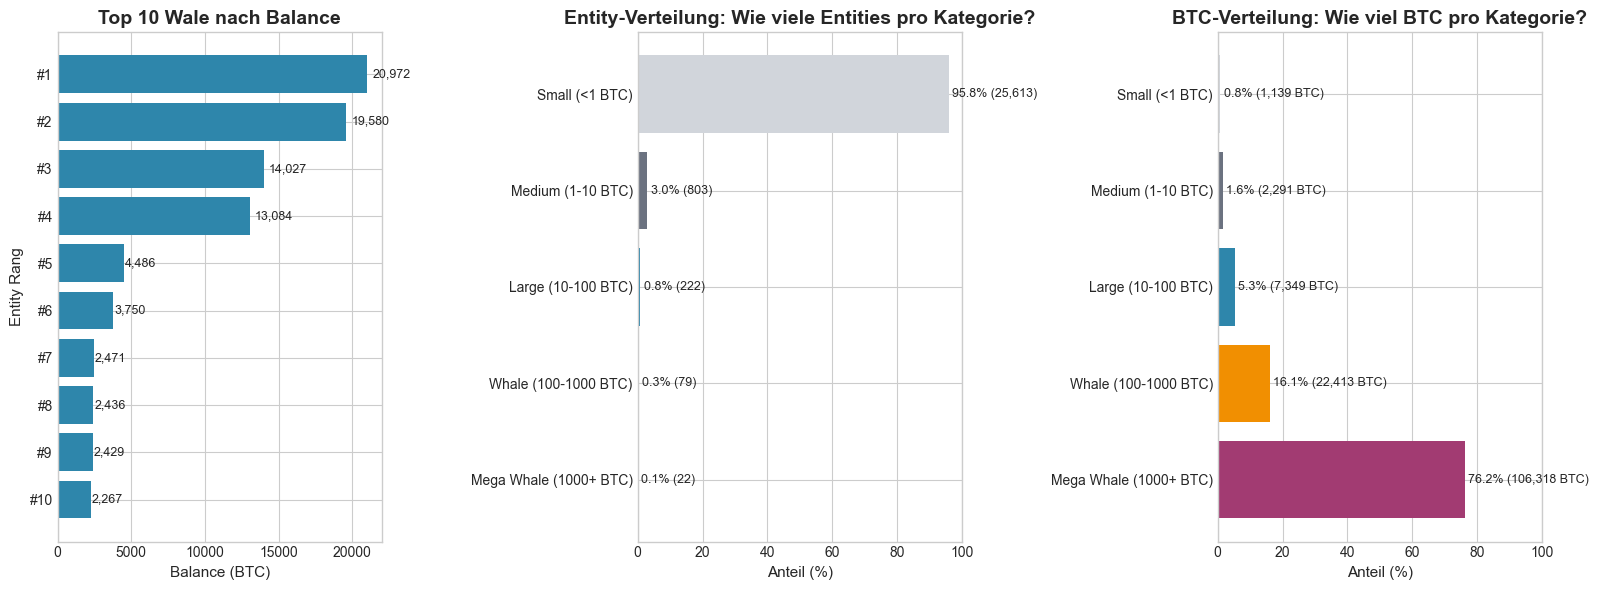


Interpretation:
- Links: Die absoluten Balancen der größten Wale
- Mitte: Wenige Mega Whales, viele kleine Entities
- Rechts: Mega Whales halten den Grossteil der BTC (extreme Konzentration)


In [20]:
# ==============================================================================
# VISUALISIERUNG: Whale-Verteilung als Balkendiagramme
# ==============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Chart 1: Top 10 Wale (bleibt gleich)
top_10 = entity_balances.limit(10).toPandas()
bars = axes[0].barh(range(len(top_10)), top_10["balance_btc"], color=COLORS["primary"])
axes[0].set_xlabel("Balance (BTC)")
axes[0].set_ylabel("Entity Rang")
axes[0].set_title("Top 10 Wale nach Balance")
axes[0].set_yticks(range(len(top_10)))
axes[0].set_yticklabels([f"#{i + 1}" for i in range(len(top_10))])
axes[0].invert_yaxis()
for bar, val in zip(bars, top_10["balance_btc"], strict=False):
    axes[0].text(val + val * 0.02, bar.get_y() + bar.get_height() / 2, f"{val:,.0f}", va="center", fontsize=9)

# Chart 2: Entity-Verteilung (horizontales Balkendiagramm)
colors_bar = [COLORS["secondary"], COLORS["accent"], COLORS["primary"], "#6B7280", "#D1D5DB"]
y_pos = range(len(category_stats))
entity_pct = category_stats["entity_count"] / category_stats["entity_count"].sum() * 100

bars2 = axes[1].barh(y_pos, entity_pct, color=colors_bar[: len(category_stats)])
axes[1].set_xlabel("Anteil (%)")
axes[1].set_title("Entity-Verteilung: Wie viele Entities pro Kategorie?")
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(category_stats["category"])
axes[1].set_xlim(0, 100)
for bar, pct, cnt in zip(bars2, entity_pct, category_stats["entity_count"], strict=False):
    axes[1].text(pct + 1, bar.get_y() + bar.get_height() / 2, f"{pct:.1f}% ({cnt:,})", va="center", fontsize=9)

# Chart 3: BTC-Verteilung (horizontales Balkendiagramm)
btc_pct = category_stats["total_btc"] / category_stats["total_btc"].sum() * 100

bars3 = axes[2].barh(y_pos, btc_pct, color=colors_bar[: len(category_stats)])
axes[2].set_xlabel("Anteil (%)")
axes[2].set_title("BTC-Verteilung: Wie viel BTC pro Kategorie?")
axes[2].set_yticks(y_pos)
axes[2].set_yticklabels(category_stats["category"])
axes[2].set_xlim(0, 100)
for bar, pct, btc in zip(bars3, btc_pct, category_stats["total_btc"], strict=False):
    axes[2].text(pct + 1, bar.get_y() + bar.get_height() / 2, f"{pct:.1f}% ({btc:,.0f} BTC)", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(str(Path(OUTPUT_PATH) / "whale_analysis.png"), dpi=150, bbox_inches="tight")
plt.show()

print("")
print("Interpretation:")
print("- Links: Die absoluten Balancen der größten Wale")
print("- Mitte: Wenige Mega Whales, viele kleine Entities")
print("- Rechts: Mega Whales halten den Grossteil der BTC (extreme Konzentration)")

---
## 12.1 Warum reicht ein Snapshot nicht aus?

Bisher wurde die **aktuelle** Verteilung der Bitcoin-Bestände analysiert. Aber ein statischer Snapshot beantwortet wichtige Fragen nicht:

- **Sind diese Whales Akkumulatoren oder Trader?** Halten sie langfristig oder handeln sie aktiv?
- **Wie hat sich die Konzentration entwickelt?** Werden die Großen größer?
- **Gibt es Sentiment-Signale?** Kaufen Whales vor Preisanstiegen?

Um diese Fragen zu beantworten, ist eine **Zeitreihen-Analyse** erforderlich - die Analyse betrachtet nicht nur *wer* die Whales sind, sondern *was sie mit ihren Bitcoins tun*.

Die folgenden Schritte rekonstruieren die **Balance-Historie** jeder Entity aus den Blockchain-Daten.

---
## 13. Zeitreihen-Analyse: Whale-Balance über Zeit

```
┌─────────────────────────────────────────────────────────────────────────────┐
│                    WARUM ZEITREIHEN-ANALYSE?                                │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│   Bisher: Snapshot                        Neu: Historie                     │
│                                                                             │
│   ┌─────────────────────┐                ┌─────────────────────────────┐    │
│   │ Entity 1: 1000 BTC  │                │ Entity 1:                   │    │
│   │ (Stand: heute)      │                │                             │    │
│   └─────────────────────┘                │  1000 ┤        ╭───────     │    │
│                                          │   800 ┤    ╭───╯            │    │
│   Wir wissen:                            │   600 ┤ ╭──╯                │    │
│   - Aktueller Stand                      │   400 ┤╭╯                   │    │
│   - Anzahl UTXOs                         │       └─────────────────▶   │    │
│                                          │        2015   2020   2024   │    │
│   Wir wissen NICHT:                      │                             │    │
│   - Seit wann?                           │   Akkumulation erkennbar!   │    │
│   - Kauft oder verkauft?                 └─────────────────────────────┘    │
│   - Wachstums-Trend?                                                        │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
```

**Ziel:** Für jede Entity rekonstruieren, wie sich das Guthaben über Zeit entwickelt hat.

**Ansatz:**
1. Jeden Output mit Erstellungs-Zeitpunkt tracken (+BTC)
2. Jeden Input mit Ausgabe-Zeitpunkt tracken (-BTC)
3. Kumulative Summe = Balance zu jedem Zeitpunkt

### Verwendete Techniken

**Event Sourcing:** Anstatt den aktuellen Kontostand zu speichern, werden alle Änderungen als einzelne Events erfasst. Jeder UTXO erzeugt zwei Events:
- `CREATED (+BTC)`: Wenn der Output in einer Transaktion entsteht
- `SPENT (-BTC)`: Wenn der Output in einer späteren Transaktion ausgegeben wird

Der aktuelle Kontostand ergibt sich aus der Summe aller vergangenen Events.

**Window Functions:** SQL-Funktionen die über eine geordnete Menge von Zeilen arbeiten. Hier verwendet für die kumulative Summe:

```sql
SUM(delta) OVER (
    PARTITION BY entity_id    -- Pro Entity separat
    ORDER BY event_date       -- Chronologisch sortiert
)
```

**Warum diese Kombination?**
- Spark berechnet die Window Function parallel für jede Entity (Partition)
- Keine iterative Schleife nötig - eine einzige SQL-Operation
- Skaliert auf Millionen von Events

> **Fail-Safe:** Die Balance-Timeline wird als `entity_balance_timeline.parquet` materialisiert. Diese Berechnung (Window Functions über alle Events) ist rechenintensiv.
> 
> **Parallelisierung:** Window Functions (`spark_sum().over(window_spec)`) werden partitionsweise parallel ausgeführt. Jede Entity wird unabhängig berechnet.

### 13.1 UTXO History erstellen

```
┌─────────────────────────────────────────────────────────────────────────────┐
│                         OUTPUTS (mit Zeitstempel)                           │
├─────────────────────────────────────────────────────────────────────────────┤
│  tx_hash │ idx │  value  │ address │ created_at (block_timestamp)           │
│  abc123  │  0  │ 50 BTC  │   1A... │ 2015-01-01                             │
│  abc123  │  1  │ 10 BTC  │   1B... │ 2015-01-01                             │
│  def456  │  0  │ 30 BTC  │   1A... │ 2018-06-15                             │
└─────────────────────────────────────────────────────────────────────────────┘
                                    │
                                    ▼ LEFT JOIN mit Inputs
┌─────────────────────────────────────────────────────────────────────────────┐
│                         UTXO HISTORY                                        │
├─────────────────────────────────────────────────────────────────────────────┤
│  tx_hash │ idx │  value  │ address │ created_at  │ spent_at                 │
│  abc123  │  0  │ 50 BTC  │   1A... │ 2015-01-01  │ 2018-06-15  (spent!)     │
│  abc123  │  1  │ 10 BTC  │   1B... │ 2015-01-01  │ NULL        (UTXO)       │
│  def456  │  0  │ 30 BTC  │   1A... │ 2018-06-15  │ NULL        (UTXO)       │
└─────────────────────────────────────────────────────────────────────────────┘
```

**Warum?** Um Balance über Zeit zu berechnen, brauchen wir für jeden Output:
- `created_at`: Wann wurde er erstellt? (= Einzahlung auf die Adresse)
- `spent_at`: Wann wurde er ausgegeben? (= Auszahlung, NULL wenn noch UTXO)

In [21]:
%%time
# ==============================================================================
# UTXO HISTORY: Jeden Output mit Erstellungs- und Ausgabe-Zeitpunkt
# ==============================================================================

from pyspark.sql.functions import date_trunc
from pyspark.sql.window import Window

# Spent-Referenzen mit Zeitstempel (wann wurde der Output ausgegeben?)
spent_info = inputs_df.filter(~col("is_coinbase")).select(
    col("spent_tx_hash").alias("ref_tx_hash"),
    col("spent_output_index").alias("ref_output_index"),
    col("block_timestamp").alias("spent_timestamp"),
)

# Outputs mit Entity-ID anreichern (erste Adresse extrahieren)
outputs_with_addr = outputs_df.withColumn("address", element_at(col("addresses"), 1)).filter(col("address").isNotNull())

# Join mit Entities
outputs_with_entity = outputs_with_addr.join(entities_final, "address", "inner")

# UTXO History: LEFT JOIN mit spent_info
utxo_history = (
    outputs_with_entity.join(
        spent_info,
        (outputs_with_entity.tx_hash == spent_info.ref_tx_hash)
        & (outputs_with_entity.output_index == spent_info.ref_output_index),
        "left",
    )
    .select(
        outputs_with_entity.tx_hash,
        outputs_with_entity.output_index,
        outputs_with_entity.value,
        outputs_with_entity.address,
        outputs_with_entity.entity_id,
        col("block_timestamp").alias("created_timestamp"),
        col("spent_timestamp"),  # NULL wenn noch UTXO
    )
    .cache()
)

HISTORY_COUNT = utxo_history.count()
SPENT_IN_HISTORY = utxo_history.filter(col("spent_timestamp").isNotNull()).count()
UNSPENT_IN_HISTORY = HISTORY_COUNT - SPENT_IN_HISTORY

print("UTXO History erstellt")
print(f"{'=' * 50}")
print(f"Total Outputs mit Entity: {HISTORY_COUNT:,}")
print(f"Davon spent:              {SPENT_IN_HISTORY:,}")
print(f"Davon unspent (UTXOs):    {UNSPENT_IN_HISTORY:,}")

UTXO History erstellt
Total Outputs mit Entity: 9,944,564
Davon spent:              4,949,461
Davon unspent (UTXOs):    4,995,103
CPU times: user 17.8 ms, sys: 12.2 ms, total: 30.1 ms
Wall time: 40.6 s


### 13.2 Balance-Events erstellen

```
┌─────────────────────────────────────────────────────────────────────────────┐
│                         BALANCE EVENTS                                      │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│   Für jede Entity sammeln wir alle "Buchungen":                             │
│                                                                             │
│   ┌─────────────────────────────────────────────────────────────────────┐   │
│   │ entity_id │   datum    │   delta   │  event_type                    │   │
│   ├───────────┼────────────┼───────────┼────────────────────────────────┤   │
│   │     1     │ 2015-01-01 │  +50 BTC  │  CREATED (Output erstellt)     │   │
│   │     1     │ 2016-03-15 │  +20 BTC  │  CREATED                       │   │
│   │     1     │ 2018-06-15 │  -50 BTC  │  SPENT   (Output ausgegeben)   │   │
│   │     1     │ 2020-01-01 │ +100 BTC  │  CREATED                       │   │
│   └───────────┴────────────┴───────────┴────────────────────────────────┘   │
│                                                                             │
│   Dann: Kumulative Summe = Balance zu jedem Zeitpunkt                       │
│                                                                             │
│   2015-01-01:  +50         =   50 BTC                                       │
│   2016-03-15:  +50 +20     =   70 BTC                                       │
│   2018-06-15:  +50 +20 -50 =   20 BTC                                       │
│   2020-01-01:  ... +100    =  120 BTC                                       │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
```

In [22]:
%%time
# ==============================================================================
# BALANCE EVENTS: +delta für Created, -delta für Spent
# ==============================================================================

# Event 1: Output erstellt = +value (Einzahlung)
created_events = utxo_history.select(
    col("entity_id"),
    date_trunc("day", from_unixtime(col("created_timestamp"))).alias("event_date"),
    col("value").alias("delta"),
    lit("CREATED").alias("event_type"),
)

# Event 2: Output spent = -value (Auszahlung)
spent_events = utxo_history.filter(col("spent_timestamp").isNotNull()).select(
    col("entity_id"),
    date_trunc("day", from_unixtime(col("spent_timestamp"))).alias("event_date"),
    (-col("value")).alias("delta"),
    lit("SPENT").alias("event_type"),
)

# Alle Events zusammenführen
balance_events = created_events.unionAll(spent_events).cache()

EVENT_COUNT = balance_events.count()
CREATED_COUNT = balance_events.filter(col("event_type") == "CREATED").count()
SPENT_EVENT_COUNT = balance_events.filter(col("event_type") == "SPENT").count()

print("Balance Events erstellt")
print(f"{'=' * 50}")
print(f"Total Events:    {EVENT_COUNT:,}")
print(f"CREATED (+BTC):  {CREATED_COUNT:,}")
print(f"SPENT (-BTC):    {SPENT_EVENT_COUNT:,}")

Balance Events erstellt
Total Events:    14,894,025
CREATED (+BTC):  9,944,564
SPENT (-BTC):    4,949,461
CPU times: user 15.6 ms, sys: 10.2 ms, total: 25.7 ms
Wall time: 8.1 s


In [23]:
%%time
# ==============================================================================
# DAILY BALANCE TIMELINE: Kumulative Summe pro Entity
# ==============================================================================

# Aggregation: Netto-Veränderung pro Entity und Tag
daily_changes = balance_events.groupBy("entity_id", "event_date").agg(spark_sum("delta").alias("daily_delta"))

# Window Function: Kumulative Summe über Zeit
window_spec = (
    Window.partitionBy("entity_id").orderBy("event_date").rowsBetween(Window.unboundedPreceding, Window.currentRow)
)

entity_balance_timeline = (
    daily_changes.withColumn("cumulative_satoshi", spark_sum("daily_delta").over(window_spec))
    .withColumn("daily_delta_btc", spark_round(col("daily_delta") / 100000000, 4))
    .withColumn("cumulative_btc", spark_round(col("cumulative_satoshi") / 100000000, 4))
    .orderBy("entity_id", "event_date")
)

# Materialisieren statt cache() für LARGE_DATASET_MODE
timeline_path = str(Path(OUTPUT_PATH) / "entity_balance_timeline.parquet")
entity_balance_timeline.write.mode("overwrite").parquet(timeline_path)
entity_balance_timeline = spark.read.parquet(timeline_path)

TIMELINE_ROWS = entity_balance_timeline.count()
TIMELINE_ENTITIES = entity_balance_timeline.select("entity_id").distinct().count()

print("Balance Timeline erstellt")
print(f"{'=' * 50}")
print(f"Timeline-Einträge: {TIMELINE_ROWS:,}")
print(f"Entities mit Historie: {TIMELINE_ENTITIES:,}")

# Timeline einer Entity anzeigen (echte Werte in BTC!)
print("\nTimeline von Top Whale (alle Werte in BTC):")
top_entity_id = entity_balances.first()["entity_id"]
entity_balance_timeline.filter(col("entity_id") == top_entity_id).select(
    "event_date", "daily_delta_btc", "cumulative_btc"
).orderBy("event_date").show(10, truncate=False)

Balance Timeline erstellt
Timeline-Einträge: 896,210
Entities mit Historie: 362,560

Timeline von Top Whale (alle Werte in BTC):
+-------------------+---------------+--------------+
|event_date         |daily_delta_btc|cumulative_btc|
+-------------------+---------------+--------------+
|2024-01-16 00:00:00|4459.845       |4459.845      |
|2024-01-17 00:00:00|2229.9225      |6689.7675     |
|2024-01-18 00:00:00|8395.0024      |15084.7699    |
|2024-01-19 00:00:00|4263.0871      |19347.8571    |
|2024-01-22 00:00:00|5312.4625      |24660.3195    |
|2024-01-23 00:00:00|3957.0193      |28617.3388    |
|2024-01-24 00:00:00|-2806.0678     |25811.271     |
|2024-01-25 00:00:00|3169.9879      |28981.2589    |
|2024-01-26 00:00:00|2535.9903      |31517.2492    |
|2024-01-29 00:00:00|2382.9564      |33900.2056    |
+-------------------+---------------+--------------+
only showing top 10 rows
CPU times: user 15.1 ms, sys: 10.4 ms, total: 25.4 ms
Wall time: 14.6 s


### 13.3 Whale-Balance-Verläufe

Visualisierung der Balance-Entwicklung der Top 5 Whales über Zeit.

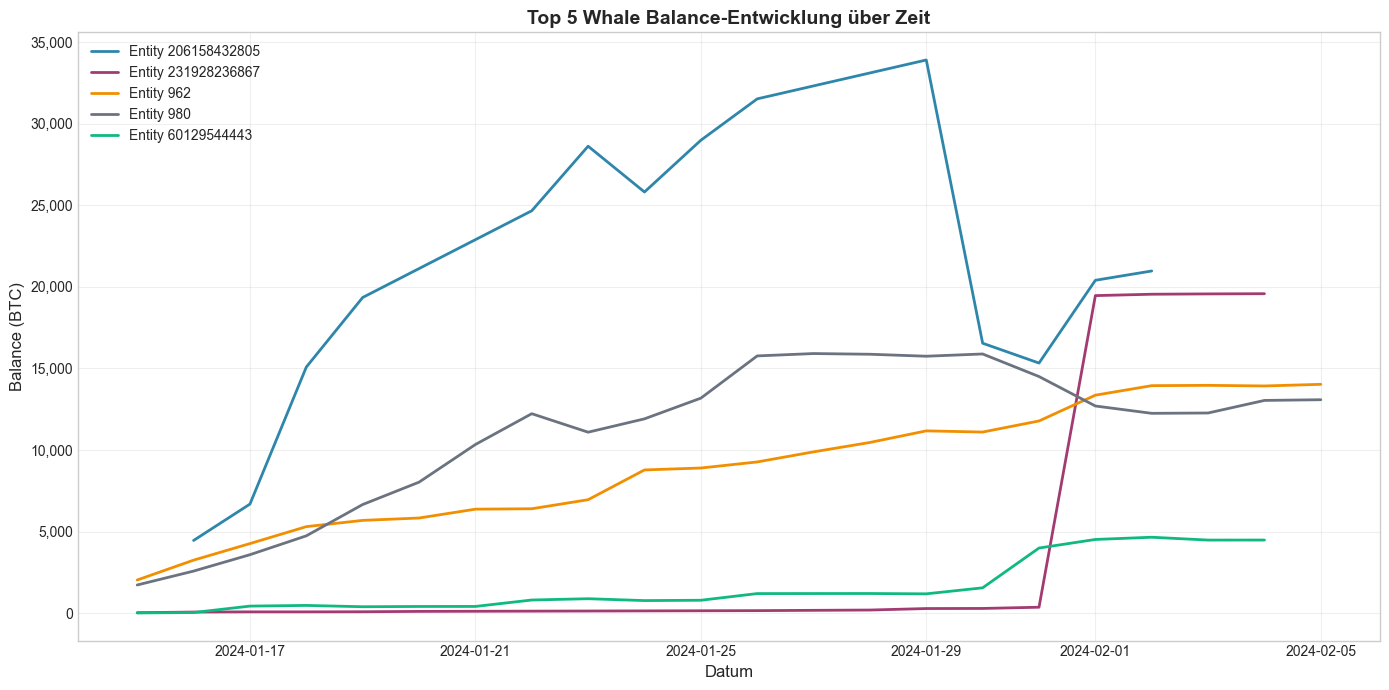

Top 5 Whale-Balance-Verläufe visualisiert.


In [24]:
# ==============================================================================
# VISUALISIERUNG: Top 5 Whale Balance über Zeit
# ==============================================================================

# Top 5 Whales nach aktuellem Balance
top_5_whales = entity_balances.limit(5).select("entity_id").toPandas()["entity_id"].tolist()

# Timeline für Top 5 extrahieren
top_whale_timeline = (
    entity_balance_timeline.filter(col("entity_id").isin(top_5_whales))
    .select("entity_id", "event_date", "cumulative_btc")
    .toPandas()
)

# Plot erstellen
fig, ax = plt.subplots(figsize=(14, 7))

colors_line = [COLORS["primary"], COLORS["secondary"], COLORS["accent"], "#6B7280", "#10B981"]

for i, entity_id in enumerate(top_5_whales):
    entity_data = top_whale_timeline[top_whale_timeline["entity_id"] == entity_id].sort_values("event_date")
    if len(entity_data) > 0:
        ax.plot(
            entity_data["event_date"],
            entity_data["cumulative_btc"],
            label=f"Entity {entity_id}",
            color=colors_line[i % len(colors_line)],
            linewidth=2,
        )

ax.set_xlabel("Datum", fontsize=12)
ax.set_ylabel("Balance (BTC)", fontsize=12)
ax.set_title("Top 5 Whale Balance-Entwicklung über Zeit", fontsize=14, fontweight="bold")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)

# Y-Achse formatieren
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:,.0f}"))  # noqa: ARG005

plt.tight_layout()
plt.savefig(str(Path(OUTPUT_PATH) / "whale_timeline.png"), dpi=150, bbox_inches="tight")
plt.show()

print("Top 5 Whale-Balance-Verläufe visualisiert.")

### 13.4 Kategorien über Zeit

In diesem Abschnitt wird analysiert, wie sich die BTC-Verteilung zwischen den verschiedenen Kategorien im Laufe der Zeit verändert hat.

#### Visualisierung: Gestapeltes Flächendiagramm

Das folgende Diagramm zeigt die prozentuale Verteilung der Bitcoin-Bestände auf die verschiedenen Kategorien über die Zeit:

- **Mega Whales (1000+ BTC):** Halten typischerweise den größten Anteil
- **Whales (100-1000 BTC):** Zweite große Kategorie
- **Large (10-100 BTC):** Mittlere Holder
- **Medium/Small (<10 BTC):** Kleinere Adressen

#### Zentrale Fragestellung

Wie hat sich die Konzentration der Bitcoin-Bestände über die Zeit verändert? Werden die Reichen reicher, oder findet eine Umverteilung statt?

In [25]:
# ==============================================================================
# KATEGORIE-BALANCE ÜBER ZEIT
# ==============================================================================
from pyspark.sql.functions import concat_ws, month, year

# Entity-Kategorien mit Timeline verbinden
# Hinweis: Wir verwenden die AKTUELLE Kategorie (vereinfacht)
entity_with_category = entity_balances.select(
    col("entity_id"),
    when(col("balance_btc") >= 1000, "Mega Whale (1000+ BTC)")
    .when(col("balance_btc") >= 100, "Whale (100-1000 BTC)")
    .when(col("balance_btc") >= 10, "Large (10-100 BTC)")
    .otherwise("Small/Medium (<10 BTC)")
    .alias("category"),
)

# Timeline mit Kategorie joinen
timeline_with_category = entity_balance_timeline.join(entity_with_category, "entity_id", "inner")

# Aggregation pro Datum und Kategorie (monatlich für bessere Übersicht)
monthly_category_balance = (
    timeline_with_category.withColumn("year_month", concat_ws("-", year(col("event_date")), month(col("event_date"))))
    .groupBy("year_month", "category")
    .agg(spark_sum("cumulative_btc").alias("total_btc"))
    .orderBy("year_month", "category")
    .toPandas()
)

print(f"Monatliche Kategorie-Aggregation: {len(monthly_category_balance)} Einträge")
print(monthly_category_balance.head(10))

Monatliche Kategorie-Aggregation: 8 Einträge
  year_month                category    total_btc
0     2024-1      Large (10-100 BTC)  103599.5445
1     2024-1  Mega Whale (1000+ BTC)  890209.8620
2     2024-1  Small/Medium (<10 BTC)   87561.6339
3     2024-1    Whale (100-1000 BTC)  291351.6499
4     2024-2      Large (10-100 BTC)   19083.0322
5     2024-2  Mega Whale (1000+ BTC)  389606.9080
6     2024-2  Small/Medium (<10 BTC)   11058.7249
7     2024-2    Whale (100-1000 BTC)   78807.9320


In [26]:
# ==============================================================================
# AKKUMULATION VS DISTRIBUTION: Netto-Veränderung der Whales
# ==============================================================================

# Nur Whale-Kategorien (>= 100 BTC)
whale_entity_ids = (
    entity_balances.filter(col("balance_btc") >= 100).select("entity_id").toPandas()["entity_id"].tolist()
)

# Monatliche Netto-Veränderung aller Whales zusammen
whale_monthly_change = (
    balance_events.filter(col("entity_id").isin(whale_entity_ids))
    .withColumn(
        "year_month",
        concat_ws(
            "-",
            year(col("event_date")),
            when(month(col("event_date")) < 10, concat_ws("", lit("0"), month(col("event_date")))).otherwise(
                month(col("event_date"))
            ),
        ),
    )
    .groupBy("year_month")
    .agg(
        spark_sum("delta").alias("net_change_satoshi"),
        spark_sum(when(col("delta") > 0, col("delta")).otherwise(0)).alias("inflows"),
        spark_sum(when(col("delta") < 0, col("delta")).otherwise(0)).alias("outflows"),
    )
    .withColumn("net_change_btc", spark_round(col("net_change_satoshi") / 100000000, 2))
    .withColumn("inflows_btc", spark_round(col("inflows") / 100000000, 2))
    .withColumn("outflows_btc", spark_round(col("outflows") / 100000000, 2))
    .orderBy("year_month")
    .toPandas()
)

print("Whale Akkumulation/Distribution Analyse")
print(f"{'=' * 60}")
print(f"Zeiträume analysiert: {len(whale_monthly_change)}")
print("\nLetzte 12 Monate:")
print(
    whale_monthly_change.tail(12)[["year_month", "net_change_btc", "inflows_btc", "outflows_btc"]].to_string(
        index=False
    )
)

Whale Akkumulation/Distribution Analyse
Zeiträume analysiert: 2

Letzte 12 Monate:
year_month  net_change_btc  inflows_btc  outflows_btc
    2024-1       115539.50   4358931.72   -4243392.22
    2024-2        13191.08    725606.80    -712415.73


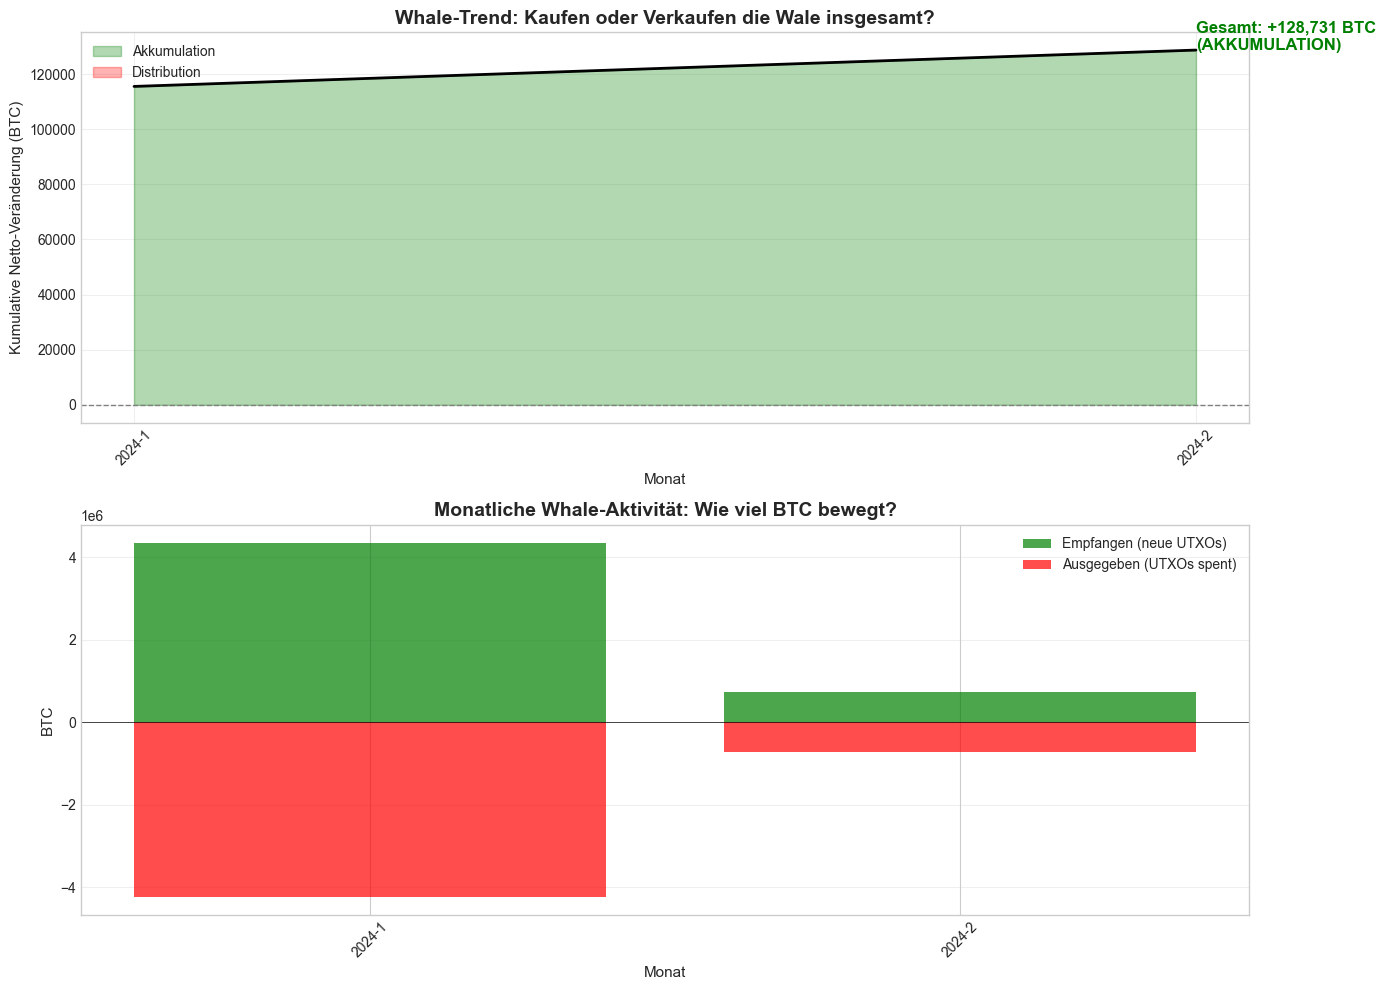


Was zeigen diese Grafiken?

Chart 1 - Kumulativer Trend:
  Zeigt ob Whales INSGESAMT mehr kaufen oder verkaufen.
  Grün = Akkumulation (Whales horten BTC)
  Rot = Distribution (Whales verkaufen BTC)

Chart 2 - Monatliche Aktivität:
  Grüne Balken = BTC die Whales ERHALTEN haben
  Rote Balken = BTC die Whales AUSGEGEBEN haben
  Je höher die Balken, desto mehr Aktivität.


In [27]:
# ==============================================================================
# VISUALISIERUNG: Whale-Aktivität über Zeit
# ==============================================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Nur die letzten 24 Monate (oder alle, wenn weniger)
recent_data = whale_monthly_change.tail(24).copy()

if len(recent_data) > 0:
    # Chart 1: Kumulative Netto-Veränderung (zeigt Trend besser)
    recent_data["cumulative_net"] = recent_data["net_change_btc"].cumsum()

    ax1 = axes[0]
    ax1.fill_between(
        range(len(recent_data)),
        recent_data["cumulative_net"],
        where=recent_data["cumulative_net"] >= 0,
        alpha=0.3,
        color="green",
        label="Akkumulation",
    )
    ax1.fill_between(
        range(len(recent_data)),
        recent_data["cumulative_net"],
        where=recent_data["cumulative_net"] < 0,
        alpha=0.3,
        color="red",
        label="Distribution",
    )
    ax1.plot(range(len(recent_data)), recent_data["cumulative_net"], color="black", linewidth=2)
    ax1.axhline(y=0, color="gray", linestyle="--", linewidth=1)
    ax1.set_xlabel("Monat")
    ax1.set_ylabel("Kumulative Netto-Veränderung (BTC)")
    ax1.set_title("Whale-Trend: Kaufen oder Verkaufen die Wale insgesamt?", fontsize=14, fontweight="bold")
    ax1.set_xticks(range(0, len(recent_data), max(1, len(recent_data) // 6)))
    ax1.set_xticklabels(
        [recent_data["year_month"].iloc[i] for i in range(0, len(recent_data), max(1, len(recent_data) // 6))],
        rotation=45,
    )
    ax1.legend(loc="upper left")
    ax1.grid(True, alpha=0.3)

    # Annotation
    final_value = recent_data["cumulative_net"].iloc[-1]
    trend_text = "AKKUMULATION" if final_value > 0 else "DISTRIBUTION"
    ax1.annotate(
        f"Gesamt: {final_value:+,.0f} BTC\n({trend_text})",
        xy=(len(recent_data) - 1, final_value),
        fontsize=12,
        fontweight="bold",
        color="green" if final_value > 0 else "red",
    )

    # Chart 2: Monatliche Aktivität (Inflows vs Outflows)
    x = range(len(recent_data))
    width = 0.8

    # Stacked bar: Inflows oben, Outflows unten
    axes[1].bar(x, recent_data["inflows_btc"], width, label="Empfangen (neue UTXOs)", color="green", alpha=0.7)
    axes[1].bar(x, recent_data["outflows_btc"], width, label="Ausgegeben (UTXOs spent)", color="red", alpha=0.7)
    axes[1].axhline(y=0, color="black", linestyle="-", linewidth=0.5)
    axes[1].set_xlabel("Monat")
    axes[1].set_ylabel("BTC")
    axes[1].set_title("Monatliche Whale-Aktivität: Wie viel BTC bewegt?", fontsize=14, fontweight="bold")
    axes[1].set_xticks(range(0, len(recent_data), max(1, len(recent_data) // 6)))
    axes[1].set_xticklabels(
        [recent_data["year_month"].iloc[i] for i in range(0, len(recent_data), max(1, len(recent_data) // 6))],
        rotation=45,
    )
    axes[1].legend(loc="upper right")
    axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(str(Path(OUTPUT_PATH) / "whale_activity.png"), dpi=150, bbox_inches="tight")
plt.show()

# Erklärung
print("")
print("Was zeigen diese Grafiken?")
print("=" * 60)
print("")
print("Chart 1 - Kumulativer Trend:")
print("  Zeigt ob Whales INSGESAMT mehr kaufen oder verkaufen.")
print("  Grün = Akkumulation (Whales horten BTC)")
print("  Rot = Distribution (Whales verkaufen BTC)")
print("")
print("Chart 2 - Monatliche Aktivität:")
print("  Grüne Balken = BTC die Whales ERHALTEN haben")
print("  Rote Balken = BTC die Whales AUSGEGEBEN haben")
print("  Je höher die Balken, desto mehr Aktivität.")

### Interpretation der Zeitreihen-Analyse
Die Zeitreihen-Analyse liefert wertvolle Erkenntnisse über das Verhalten von Bitcoin-Walen. Im Folgenden werden die wichtigsten Aspekte zusammengefasst.

#### 1. Whale-Balance-Verläufe
Die Balance-Verläufe der größten Entities zeigen unterschiedliche Strategien:

- **Akkumulatoren vs. Trader:** Einige Wale akkumulieren kontinuierlich, während andere aktiv handeln
- **Sprunghafte Anstiege:** Deuten auf große Einzeltransaktionen hin
- **Flache Linien:** HODLer, die ihre Bestände ohne Aktivität halten

#### 2. Akkumulation vs. Distribution
Die aggregierten Balance-Änderungen zeigen Markttrends:

- **Grüne Balken:** Whales kaufen netto (Akkumulationsphase)
- **Rote Balken:** Whales verkaufen netto (Distributionsphase)
- Diese Daten können als Sentiment-Indikator für den Gesamtmarkt verwendet werden

#### 3. Limitationen der Analyse
Bei der Interpretation sollten folgende Einschränkungen beachtet werden:

- **Clustering-Grenzen:** Nur Adressen aus Multi-Input Transaktionen sind geclustert
- **Exchange-Wallets:** Große Börsen verwalten Millionen von Nutzer-Geldern in wenigen Wallets
- **Multi-Sig-Limitation:** Bei Adressen mit mehreren Signern wird nur die erste Adresse erfasst
- **Temporaler Bias:** Die Kategorie-Zuordnung basiert auf dem aktuellen Stand, nicht auf historischen Werten

#### 4. Warum Spark hier nötig ist
Diese Analyse erfordert erhebliche Rechenressourcen:

- Window Functions müssen über Millionen von Events berechnet werden
- Partitionierung nach Entity ermöglicht parallele Berechnung
- Bei 900+GB Blockchain-Daten ist diese Analyse nur mit einem Cluster skalierbar

In [28]:
# Daten speichern (nur was noch nicht geschrieben wurde)
from pathlib import Path


def save_if_needed(df: DataFrame, path: str, name: str) -> None:
    """Speichert DataFrame nur wenn Pfad nicht existiert oder leer ist."""
    p = Path(path)
    if not p.exists() or not any(p.iterdir()):
        print(f"Speichere {name}...")
        df.write.mode("overwrite").parquet(path)
    else:
        print(f"✓ {name} existiert bereits")


save_if_needed(entities_final, str(Path(OUTPUT_PATH) / "entities.parquet"), "entities")
# utxos, outputs, inputs wurden bereits materialisiert in früheren Zellen
print(f"\n✓ Alle Daten in {OUTPUT_PATH}")

✓ entities existiert bereits

✓ Alle Daten in ../output


---
## 14. Executive Summary

### Zielsetzung

Dieses Notebook demonstriert eine vollständige Pipeline zur Identifikation von Bitcoin-"Walen" (Entitäten mit großen BTC-Beständen) unter Verwendung von Apache Spark für Big Data Processing.

### Methodik

Die Analyse basiert auf der **Common Input Ownership Heuristic**, die besagt:

> *"Wenn mehrere Inputs in einer Transaktion verwendet werden, gehören diese mit hoher Wahrscheinlichkeit derselben Entität."*

Diese Heuristic ermöglicht es, pseudonyme Bitcoin-Adressen zu Entitäten (Personen oder Organisationen) zu gruppieren.

### Pipeline-Schritte

1. **Datenextraktion:** Bitcoin-Transaktionen aus JSON (bitcoin-etl Format)
2. **UTXO-Berechnung:** Identifikation unverbrauchter Outputs via LEFT ANTI JOIN
3. **Graph-Konstruktion:** Adressen als Knoten, Multi-Input-TXs als Kanten
4. **Clustering:** Connected Components Algorithmus (GraphFrames)
5. **Whale Detection:** Aggregation der Balances pro Entity
6. **Zeitreihen-Analyse:** Balance-Entwicklung über Zeit

### Wichtige Erkenntnisse

- **Konzentration:** Die Top-20 Whales halten einen signifikanten Anteil der analysierten BTC
- **Reduktion:** Durch Clustering werden viele Adressen zu wenigen Entitäten zusammengefasst
- **Balance-Verläufe:** Whale-Verhalten zeigt unterschiedliche Strategien (Akkumulatoren vs. Trader)

### Limitationen

- **Exchange-Wallets:** Große Börsen verzerren die Whale-Verteilung
- **Multi-Sig:** Adressen mit mehreren Signern werden nur teilweise erfasst
- **Datenumfang:** Analyse basiert auf einem Subset der Blockchain

### Technologie-Stack

- **Apache Spark 3.5+** für verteilte Datenverarbeitung
- **GraphFrames** für Graph-Algorithmen (Connected Components)
- **Parquet** für effiziente Zwischenspeicherung
- **Matplotlib/Seaborn** für Visualisierungen

In [29]:
# Zusammenfassung - Bei LARGE_DATASET_MODE Werte nachladen
if LARGE_DATASET_MODE:
    print("Lade finale Statistiken...")
    if TX_COUNT is None:
        TX_COUNT = tx_df.count()
    if OUTPUT_COUNT is None:
        OUTPUT_COUNT = outputs_df.count()
    if UTXO_COUNT is None:
        UTXO_COUNT = utxo_df.count()
    if ADDRESS_COUNT is None:
        ADDRESS_COUNT = entities_df.count()
    if ENTITY_COUNT is None:
        ENTITY_COUNT = entities_df.select("component").distinct().count()
    if ENTITIES_WITH_BALANCE is None:
        ENTITIES_WITH_BALANCE = entity_balances.count()
    if TOTAL_BTC is None:
        TOTAL_BTC = entity_balances.agg(spark_sum("balance_btc")).collect()[0][0] or 0

SPENT_COUNT = OUTPUT_COUNT - UTXO_COUNT
MEGA_WHALE_BTC = entity_balances.filter(col("balance_btc") >= 1000).agg(spark_sum("balance_btc")).collect()[0][0] or 0
MEGA_WHALE_COUNT = entity_balances.filter(col("balance_btc") >= 1000).count()
MEGA_WHALE_SHARE = MEGA_WHALE_BTC / TOTAL_BTC * 100 if TOTAL_BTC and TOTAL_BTC > 0 else 0

# Ensure REDUCTION is computed
if "REDUCTION" not in dir() or REDUCTION is None:
    REDUCTION = (1 - ENTITY_COUNT / ADDRESS_COUNT) * 100 if ADDRESS_COUNT > 0 else 0

print(f"""
{"=" * 60}
                    ANALYSE ZUSAMMENFASSUNG
{"=" * 60}

DATENUMFANG
  Transaktionen:           {TX_COUNT:>15,}
  Outputs erstellt:        {OUTPUT_COUNT:>15,}
  UTXOs (unspent):         {UTXO_COUNT:>15,}
  Spent Outputs:           {SPENT_COUNT:>15,}

ENTITY CLUSTERING
  Adressen geclustert:     {ADDRESS_COUNT:>15,}
  Entities identifiziert:  {ENTITY_COUNT:>15,}
  Reduktion:               {REDUCTION:>14.1f}%

WHALE DETECTION
  Total BTC erfasst:       {TOTAL_BTC:>15,.2f} BTC
  Entities mit Balance:    {ENTITIES_WITH_BALANCE:>15,}
  Mega-Whales (1000+ BTC): {MEGA_WHALE_COUNT:>15,} ({MEGA_WHALE_BTC:,.2f} BTC = {MEGA_WHALE_SHARE:.1f}%)

{"=" * 60}
""")

Lade finale Statistiken...

                    ANALYSE ZUSAMMENFASSUNG

DATENUMFANG
  Transaktionen:                 9,940,221
  Outputs erstellt:             27,040,264
  UTXOs (unspent):              11,280,494
  Spent Outputs:                15,759,770

ENTITY CLUSTERING
  Adressen geclustert:           2,430,771
  Entities identifiziert:          439,142
  Reduktion:                         81.9%

WHALE DETECTION
  Total BTC erfasst:            139,509.67 BTC
  Entities mit Balance:             26,739
  Mega-Whales (1000+ BTC):              22 (106,317.70 BTC = 76.2%)




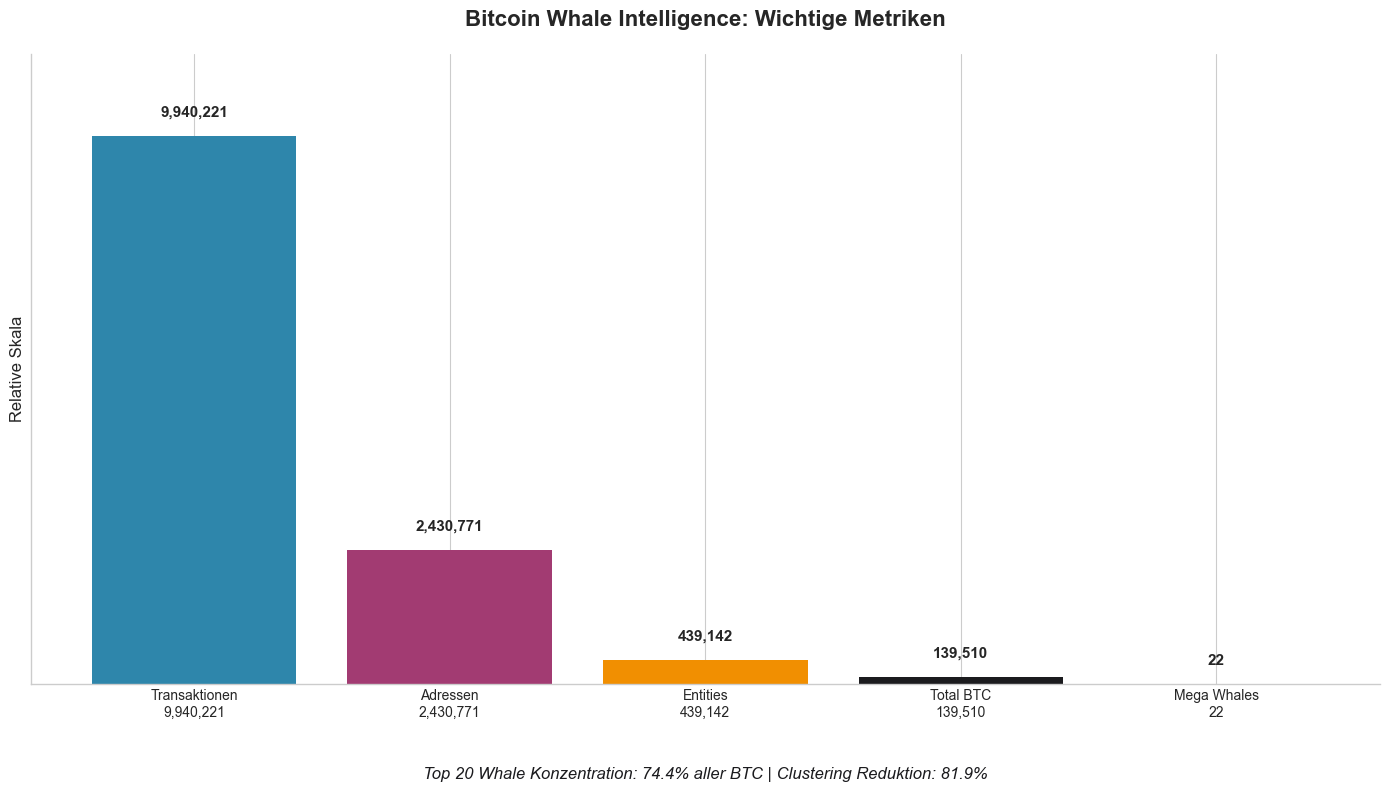

In [30]:
# Abschluss-Visualisierung: Key Metrics Overview
fig, ax = plt.subplots(figsize=(14, 8))

# Ensure all values are available (fallback to 0)
_tx = TX_COUNT or 0
_addr = ADDRESS_COUNT or 0
_ent = ENTITY_COUNT or 0
_btc = TOTAL_BTC or 0
_whale = MEGA_WHALE_COUNT if "MEGA_WHALE_COUNT" in dir() else 0

metrics = [
    f"Transaktionen\n{_tx:,}",
    f"Adressen\n{_addr:,}",
    f"Entities\n{_ent:,}",
    f"Total BTC\n{_btc:,.0f}",
    f"Mega Whales\n{_whale}",
]
values = [_tx, _addr, _ent, _btc, _whale]
max_val = max(values) if max(values) > 0 else 1
normalized = [v / max_val for v in values]

bars = ax.bar(
    metrics,
    normalized,
    color=[COLORS["primary"], COLORS["secondary"], COLORS["accent"], COLORS["dark"], COLORS["secondary"]],
)
ax.set_ylabel("Relative Skala", fontsize=12)
ax.set_title("Bitcoin Whale Intelligence: Wichtige Metriken", fontsize=16, fontweight="bold", pad=20)
ax.set_ylim(0, 1.15)

for bar, val, norm in zip(bars, values, normalized, strict=False):
    label = f"{val:,.0f}" if val >= 1000 else str(int(val))
    ax.text(
        bar.get_x() + bar.get_width() / 2, norm + 0.03, label, ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

# Safe access to TOP_20_SHARE and REDUCTION
_top20 = TOP_20_SHARE if "TOP_20_SHARE" in dir() else 0
_red = REDUCTION if "REDUCTION" in dir() else 0
ax.text(
    0.5,
    -0.15,
    f"Top 20 Whale Konzentration: {_top20:.1f}% aller BTC | Clustering Reduktion: {_red:.1f}%",
    transform=ax.transAxes,
    ha="center",
    fontsize=12,
    style="italic",
    color=COLORS["dark"],
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_yticks([])

plt.tight_layout()
plt.savefig(str(Path(OUTPUT_PATH) / "executive_summary.png"), dpi=150, bbox_inches="tight")
plt.show()

In [31]:
# Spark Session (optional beenden)
# spark.stop()
print("Analyse abgeschlossen. Spark Session bleibt weiter aktiv")

Analyse abgeschlossen. Spark Session bleibt weiter aktiv


---
## 15. Zusammenfassung: Die komplette Pipeline

```
┌─────────────────────────────────────────────────────────────────────────────┐
│                    BITCOIN WHALE INTELLIGENCE PIPELINE                      │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│   ┌─────────┐                                                               │
│   │  JSON   │  Blockchain-Daten von bitcoin-etl                             │
│   └────┬────┘                                                               │
│        │                                                                    │
│        ▼                                                                    │
│   ┌─────────────────────────────────────────────────────┐                   │
│   │ Schritt 1+2: Outputs & Inputs extrahieren (explode) │                   │
│   └────────────────────────┬────────────────────────────┘                   │
│                            │                                                │
│        ┌───────────────────┼───────────────────┐                            │
│        ▼                   ▼                   ▼                            │
│   ┌─────────┐         ┌─────────┐         ┌─────────┐                       │
│   │ outputs │         │ inputs  │         │ inputs  │                       │
│   └────┬────┘         └────┬────┘         └────┬────┘                       │
│        │                   │                   │                            │
│        └─────────┬─────────┘                   │                            │
│                  ▼                             │                            │
│   ┌──────────────────────────┐                 │                            │
│   │ Schritt 3: UTXO berechnen│                 │                            │
│   │   (LEFT ANTI JOIN)       │                 │                            │
│   └────┬─────────────────────┘                 │                            │
│        │                                       │                            │
│        ▼                                       ▼                            │
│   ┌─────────┐              ┌───────────────────────────────┐                │
│   │  utxos  │              │ Schritt 4a: CoinJoin-Filter   │                │
│   └────┬────┘              │  (Whirlpool, Wasabi, Generic) │                │
│        │                   └───────────────┬───────────────┘                │
│        │                                   │                                │
│        │                                   ▼                                │
│        │                   ┌───────────────────────────────┐                │
│        │                   │ Schritt 4b: Multi-Input Kanten│                │
│        │                   │        (Adress-Paare)         │                │
│        │                   └───────────────┬───────────────┘                │
│        │                                   │                                │
│        │                                   ▼                                │
│        │                   ┌───────────────────────────────┐                │
│        │                   │ Schritt 4c: Connected         │                │
│        │                   │   Components (GraphFrames)    │                │
│        │                   └───────────────┬───────────────┘                │
│        │                                   │                                │
│        │                                   ▼                                │
│        │                              ┌─────────┐                           │
│        │                              │entities │                           │
│        │                              └────┬────┘                           │
│        │                                   │                                │
│        └─────────────────┬─────────────────┘                                │
│                          ▼                                                  │
│           ┌──────────────────────────────┐                                  │
│           │ Schritt 5: Whale Detection   │                                  │
│           │   (JOIN + GROUP BY + SUM)    │                                  │
│           └──────────────┬───────────────┘                                  │
│                          │                                                  │
│                          ▼                                                  │
│                     ┌─────────┐                                             │
│                     │  WALE   │  Entity-Balancen (Snapshot)                 │
│                     └────┬────┘                                             │
│                          │                                                  │
│   ┌──────────────────────┴───────────────────────────┐                      │
│   │                                                  │                      │
│   ▼                                                  ▼                      │
│   ┌──────────────────────────────┐    ┌──────────────────────────────┐      │
│   │ Schritt 6: Zeitreihen        │    │ Visualisierung               │      │
│   │   - UTXO History             │    │   - Top Whale Balancen       │      │
│   │   - Balance Events (+/-)     │    │   - Verteilung nach Kat.     │      │
│   │   - Window Functions         │    │   - Executive Summary        │      │
│   │   - Akkumulation/Distribution│    │                              │      │
│   └──────────────────────────────┘    └──────────────────────────────┘      │
│                  │                                                          │
│                  ▼                                                          │
│        ┌─────────────────────┐                                              │
│        │ Whale-Balance-Verläufe  │  Balance-Entwicklung über Zeit           │
│        └─────────────────────┘                                              │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
```

---
## 16. ResourceMonitor Framework

Das **ResourceMonitor Framework** misst kontinuierlich die Systemressourcen während der Pipeline-Ausführung und ermöglicht präzise Performance-Analysen für jeden einzelnen Pipeline-Schritt.

```
┌─────────────────────────────────────────────────────────────────────┐
│                    RESOURCEMONITOR: WAS WIRD GEMESSEN?              │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│   ┌──────────────────────────────────────────────────────────┐      │
│   │  WÄHREND DER PIPELINE-AUSFÜHRUNG                         │      │
│   │                                                          │      │
│   │  ZEIT                                                    │      │
│   │  ├─ Startzeit jedes Steps                                │      │
│   │  └─ Endzeit jedes Steps → Dauer in Sekunden              │      │
│   │                                                          │      │
│   │  CPU                                                     │      │
│   │  ├─ CPU-Auslastung % (alle Cores durchschnittlich)       │      │
│   │  └─ Sampling alle 0.5 Sekunden                           │      │
│   │                                                          │      │
│   │  RAM                                                     │      │
│   │  ├─ RAM-Nutzung in GB (RSS Memory)                       │      │
│   │  └─ Peak Memory für jeden Step                           │      │
│   │                                                          │      │
│   │  DISK I/O                                                │      │
│   │  ├─ Bytes gelesen/geschrieben                            │      │
│   │  └─ Disk-Throughput pro Step                             │      │
│   │                                                          │      │
│   └──────────────────────────────────────────────────────────┘      │
│                                                                     │
│   ABLAUF:                                                           │
│                                                                     │
│   Step 01 Start ──▶ Monitor misst (0.5s) ──▶ Step 01 Ende           │
│   │                      ↓                              │           │
│   │                  [CPU: 45%]                         │           │
│   │                  [RAM: 2.3 GB]                      │           │
│   │                  [Disk: 150 MB]                     │           │
│   │                                                     │           │
│   └─────────────────────────────────────────────────────┘           │
│                           ↓                                         │
│                   Metriken speichern                                │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

**Wie funktioniert der ResourceMonitor?**

1. **Background-Thread**: Der Monitor läuft parallel zur Pipeline in einem separaten Thread
2. **Sampling-Intervall**: Alle 0.5 Sekunden werden die aktuellen Systemwerte erfasst
3. **Step-basierte Aggregation**: Am Ende jedes Pipeline-Schritts werden Min/Max/Avg berechnet
4. **Keine Performance-Einbußen**: Der Monitor selbst verbraucht < 1% CPU

**Warum ist das wichtig für die Experimente?**

Der ResourceMonitor ermöglicht präzise Antworten auf Fragen wie:
- Ist ein Step **CPU-bound** (CPU bei 100%, RAM niedrig)?
- Ist ein Step **Memory-bound** (RAM hoch, CPU wartet)?
- Welcher Step profitiert am meisten von mehr Cores?
- Bei welcher RAM-Größe gibt es Swapping?

| Metrik | Einheit | Verwendung |
|--------|---------|------------|
| `duration_s` | Sekunden | Speedup-Berechnung |
| `cpu_avg_%` | Prozent (0-100) | CPU-Bound Erkennung |
| `ram_peak_gb` | Gigabyte | Memory-Bound Erkennung |
| `disk_read_mb` | Megabyte | I/O-Bound Erkennung |

<br>

> **Technische Details:** Der Monitor verwendet `psutil` für plattformübergreifende Ressourcenmessung und speichert die Metriken in einem Thread-sicheren Dictionary.


In [32]:
# =============================================================================
# Abschnitt 16: ResourceMonitor Framework
# Misst Ressourcenverbrauch während der Pipeline-Ausführung
# =============================================================================

import threading
import time
from contextlib import contextmanager
from dataclasses import dataclass, field
from typing import Generator
import psutil


@dataclass
class StepMetrics:
    """Metriken für einen einzelnen Pipeline-Schritt."""
    name: str
    start_time: float = 0.0
    end_time: float = 0.0
    duration_seconds: float = 0.0
    
    # CPU Metriken
    cpu_percent_samples: list[float] = field(default_factory=list)
    cpu_percent_avg: float = 0.0
    cpu_percent_max: float = 0.0
    
    # Memory Metriken  
    memory_percent_samples: list[float] = field(default_factory=list)
    memory_used_gb_samples: list[float] = field(default_factory=list)
    memory_percent_avg: float = 0.0
    memory_percent_max: float = 0.0
    memory_used_gb_avg: float = 0.0
    memory_used_gb_max: float = 0.0
    
    # Disk I/O Metriken
    disk_read_bytes_start: int = 0
    disk_write_bytes_start: int = 0
    disk_read_bytes_total: int = 0
    disk_write_bytes_total: int = 0
    disk_read_mb: float = 0.0
    disk_write_mb: float = 0.0


class ResourceMonitor:
    """Überwacht Ressourcenverbrauch während Pipeline-Ausführung.
    
    Verwendet einen Background-Thread für kontinuierliches Sampling.
    
    Attributes:
        sample_interval: Sampling-Intervall in Sekunden
        metrics: Dictionary mit StepMetrics pro Pipeline-Schritt
    
    Example:
        >>> monitor = ResourceMonitor(sample_interval=0.5)
        >>> with monitor.measure_step("load_data"):
        ...     df = load_transactions(spark)
        >>> metrics = monitor.get_metrics("load_data")
        >>> print(f"Duration: {metrics.duration_seconds:.2f}s")
    """
    
    def __init__(self, sample_interval: float = 0.5):
        """Initialisiert den ResourceMonitor.
        
        Args:
            sample_interval: Zeit zwischen Samples in Sekunden (default: 0.5)
        """
        self.sample_interval = sample_interval
        self.metrics: dict[str, StepMetrics] = {}
        
        self._current_step: StepMetrics | None = None
        self._sampling_thread: threading.Thread | None = None
        self._stop_event = threading.Event()
        self._lock = threading.Lock()
    
    def _sample_resources(self) -> None:
        """Background-Thread: Sammelt Ressourcen-Samples."""
        while not self._stop_event.is_set():
            with self._lock:
                if self._current_step is not None:
                    # CPU Sample
                    cpu_percent = psutil.cpu_percent(interval=None)
                    self._current_step.cpu_percent_samples.append(cpu_percent)
                    
                    # Memory Sample
                    mem = psutil.virtual_memory()
                    self._current_step.memory_percent_samples.append(mem.percent)
                    self._current_step.memory_used_gb_samples.append(
                        mem.used / (1024**3)
                    )
            
            self._stop_event.wait(self.sample_interval)
    
    def _start_sampling(self) -> None:
        """Startet den Sampling-Thread."""
        self._stop_event.clear()
        self._sampling_thread = threading.Thread(
            target=self._sample_resources,
            daemon=True
        )
        self._sampling_thread.start()
    
    def _stop_sampling(self) -> None:
        """Stoppt den Sampling-Thread."""
        self._stop_event.set()
        if self._sampling_thread is not None:
            self._sampling_thread.join(timeout=2.0)
            self._sampling_thread = None
    
    @contextmanager
    def measure_step(self, name: str) -> Generator[StepMetrics, None, None]:
        """Context Manager zum Messen eines Pipeline-Schritts.
        
        Args:
            name: Name des Pipeline-Schritts
        
        Yields:
            StepMetrics: Die Metriken für diesen Schritt (werden live aktualisiert)
        
        Example:
            >>> with monitor.measure_step("explode_outputs") as metrics:
            ...     df_outputs = explode_outputs(df_tx)
            >>> print(f"CPU avg: {metrics.cpu_percent_avg:.1f}%")
        """
        step = StepMetrics(name=name)
        step.start_time = time.time()
        
        # Disk I/O Startwerte
        disk_io = psutil.disk_io_counters()
        if disk_io:
            step.disk_read_bytes_start = disk_io.read_bytes
            step.disk_write_bytes_start = disk_io.write_bytes
        
        # Setze aktuellen Step und starte Sampling
        with self._lock:
            self._current_step = step
        
        # Initialisiere CPU-Messung
        psutil.cpu_percent(interval=None)
        
        # Starte Sampling falls noch nicht aktiv
        if self._sampling_thread is None or not self._sampling_thread.is_alive():
            self._start_sampling()
        
        try:
            yield step
        finally:
            # Stoppe Messung
            step.end_time = time.time()
            step.duration_seconds = step.end_time - step.start_time
            
            with self._lock:
                self._current_step = None
            
            # Disk I/O Endwerte
            disk_io = psutil.disk_io_counters()
            if disk_io:
                step.disk_read_bytes_total = disk_io.read_bytes - step.disk_read_bytes_start
                step.disk_write_bytes_total = disk_io.write_bytes - step.disk_write_bytes_start
                step.disk_read_mb = step.disk_read_bytes_total / (1024**2)
                step.disk_write_mb = step.disk_write_bytes_total / (1024**2)
            
            # Berechne Durchschnitte und Maxima
            if step.cpu_percent_samples:
                step.cpu_percent_avg = sum(step.cpu_percent_samples) / len(step.cpu_percent_samples)
                step.cpu_percent_max = max(step.cpu_percent_samples)
            
            if step.memory_percent_samples:
                step.memory_percent_avg = sum(step.memory_percent_samples) / len(step.memory_percent_samples)
                step.memory_percent_max = max(step.memory_percent_samples)
            
            if step.memory_used_gb_samples:
                step.memory_used_gb_avg = sum(step.memory_used_gb_samples) / len(step.memory_used_gb_samples)
                step.memory_used_gb_max = max(step.memory_used_gb_samples)
            
            # Speichere Metriken
            self.metrics[name] = step
            
            logger.info(
                f"Step '{name}': {step.duration_seconds:.2f}s, "
                f"CPU avg {step.cpu_percent_avg:.1f}%, "
                f"RAM avg {step.memory_used_gb_avg:.2f}GB"
            )
    
    def get_metrics(self, step_name: str) -> StepMetrics | None:
        """Gibt die Metriken für einen Schritt zurück.
        
        Args:
            step_name: Name des Pipeline-Schritts
        
        Returns:
            StepMetrics oder None falls nicht gefunden
        """
        return self.metrics.get(step_name)
    
    def get_all_metrics(self) -> dict[str, StepMetrics]:
        """Gibt alle gesammelten Metriken zurück."""
        return self.metrics.copy()
    
    def get_summary_dataframe(self) -> "pd.DataFrame":
        """Erstellt einen Pandas DataFrame mit allen Metriken.
        
        Returns:
            DataFrame mit einer Zeile pro Pipeline-Schritt
        """
        import pandas as pd
        
        rows = []
        for name, m in self.metrics.items():
            rows.append({
                "step": name,
                "duration_s": round(m.duration_seconds, 2),
                "cpu_avg_%": round(m.cpu_percent_avg, 1),
                "cpu_max_%": round(m.cpu_percent_max, 1),
                "ram_avg_gb": round(m.memory_used_gb_avg, 2),
                "ram_max_gb": round(m.memory_used_gb_max, 2),
                "disk_read_mb": round(m.disk_read_mb, 1),
                "disk_write_mb": round(m.disk_write_mb, 1),
            })
        
        return pd.DataFrame(rows)
    
    def reset(self) -> None:
        """Setzt alle Metriken zurück."""
        self._stop_sampling()
        with self._lock:
            self.metrics.clear()
            self._current_step = None
    
    def stop(self) -> None:
        """Stoppt den Monitor und gibt Ressourcen frei."""
        self._stop_sampling()


# Globale Monitor-Instanz für einfachen Zugriff
resource_monitor = ResourceMonitor(sample_interval=EXPERIMENT_SAMPLE_INTERVAL)

logger.info(f"ResourceMonitor initialisiert (Sample-Intervall: {EXPERIMENT_SAMPLE_INTERVAL}s)")

2026-02-04 01:32:33,526 - INFO - ResourceMonitor initialisiert (Sample-Intervall: 0.5s)


---
## 17. CPU-Skalierungsexperiment

Das **CPU-Skalierungsexperiment** untersucht, wie die Pipeline-Performance mit steigender Anzahl von CPU-Cores skaliert und misst den **Speedup** sowie die **Parallelisierungs-Effizienz**.

```
┌─────────────────────────────────────────────────────────────────────┐
│                     CPU-SKALIERUNG: DAS EXPERIMENT                  │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│   FRAGE: Ist 2x mehr Cores = 2x schneller?                          │
│                                                                     │
│   ┌─────────┐   ┌─────────┐   ┌─────────┐   ┌─────────┐             │
│   │ 1 Core  │   │ 2 Cores │   │ 4 Cores │   │ 8 Cores │             │
│   ├─────────┤   ├─────────┤   ├─────────┤   ├─────────┤             │
│   │ 100s    │   │  55s    │   │  30s    │   │  18s    │             │
│   │         │   │ (1.8x)  │   │ (3.3x)  │   │ (5.6x)  │             │
│   └─────────┘   └─────────┘   └─────────┘   └─────────┘             │
│                                                                     │
│   SPEEDUP = Zeit(1 Core) / Zeit(N Cores)                            │
│   EFFIZIENZ = Speedup / N × 100%                                    │
│                                                                     │
│   ┌──────────────────────────────────────────────────────┐          │
│   │  IDEALE WELT:         REALITÄT:                      │          │
│   │                                                      │          │
│   │  2 Cores → 2.0x       2 Cores → 1.8x (90% Eff.)      │          │
│   │  4 Cores → 4.0x       4 Cores → 3.3x (83% Eff.)      │          │
│   │  8 Cores → 8.0x       8 Cores → 5.6x (70% Eff.)      │          │
│   │                                                      │          │
│   │  Warum nicht linear? → Overhead, Locks, I/O          │          │
│   └──────────────────────────────────────────────────────┘          │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

**Was wird getestet?**

Das Experiment führt die komplette Pipeline mit **verschiedenen CPU-Core-Anzahlen** aus (z.B. 1, 2, 4, 8 Cores) bei **konstanter RAM-Größe** und **konstanter Datenmenge** (50% der Daten).

**Warum sinkt erwartungsgemäß die Effizienz mit mehr Cores?**

- **Overhead**: Spark muss Tasks verteilen und Ergebnisse zusammenführen
- **Synchronisation**: Manche Operationen (z.B. Shuffle) erfordern Koordination zwischen Cores
- **I/O-Bottlenecks**: Wenn Disk/Network das Limit ist, helfen mehr Cores nicht
- **Amdahl's Law**: Nur der parallelisierbare Teil wird schneller

| Config | Cores | RAM | Daten | Erwartung |
|--------|-------|-----|-------|-----------|
| 1 | 1 | 8g | 50% | Baseline (Referenz) |
| 2 | 2 | 8g | 50% | 1.8x - 2.0x schneller |
| 3 | 4 | 8g | 50% | 3.0x - 3.5x schneller |
| 4 | 8 | 8g | 50% | 5.0x - 6.0x schneller |

<br>

> **Wichtig:** Die Messung erfolgt für **jeden Pipeline-Step einzeln**, sodass wir sehen können, welche Steps besser parallelisieren als andere.


In [33]:
# =============================================================================
# Abschnitt 17: CPU-Skalierungsexperiment
# Testet Skalierung mit verschiedenen Core-Anzahlen
# =============================================================================

import pandas as pd

from dataclasses import dataclass, field
from typing import Callable
import json


@dataclass
class ExperimentResult:
    """Ergebnis eines einzelnen Experiment-Durchlaufs."""
    config: dict
    total_duration_seconds: float
    step_metrics: dict[str, dict]
    system_info: dict
    timestamp: str = ""
    
    def __post_init__(self):
        if not self.timestamp:
            from datetime import datetime
            self.timestamp = datetime.now().isoformat()
    
    def to_dict(self) -> dict:
        """Konvertiert zu Dictionary für JSON-Export."""
        return {
            "config": self.config,
            "total_duration_seconds": self.total_duration_seconds,
            "step_metrics": self.step_metrics,
            "system_info": self.system_info,
            "timestamp": self.timestamp,
        }


class CPUScalingExperiment:
    """Führt CPU-Skalierungsexperimente durch.
    
    Testet die Pipeline mit verschiedenen CPU-Core-Anzahlen
    und misst Speedup und Effizienz.
    
    Attributes:
        cpu_configs: Liste der zu testenden Core-Anzahlen
        data_fraction: Anteil der Daten für Tests (0.0-1.0)
        repetitions: Anzahl Wiederholungen pro Konfiguration
        results: Liste der Experiment-Ergebnisse
    """
    
    def __init__(
        self,
        cpu_configs: list[int] | None = None,
        data_fraction: float = 0.5,
        repetitions: int = 1,
    ):
        """Initialisiert das CPU-Skalierungsexperiment.
        
        Args:
            cpu_configs: Liste der CPU-Konfigurationen (None = aus .env)
            data_fraction: Anteil der Daten (default: 0.5 = 50%)
            repetitions: Wiederholungen pro Config (default: 1)
        """
        self.cpu_configs = cpu_configs or EXPERIMENT_CPU_CONFIGS
        self.data_fraction = data_fraction
        self.repetitions = repetitions
        self.results: list[ExperimentResult] = []
        self.baseline_duration: float | None = None
    
    def _run_pipeline(
        self,
        spark: SparkSession,
        monitor: ResourceMonitor,
        data_fraction: float = 1.0,
    ) -> tuple[float, list[DataFrame]]:
        """Führt die komplette Pipeline mit Monitoring durch.
        
        Args:
            spark: Die Spark Session
            monitor: Der ResourceMonitor
            data_fraction: Anteil der zu verarbeitenden Daten
        
        Returns:
            Gesamtdauer in Sekunden
        """
        start_time = time.time()
        cached_dfs = []  # Track alle gecachten DataFrames
        
        # Step 1: Daten laden
        with monitor.measure_step("01_load_transactions"):
            df_tx = load_transactions(spark, BLOCKCHAIN_DATA_PATH)
            if data_fraction < 1.0:
                df_tx = df_tx.sample(fraction=data_fraction, seed=42)
                df_tx.cache()
                cached_dfs.append(df_tx)
                _ = df_tx.count()  # Trigger caching
        
        # Step 2: Outputs extrahieren
        with monitor.measure_step("02_explode_outputs"):
            df_outputs = explode_outputs(df_tx)
            df_outputs.cache()
            cached_dfs.append(df_outputs)
        
        # Step 3: Inputs extrahieren
        with monitor.measure_step("03_explode_inputs"):
            df_inputs = explode_inputs(df_tx)
            df_inputs.cache()
            cached_dfs.append(df_inputs)
        
        # Step 4: UTXO berechnen
        with monitor.measure_step("04_compute_utxo"):
            df_utxo = compute_utxo_set(df_outputs, df_inputs)
            df_utxo.cache()
            cached_dfs.append(df_utxo)
        
        # Step 5: Clustering vorbereiten
        with monitor.measure_step("05_enrich_clustering"):
            df_clustered = enrich_clustering_inputs(df_tx, df_outputs)
            df_clustered.cache()
            cached_dfs.append(df_clustered)
        
        # Step 6: CoinJoin filtern
        with monitor.measure_step("06_detect_coinjoin"):
            df_coinjoin = detect_coinjoin_transactions(df_tx, df_outputs)
            df_non_coinjoin = df_clustered.join(
                df_coinjoin.select("tx_hash"),
                on="tx_hash",
                how="left_anti"
            )
            df_non_coinjoin.cache()
            cached_dfs.append(df_non_coinjoin)
        
        # Step 7: Graph-Kanten erstellen
        with monitor.measure_step("07_create_edges"):
            # Gruppiere Adressen pro Transaktion
            df_tx_addresses = df_non_coinjoin.groupBy("tx_hash").agg(
                collect_set("address").alias("addresses")
            )
            df_tx_addresses = df_tx_addresses.filter(spark_size("addresses") >= 2)
            
            # Erstelle Edges

            df_edges = df_tx_addresses.select(
                create_edges(col("addresses")).alias("edges")
            ).select(explode(col("edges")).alias("edge"))
            df_edges = df_edges.select(
                col("edge.src").alias("src"),
                col("edge.dst").alias("dst")
            ).distinct()
            df_edges.cache()
            cached_dfs.append(df_edges)
        
        # Step 8: Connected Components
        with monitor.measure_step("08_connected_components"):
            # Vertices aus Edges ableiten
            vertices = df_edges.select(col("src").alias("id")).union(
                df_edges.select(col("dst").alias("id"))
            ).distinct()
            
            from graphframes import GraphFrame
            graph = GraphFrame(vertices, df_edges)
            df_components = graph.connectedComponents()
            df_components.cache()
            cached_dfs.append(df_components)
        
        # Step 9: Entity Balances
        with monitor.measure_step("09_compute_balances"):
            df_entity_balances = compute_entity_balances(df_utxo, df_components)
            df_entity_balances.cache()
            cached_dfs.append(df_entity_balances)
        
        # Step 10: Whale Detection
        with monitor.measure_step("10_detect_whales"):
            whale_threshold = 100_000_000_000  # 1000 BTC in Satoshi
            df_whales = df_entity_balances.filter(
                col("total_balance") >= whale_threshold
            )
            _ = df_whales.count()
        
        # Step 11: Final Aggregation
        with monitor.measure_step("11_final_aggregation"):
            whale_stats = df_whales.agg(
                count("*").alias("whale_count"),
                spark_sum(col("total_balance")).alias("total_whale_balance"),
                avg(col("total_balance")).alias("avg_whale_balance"),
            ).collect()[0]
        
        total_duration = time.time() - start_time
        
        # Cleanup caches
        spark.catalog.clearCache()
        
        return total_duration, cached_dfs
    
    def run(self, pipeline_runner: Callable | None = None) -> list[ExperimentResult]:
        """Führt alle CPU-Skalierungsexperimente durch.
        
        Args:
            pipeline_runner: Optional: Custom Pipeline-Funktion
        
        Returns:
            Liste der ExperimentResult-Objekte
        """
        logger.info(f"=== CPU-Skalierungsexperiment Start ===")
        logger.info(f"Configs: {self.cpu_configs}, Data: {self.data_fraction*100:.0f}%")
        
        system_info = get_system_info()
        
        for num_cores in self.cpu_configs:
            logger.info(f"\n--- Testing {num_cores} CPU Core(s) ---")
            
            for rep in range(self.repetitions):
                spark = None
                monitor = None
                cached_dfs = []
                if self.repetitions > 1:
                    logger.info(f"  Repetition {rep + 1}/{self.repetitions}")
                
                # Erstelle neue Spark Session mit spezifischer Core-Anzahl
                spark = create_spark_session(
                    app_name=f"CPU-Scaling-{num_cores}cores",
                    driver_memory=SPARK_DRIVER_MEMORY,
                    num_cores=num_cores,
                    suppress_logs=True,
                )
                
                checkpoint_dir = Path(OUTPUT_PATH) / "checkpoints" / f"cpu_{num_cores}c_rep{rep}"
                spark.sparkContext.setCheckpointDir(str(checkpoint_dir))

                monitor = ResourceMonitor(sample_interval=EXPERIMENT_SAMPLE_INTERVAL)
                
                try:
                    # Führe Pipeline aus
                    total_duration, cached_dfs = self._run_pipeline(
                        spark, monitor, self.data_fraction
                    )
                    
                    # Sammle Metriken
                    step_metrics = {}
                    for name, m in monitor.get_all_metrics().items():
                        step_metrics[name] = {
                            "duration_s": m.duration_seconds,
                            "cpu_avg": m.cpu_percent_avg,
                            "cpu_max": m.cpu_percent_max,
                            "ram_avg_gb": m.memory_used_gb_avg,
                            "ram_max_gb": m.memory_used_gb_max,
                        }
                    
                    result = ExperimentResult(
                        config={
                            "num_cores": num_cores,
                            "data_fraction": self.data_fraction,
                            "repetition": rep + 1,
                        },
                        total_duration_seconds=total_duration,
                        step_metrics=step_metrics,
                        system_info=system_info,
                    )
                    
                    self.results.append(result)
                    
                    # Setze Baseline (1 Core oder erste Messung)
                    if num_cores == 1 or self.baseline_duration is None:
                        self.baseline_duration = total_duration
                    
                    speedup = self.baseline_duration / total_duration if total_duration > 0 else 0
                    efficiency = speedup / num_cores * 100
                    
                    logger.info(
                        f"  Duration: {total_duration:.2f}s, "
                        f"Speedup: {speedup:.2f}x, "
                        f"Efficiency: {efficiency:.1f}%"
                    )
                
                finally:
                    if monitor:
                        monitor.stop()
                    
                    if spark:
                        cleanup_experiment_resources(
                            spark=spark,
                            cached_dataframes=cached_dfs,
                            checkpoint_dir=checkpoint_dir
                        )
                        spark.stop()
                        time.sleep(5)  # Längere Wartezeit (war 2s)
        
        logger.info(f"\n=== CPU-Skalierungsexperiment Ende ===")
        return self.results
    
    def get_summary_dataframe(self) -> pd.DataFrame:
        """Erstellt einen DataFrame mit Zusammenfassung der Ergebnisse."""
        rows = []
        for r in self.results:
            cores = r.config["num_cores"]
            speedup = self.baseline_duration / r.total_duration_seconds if self.baseline_duration else 1.0
            rows.append({
                "cores": cores,
                "duration_s": round(r.total_duration_seconds, 2),
                "speedup": round(speedup, 2),
                "efficiency_%": round(speedup / cores * 100, 1),
            })
        return pd.DataFrame(rows)
    
    def save_results(self, filepath: str | Path) -> None:
        """Speichert Ergebnisse als JSON."""
        filepath = Path(filepath)
        filepath.parent.mkdir(parents=True, exist_ok=True)
        
        data = {
            "experiment_type": "cpu_scaling",
            "cpu_configs": self.cpu_configs,
            "data_fraction": self.data_fraction,
            "repetitions": self.repetitions,
            "baseline_duration": self.baseline_duration,
            "results": [r.to_dict() for r in self.results],
        }
        
        with open(filepath, "w") as f:
            json.dump(data, f, indent=2)
        
        logger.info(f"Ergebnisse gespeichert: {filepath}")


logger.info("CPUScalingExperiment Klasse definiert")

2026-02-04 01:32:33,551 - INFO - CPUScalingExperiment Klasse definiert


---
## 18. RAM-Skalierungsexperiment

Das **RAM-Skalierungsexperiment** untersucht, wie viel RAM die Pipeline tatsächlich benötigt und ab welchem Punkt **Swapping** (Disk als RAM-Ersatz) die Performance drastisch verschlechtert.

```
┌─────────────────────────────────────────────────────────────────────┐
│                     RAM-SKALIERUNG: DAS EXPERIMENT                  │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│   FRAGE: Wie viel RAM ist genug? Wann wird es langsam?              │
│                                                                     │
│   ┌─────────┐   ┌─────────┐   ┌─────────┐   ┌─────────┐             │
│   │  1 GB   │   │  2 GB   │   │  4 GB   │   │  8 GB   │             │
│   ├─────────┤   ├─────────┤   ├─────────┤   ├─────────┤             │
│   │ CRASH!  │   │  180s   │   │  35s    │   │  30s    │             │
│   │ oder    │   │ (swap)  │   │         │   │         │             │
│   │ 600s    │   │         │   │         │   │         │             │
│   └─────────┘   └─────────┘   └─────────┘   └─────────┘             │
│                                                                     │
│   ┌──────────────────────────────────────────────────────┐          │
│   │  MEMORY-PROFIL:                                      │          │
│   │                                                      │          │
│   │   8 GB ████████████                  (genug)         │          │
│   │   4 GB ████████████                  (genug)         │          │
│   │   2 GB ████████████ ░░░░             (zu wenig)      │          │
│   │   1 GB ████████████ ░░░░░░░░░        (viel zu wenig) │          │
│   │        ────────────                                  │          │
│   │        Echte Daten  Swap (Disk)                      │          │
│   │                                                      │          │
│   │   → Swap = 10-100x langsamer als RAM!                │          │
│   └──────────────────────────────────────────────────────┘          │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

**Was wird getestet?**

Das Experiment führt die Pipeline mit **verschiedenen RAM-Größen** aus (z.B. 1g, 2g, 4g, 8g) bei **konstanter CPU-Anzahl** (4 Cores) und **konstanter Datenmenge** (50%).

**Wann ist RAM das Bottleneck?**

- **Zu wenig RAM**: Spark muss Daten auf Disk auslagern (Spilling) → 10-100x langsamer
- **Genug RAM**: Alle Zwischenergebnisse passen in den Memory → optimale Performance
- **Zu viel RAM**: Kein zusätzlicher Gewinn (aber auch kein Nachteil außer Kosten)

**Typische Symptome von RAM-Mangel:**

```
Step 08: connected_components
├─ Mit 1 GB: 600s (Disk Spilling!)
├─ Mit 2 GB: 180s (etwas Spilling)
├─ Mit 4 GB:  35s (kein Spilling)
└─ Mit 8 GB:  30s (kein Unterschied mehr)
```

| Config | Cores | RAM | Daten | Erwartung |
|--------|-------|-----|-------|-----------|
| 1 | 4 | 1g | 50% | Langsam (Spilling/Crash) |
| 2 | 4 | 2g | 50% | Möglich, aber Spilling |
| 3 | 4 | 4g | 50% | Gut, kein Spilling |
| 4 | 4 | 8g | 50% | Optimal |


In [34]:
# =============================================================================
# Abschnitt 18: RAM-Skalierungsexperiment
# Testet Skalierung mit verschiedenen RAM-Größen
# =============================================================================


import pandas as pd

class RAMScalingExperiment:
    """Führt RAM-Skalierungsexperimente durch.
    
    Testet die Pipeline mit verschiedenen RAM-Konfigurationen
    und misst den Einfluss auf Performance und Stabilität.
    """
    
    def __init__(
        self,
        ram_configs: list[str] | None = None,
        num_cores: int | None = None,
        data_fraction: float = 0.5,
        repetitions: int = 1,
    ):
        self.ram_configs = ram_configs or EXPERIMENT_RAM_CONFIGS
        self.num_cores = num_cores or SPARK_NUM_CORES
        self.data_fraction = data_fraction
        self.repetitions = repetitions
        self.results: list[ExperimentResult] = []
        self.baseline_duration: float | None = None
    
    def _run_pipeline(
        self,
        spark: SparkSession,
        monitor: ResourceMonitor,
        data_fraction: float = 1.0,
    ) -> tuple[float, list[DataFrame]]:
        """Führt die Pipeline mit Monitoring durch."""
        start_time = time.time()
        cached_dfs = []  # Track alle gecachten DataFrames
        
        with monitor.measure_step("01_load_transactions"):
            df_tx = load_transactions(spark, BLOCKCHAIN_DATA_PATH)
            if data_fraction < 1.0:
                df_tx = df_tx.sample(fraction=data_fraction, seed=42)
                df_tx.cache()
                cached_dfs.append(df_tx)
                _ = df_tx.count()
        
        with monitor.measure_step("02_explode_outputs"):
            df_outputs = explode_outputs(df_tx)
            df_outputs.cache()
            cached_dfs.append(df_outputs)
        
        with monitor.measure_step("03_explode_inputs"):
            df_inputs = explode_inputs(df_tx)
            df_inputs.cache()
            cached_dfs.append(df_inputs)
        
        with monitor.measure_step("04_compute_utxo"):
            df_utxo = compute_utxo_set(df_outputs, df_inputs)
            df_utxo.cache()
            cached_dfs.append(df_utxo)
        
        with monitor.measure_step("05_enrich_clustering"):
            df_clustered = enrich_clustering_inputs(df_tx, df_outputs)
            df_clustered.cache()
            cached_dfs.append(df_clustered)
        
        with monitor.measure_step("06_detect_coinjoin"):
            df_coinjoin = detect_coinjoin_transactions(df_tx, df_outputs)
            df_non_coinjoin = df_clustered.join(
                df_coinjoin.select("tx_hash"), on="tx_hash", how="left_anti"
            )
            df_non_coinjoin.cache()
            cached_dfs.append(df_non_coinjoin)
        
        with monitor.measure_step("07_create_edges"):
            # Gruppiere Adressen pro Transaktion
            df_tx_addresses = df_non_coinjoin.groupBy("tx_hash").agg(
                collect_set("address").alias("addresses")
            )
            df_tx_addresses = df_tx_addresses.filter(spark_size("addresses") >= 2)
            
            # Erstelle Edges

            df_edges = df_tx_addresses.select(
                create_edges(col("addresses")).alias("edges")
            ).select(explode(col("edges")).alias("edge"))
            df_edges = df_edges.select(
                col("edge.src").alias("src"), col("edge.dst").alias("dst")
            ).distinct()
            df_edges.cache()
            cached_dfs.append(df_edges)
        
        with monitor.measure_step("08_connected_components"):
            vertices = df_edges.select(col("src").alias("id")).union(
                df_edges.select(col("dst").alias("id"))
            ).distinct()
            from graphframes import GraphFrame
            graph = GraphFrame(vertices, df_edges)
            df_components = graph.connectedComponents()
            df_components.cache()
            cached_dfs.append(df_components)
        
        with monitor.measure_step("09_compute_balances"):
            df_entity_balances = compute_entity_balances(df_utxo, df_components)
            df_entity_balances.cache()
            cached_dfs.append(df_entity_balances)
        
        with monitor.measure_step("10_detect_whales"):
            df_whales = df_entity_balances.filter(col("total_balance") >= 100_000_000_000)
            _ = df_whales.count()
        
        with monitor.measure_step("11_final_aggregation"):
            _ = df_whales.agg(count("*")).collect()[0]
        
        total_duration = time.time() - start_time
        spark.catalog.clearCache()
        return total_duration, cached_dfs
    
    def run(self) -> list[ExperimentResult]:
        """Führt alle RAM-Skalierungsexperimente durch."""
        logger.info(f"=== RAM-Skalierungsexperiment Start ===")
        logger.info(f"Configs: {self.ram_configs}, Cores: {self.num_cores}")
        
        system_info = get_system_info()
        
        for ram_config in self.ram_configs:
            logger.info(f"\n--- Testing {ram_config} RAM ---")
            
            for rep in range(self.repetitions):
                spark = None
                monitor = None
                cached_dfs = []
                if self.repetitions > 1:
                    logger.info(f"  Repetition {rep + 1}/{self.repetitions}")
                
                spark = create_spark_session(
                    app_name=f"RAM-Scaling-{ram_config}",
                    driver_memory=ram_config,
                    num_cores=self.num_cores,
                    suppress_logs=True,
                )
                
                checkpoint_dir = Path(OUTPUT_PATH) / "checkpoints" / f"ram_{ram_config}_rep{rep}"
                spark.sparkContext.setCheckpointDir(str(checkpoint_dir))

                monitor = ResourceMonitor(sample_interval=EXPERIMENT_SAMPLE_INTERVAL)
                
                try:
                    total_duration, cached_dfs = self._run_pipeline(
                        spark, monitor, self.data_fraction
                    )
                    
                    step_metrics = {
                        name: {
                            "duration_s": m.duration_seconds,
                            "cpu_avg": m.cpu_percent_avg,
                            "ram_avg_gb": m.memory_used_gb_avg,
                            "ram_max_gb": m.memory_used_gb_max,
                        }
                        for name, m in monitor.get_all_metrics().items()
                    }
                    
                    result = ExperimentResult(
                        config={
                            "ram_config": ram_config,
                            "ram_gb": parse_memory_string(ram_config),
                            "num_cores": self.num_cores,
                            "data_fraction": self.data_fraction,
                            "repetition": rep + 1,
                        },
                        total_duration_seconds=total_duration,
                        step_metrics=step_metrics,
                        system_info=system_info,
                    )
                    
                    self.results.append(result)
                    
                    if self.baseline_duration is None:
                        self.baseline_duration = total_duration
                    
                    improvement = (self.baseline_duration - total_duration) / self.baseline_duration * 100
                    logger.info(f"  Duration: {total_duration:.2f}s, Improvement: {improvement:+.1f}%")
                
                finally:
                    if monitor:
                        monitor.stop()
                    
                    if spark:
                        cleanup_experiment_resources(
                            spark=spark,
                            cached_dataframes=cached_dfs,
                            checkpoint_dir=checkpoint_dir
                        )
                        spark.stop()
                        time.sleep(5)
        
        logger.info(f"\n=== RAM-Skalierungsexperiment Ende ===")
        return self.results
    
    def get_summary_dataframe(self) -> pd.DataFrame:
        """Erstellt DataFrame mit Ergebniszusammenfassung."""
        rows = []
        for r in self.results:
            ram_gb = r.config.get("ram_gb", 0)
            improvement = (
                (self.baseline_duration - r.total_duration_seconds) / self.baseline_duration * 100
            ) if self.baseline_duration else 0
            max_ram_used = max((m.get("ram_max_gb", 0) for m in r.step_metrics.values()), default=0)
            
            rows.append({
                "ram_config": r.config["ram_config"],
                "ram_gb": ram_gb,
                "duration_s": round(r.total_duration_seconds, 2),
                "improvement_%": round(improvement, 1),
                "max_ram_used_gb": round(max_ram_used, 2),
            })
        return pd.DataFrame(rows)
    
    def save_results(self, filepath: str | Path) -> None:
        """Speichert Ergebnisse als JSON."""
        filepath = Path(filepath)
        filepath.parent.mkdir(parents=True, exist_ok=True)
        
        data = {
            "experiment_type": "ram_scaling",
            "ram_configs": self.ram_configs,
            "num_cores": self.num_cores,
            "data_fraction": self.data_fraction,
            "results": [r.to_dict() for r in self.results],
        }
        
        with open(filepath, "w") as f:
            json.dump(data, f, indent=2)
        logger.info(f"Ergebnisse gespeichert: {filepath}")


logger.info("RAMScalingExperiment Klasse definiert")

2026-02-04 01:32:33,573 - INFO - RAMScalingExperiment Klasse definiert


---
## 19. Daten-Skalierungsexperiment

Das **Daten-Skalierungsexperiment** misst, wie die Pipeline-Laufzeit mit steigender Datenmenge wächst und identifiziert, ob die Komplexität **linear**, **quadratisch** oder **logarithmisch** ist.

```
┌─────────────────────────────────────────────────────────────────────┐
│                     DATEN-SKALIERUNG: DAS EXPERIMENT                │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│   FRAGE: Wie skaliert die Pipeline mit mehr Daten?                  │
│                                                                     │
│   ┌────────┐  ┌────────┐  ┌────────┐  ┌────────┐  ┌────────┐        │
│   │  10%   │  │  25%   │  │  50%   │  │  75%   │  │  100%  │        │
│   ├────────┤  ├────────┤  ├────────┤  ├────────┤  ├────────┤        │
│   │  10s   │  │  25s   │  │  55s   │  │  85s   │  │ 120s   │        │
│   │ 10k TX │  │ 25k TX │  │ 50k TX │  │ 75k TX │  │100k TX │        │
│   └────────┘  └────────┘  └────────┘  └────────┘  └────────┘        │
│                                                                     │
│   SKALIERUNGSTYPEN:                                                 │
│                                                                     │
│   ┌──────────────────────────────────────────────────────┐          │
│   │  LINEAR O(n):           QUADRATISCH O(n²):           │          │
│   │                                                      │          │
│   │  Zeit                   Zeit                         │          │
│   │   │  /                   │      ╱                    │          │
│   │   │ /                    │     ╱                     │          │
│   │   │/                     │    ╱                      │          │
│   │   └──── Daten            │   ╱                       │          │
│   │                          │  ╱                        │          │
│   │  Gut! Vorhersagbar       │ └──── Daten               │          │
│   │  2x Daten = 2x Zeit      │                           │          │
│   │                          │ Schlecht! Explodiert      │          │
│   │                          │ 2x Daten = 4x Zeit        │          │
│   └──────────────────────────────────────────────────────┘          │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

**Was wird getestet?**

Das Experiment führt die Pipeline mit **verschiedenen Datenmengen** aus (z.B. 10%, 25%, 50%, 75%, 100%) bei **konstanter CPU** (4 Cores) und **konstantem RAM** (8g).

**Warum ist Skalierungsverhalten wichtig?**

- **Lineare Skalierung O(n)**: Produktionsreif! 10x mehr Daten = 10x mehr Zeit
- **Superlineare Skalierung O(n log n)**: Akzeptabel (z.B. Sortieren)
- **Quadratische Skalierung O(n²)**: Problem! 10x mehr Daten = 100x mehr Zeit

**Kritische Steps für Skalierung:**

| Pipeline-Step | Typische Komplexität | Grund |
|---------------|----------------------|-------|
| `load_transactions` | O(n) | Sequential Read |
| `explode_outputs` | O(n) | Map-Operation |
| `connected_components` | O(n + e) | Graph-Traversal |
| `detect_whales` | O(n log n) | Sortierung |

**Beispiel-Analyse:**

```
Wenn 50% Daten = 55s dauern, erwarten wir:

LINEAR:        100% Daten = 110s  (2x Daten → 2x Zeit)
SUPERLINEAR:   100% Daten = 120s  (etwas mehr Overhead)
QUADRATISCH:   100% Daten = 220s  (4x langsamer!) ⚠️
```

| Config | Cores | RAM | Daten | Records (ca.) |
|--------|-------|-----|-------|---------------|
| 1 | 4 | 8g | 10% | ~10.000 |
| 2 | 4 | 8g | 25% | ~25.000 |
| 3 | 4 | 8g | 50% | ~50.000 |
| 4 | 4 | 8g | 75% | ~75.000 |
| 5 | 4 | 8g | 100% | ~100.000 |

In [35]:
# =============================================================================
# Abschnitt 19: Daten-Skalierungsexperiment
# Testet Skalierung mit verschiedenen Datenmengen
# =============================================================================


import pandas as pd

class DataScalingExperiment:
    """Führt Daten-Skalierungsexperimente durch.
    
    Testet die Pipeline mit verschiedenen Datenmengen (10%, 25%, 50%, etc.)
    und misst wie der Ressourcenbedarf mit der Datenmenge skaliert.
    
    Attributes:
        data_fractions: Liste der Daten-Anteile (0.0-1.0)
        num_cores: Feste CPU-Core-Anzahl
        ram_config: Feste RAM-Konfiguration
        repetitions: Wiederholungen pro Konfiguration
    """
    
    def __init__(
        self,
        data_fractions: list[float] | None = None,
        num_cores: int | None = None,
        ram_config: str | None = None,
        repetitions: int = 1,
    ):
        """Initialisiert das Daten-Skalierungsexperiment.
        
        Args:
            data_fractions: Liste der Daten-Anteile (None = aus .env)
            num_cores: Feste Core-Anzahl (None = aus .env)
            ram_config: Feste RAM-Config (None = aus .env)
            repetitions: Wiederholungen pro Config
        """
        self.data_fractions = data_fractions or EXPERIMENT_DATA_FRACTIONS
        self.num_cores = num_cores or SPARK_NUM_CORES
        self.ram_config = ram_config or SPARK_DRIVER_MEMORY
        self.repetitions = repetitions
        self.results: list[ExperimentResult] = []
    
    def _run_pipeline(
        self,
        spark: SparkSession,
        monitor: ResourceMonitor,
        data_fraction: float,
    ) -> tuple[float, int, list[DataFrame]]:
        """Führt Pipeline durch und gibt Dauer und Record-Count zurück."""
        start_time = time.time()
        record_count = 0
        cached_dfs = []  # Track alle gecachten DataFrames
        
        with monitor.measure_step("01_load_transactions"):
            df_tx = load_transactions(spark, BLOCKCHAIN_DATA_PATH)
            if data_fraction < 1.0:
                df_tx = df_tx.sample(fraction=data_fraction, seed=42)
            df_tx.cache()
            cached_dfs.append(df_tx)
            record_count = df_tx.count()
        
        with monitor.measure_step("02_explode_outputs"):
            df_outputs = explode_outputs(df_tx)
            df_outputs.cache()
            cached_dfs.append(df_outputs)
        
        with monitor.measure_step("03_explode_inputs"):
            df_inputs = explode_inputs(df_tx)
            df_inputs.cache()
            cached_dfs.append(df_inputs)
        
        with monitor.measure_step("04_compute_utxo"):
            df_utxo = compute_utxo_set(df_outputs, df_inputs)
            df_utxo.cache()
            cached_dfs.append(df_utxo)
        
        with monitor.measure_step("05_enrich_clustering"):
            df_clustered = enrich_clustering_inputs(df_tx, df_outputs)
            df_clustered.cache()
            cached_dfs.append(df_clustered)
        
        with monitor.measure_step("06_detect_coinjoin"):
            df_coinjoin = detect_coinjoin_transactions(df_tx, df_outputs)
            df_non_coinjoin = df_clustered.join(
                df_coinjoin.select("tx_hash"), on="tx_hash", how="left_anti"
            )
            df_non_coinjoin.cache()
            cached_dfs.append(df_non_coinjoin)
        
        with monitor.measure_step("07_create_edges"):
            # Gruppiere Adressen pro Transaktion
            df_tx_addresses = df_non_coinjoin.groupBy("tx_hash").agg(
                collect_set("address").alias("addresses")
            )
            df_tx_addresses = df_tx_addresses.filter(spark_size("addresses") >= 2)
            
            # Erstelle Edges

            df_edges = df_tx_addresses.select(
                create_edges(col("addresses")).alias("edges")
            ).select(explode(col("edges")).alias("edge"))
            df_edges = df_edges.select(
                col("edge.src").alias("src"), col("edge.dst").alias("dst")
            ).distinct()
            df_edges.cache()
            cached_dfs.append(df_edges)
        
        with monitor.measure_step("08_connected_components"):
            vertices = df_edges.select(col("src").alias("id")).union(
                df_edges.select(col("dst").alias("id"))
            ).distinct()
            from graphframes import GraphFrame
            graph = GraphFrame(vertices, df_edges)
            df_components = graph.connectedComponents()
            df_components.cache()
            cached_dfs.append(df_components)
        
        with monitor.measure_step("09_compute_balances"):
            df_entity_balances = compute_entity_balances(df_utxo, df_components)
            df_entity_balances.cache()
            cached_dfs.append(df_entity_balances)
        
        with monitor.measure_step("10_detect_whales"):
            df_whales = df_entity_balances.filter(col("total_balance") >= 100_000_000_000)
            _ = df_whales.count()
        
        with monitor.measure_step("11_final_aggregation"):
            _ = df_whales.agg(count("*")).collect()[0]
        
        total_duration = time.time() - start_time
        spark.catalog.clearCache()
        return total_duration, record_count, cached_dfs
    
    def run(self) -> list[ExperimentResult]:
        """Führt alle Daten-Skalierungsexperimente durch."""
        logger.info(f"=== Daten-Skalierungsexperiment Start ===")
        logger.info(f"Fractions: {self.data_fractions}, Cores: {self.num_cores}")
        
        system_info = get_system_info()
        base_records = None
        base_duration = None
        
        for fraction in self.data_fractions:
            logger.info(f"\n--- Testing {fraction*100:.0f}% Data ---")
            
            for rep in range(self.repetitions):
                spark = None
                monitor = None
                cached_dfs = []
                if self.repetitions > 1:
                    logger.info(f"  Repetition {rep + 1}/{self.repetitions}")
                
                spark = create_spark_session(
                    app_name=f"Data-Scaling-{fraction*100:.0f}pct",
                    driver_memory=self.ram_config,
                    num_cores=self.num_cores,
                    suppress_logs=True,
                )
                
                checkpoint_dir = Path(OUTPUT_PATH) / "checkpoints" / f"data_{int(fraction*100)}pct_rep{rep}"
                spark.sparkContext.setCheckpointDir(str(checkpoint_dir))

                monitor = ResourceMonitor(sample_interval=EXPERIMENT_SAMPLE_INTERVAL)
                
                try:
                    total_duration, record_count, cached_dfs = self._run_pipeline(
                        spark, monitor, fraction
                    )
                    
                    # Setze Baseline
                    if base_records is None:
                        base_records = record_count
                        base_duration = total_duration
                    
                    step_metrics = {}
                    for name, m in monitor.get_all_metrics().items():
                        step_metrics[name] = {
                            "duration_s": m.duration_seconds,
                            "cpu_avg": m.cpu_percent_avg,
                            "ram_avg_gb": m.memory_used_gb_avg,
                            "ram_max_gb": m.memory_used_gb_max,
                        }
                    
                    result = ExperimentResult(
                        config={
                            "data_fraction": fraction,
                            "record_count": record_count,
                            "num_cores": self.num_cores,
                            "ram_config": self.ram_config,
                            "repetition": rep + 1,
                        },
                        total_duration_seconds=total_duration,
                        step_metrics=step_metrics,
                        system_info=system_info,
                    )
                    
                    self.results.append(result)
                    
                    # Berechne Skalierungsfaktor
                    data_factor = record_count / base_records if base_records else 1
                    time_factor = total_duration / base_duration if base_duration else 1
                    scaling = time_factor / data_factor if data_factor > 0 else 0
                    
                    logger.info(
                        f"  Records: {record_count:,}, "
                        f"Duration: {total_duration:.2f}s, "
                        f"Scaling: {scaling:.2f}x"
                    )
                
                finally:
                    if monitor:
                        monitor.stop()
                    
                    if spark:
                        cleanup_experiment_resources(
                            spark=spark,
                            cached_dataframes=cached_dfs,
                            checkpoint_dir=checkpoint_dir
                        )
                        spark.stop()
                        time.sleep(5)
        
        logger.info(f"\n=== Daten-Skalierungsexperiment Ende ===")
        return self.results
    
    def get_summary_dataframe(self) -> pd.DataFrame:
        """Erstellt DataFrame mit Ergebniszusammenfassung."""
        rows = []
        base = self.results[0] if self.results else None
        
        for r in self.results:
            fraction = r.config["data_fraction"]
            records = r.config["record_count"]
            
            # Berechne Skalierung relativ zur kleinsten Datenmenge
            data_factor = records / base.config["record_count"] if base else 1
            time_factor = r.total_duration_seconds / base.total_duration_seconds if base else 1
            scaling = time_factor / data_factor if data_factor > 0 else 0
            
            rows.append({
                "data_%": int(fraction * 100),
                "records": records,
                "duration_s": round(r.total_duration_seconds, 2),
                "data_factor": round(data_factor, 2),
                "time_factor": round(time_factor, 2),
                "scaling": round(scaling, 2),
            })
        return pd.DataFrame(rows)
    
    def save_results(self, filepath: str | Path) -> None:
        """Speichert Ergebnisse als JSON."""
        filepath = Path(filepath)
        filepath.parent.mkdir(parents=True, exist_ok=True)
        
        data = {
            "experiment_type": "data_scaling",
            "data_fractions": self.data_fractions,
            "num_cores": self.num_cores,
            "ram_config": self.ram_config,
            "results": [r.to_dict() for r in self.results],
        }
        
        with open(filepath, "w") as f:
            json.dump(data, f, indent=2)
        
        logger.info(f"Ergebnisse gespeichert: {filepath}")


logger.info("DataScalingExperiment Klasse definiert")

2026-02-04 01:32:33,597 - INFO - DataScalingExperiment Klasse definiert


---
## 20. Kombinierte Skalierungsexperimente

Die **Kombinierten Skalierungsexperimente** testen **CPU×Daten** und **RAM×Daten** Matrizen, um **Interaktionseffekte** zu identifizieren und **2D-Heatmaps** für optimale Konfigurationen zu erstellen.

```
┌─────────────────────────────────────────────────────────────────────┐
│                   KOMBINIERTE EXPERIMENTE: 2D-ANALYSE               │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│   FRAGE: Wie interagieren CPU und Datenmenge?                       │
│                                                                     │
│   CPU × DATEN MATRIX (3×3 = 9 Konfigurationen):                     │
│                                                                     │
│        │  25% Daten  │  50% Daten  │  100% Daten │                  │
│   ─────┼─────────────┼─────────────┼─────────────┤                  │
│   2 CPU│   15s       │   32s       │   68s       │                  │
│   4 CPU│    8s       │   18s       │   38s       │                  │
│   8 CPU│    5s       │   11s       │   24s       │                  │
│                                                                     │
│   HEATMAP-DARSTELLUNG:                                              │
│                                                                     │
│   ┌──────────────────────────────────────────────────────┐          │
│   │         25%          50%          100%               │          │
│   │  2 CPU  [  15s  ]   [  32s  ]   [  68s  ]            │          │
│   │  4 CPU  [   8s  ]   [  18s  ]   [  38s  ]            │          │
│   │  8 CPU  [   5s  ]   [  11s  ]   [  24s  ]            │          │
│   │                                                      │          │
│   │  Farben: Grün (schnell) → Gelb → Rot (langsam)       │          │
│   └──────────────────────────────────────────────────────┘          │
│                                                                     │
│   RAM × DATEN MATRIX (3×3 = 9 Konfigurationen):                     │
│                                                                     │
│        │  25% Daten  │  50% Daten  │  100% Daten │                  │
│   ─────┼─────────────┼─────────────┼─────────────┤                  │
│   2g   │   25s       │  180s       │  CRASH      │                  │
│   4g   │   12s       │   30s       │   75s       │                  │
│   8g   │   10s       │   28s       │   65s       │                  │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

**Was wird getestet?**

- **CPU×Daten Matrix**: Testet alle Kombinationen von CPU-Cores (z.B. 2, 4, 8) und Datenmengen (z.B. 25%, 50%, 100%)
- **RAM×Daten Matrix**: Testet alle Kombinationen von RAM-Größen (z.B. 2g, 4g, 8g) und Datenmengen

**Warum sind Interaktionseffekte wichtig?**

Einzelne Experimente (nur CPU oder nur Daten) zeigen nicht das **vollständige Bild**:

- **Nicht-lineare Effekte**: Bei großen Datenmengen (100%) kann mehr CPU einen **größeren Speedup** bringen als bei kleinen Datenmengen (25%)
- **Bottleneck-Wechsel**: Bei wenig RAM (2g) hilft mehr CPU **nicht**, weil Disk-Spilling das Limit ist
- **Sweet Spot finden**: Die optimale Konfiguration hängt von **beiden** Faktoren ab

**Beispiel-Erkenntnisse:**

```
ERKENNTNIS 1: CPU-Speedup sinkt bei mehr Daten
├─ 25% Daten:  2→4 CPU = 1.9x schneller
├─ 50% Daten:  2→4 CPU = 1.8x schneller  
└─ 100% Daten: 2→4 CPU = 1.6x schneller (mehr Overhead!)

ERKENNTNIS 2: RAM wird bei großen Daten kritisch
├─ 25% Daten:  2g vs 8g = nur 2x schneller
└─ 100% Daten: 2g vs 8g = 10x schneller (Spilling!)
```

| Experiment | Konfigurationen | Ziel |
|------------|-----------------|------|
| CPU×Daten | 3 CPUs × 3 Datenmengen = 9 | Speedup-Heatmap |
| RAM×Daten | 3 RAMs × 3 Datenmengen = 9 | Memory-Bottleneck-Heatmap |


In [36]:
# =============================================================================
# Abschnitt 20: Kombinierte Skalierungsexperimente
# Testet 2D-Matrizen: CPU×Daten und RAM×Daten
# =============================================================================


import pandas as pd

class CombinedScalingExperiment:
    """Führt kombinierte Skalierungsexperimente durch.
    
    Erstellt 2D-Matrizen für:
    - CPU × Datenmenge
    - RAM × Datenmenge
    
    Attributes:
        cpu_configs: Liste der CPU-Konfigurationen
        ram_configs: Liste der RAM-Konfigurationen
        data_fractions: Liste der Daten-Anteile
    """
    
    def __init__(
        self,
        cpu_configs: list[int] | None = None,
        ram_configs: list[str] | None = None,
        data_fractions: list[float] | None = None,
    ):
        """Initialisiert das kombinierte Experiment.
        
        Args:
            cpu_configs: CPU-Configs für Matrix (None = aus .env)
            ram_configs: RAM-Configs für Matrix (None = aus .env)
            data_fractions: Daten-Anteile für Matrix (None = aus .env)
        """
        self.cpu_configs = cpu_configs or EXPERIMENT_CPU_DATA_MATRIX
        self.ram_configs = ram_configs or EXPERIMENT_RAM_DATA_MATRIX
        self.data_fractions = data_fractions or EXPERIMENT_MATRIX_DATA_FRACTIONS
        
        self.cpu_data_results: list[ExperimentResult] = []
        self.ram_data_results: list[ExperimentResult] = []
    
    def _run_pipeline(
        self,
        spark: SparkSession,
        monitor: ResourceMonitor,
        data_fraction: float,
    ) -> tuple[float, int, list[DataFrame]]:
        """Führt Pipeline durch (identisch mit anderen Experimenten)."""
        start_time = time.time()
        record_count = 0
        cached_dfs = []  # Track alle gecachten DataFrames
        
        with monitor.measure_step("01_load_transactions"):
            df_tx = load_transactions(spark, BLOCKCHAIN_DATA_PATH)
            if data_fraction < 1.0:
                df_tx = df_tx.sample(fraction=data_fraction, seed=42)
            df_tx.cache()
            cached_dfs.append(df_tx)
            record_count = df_tx.count()
        
        with monitor.measure_step("02_explode_outputs"):
            df_outputs = explode_outputs(df_tx)
            df_outputs.cache()
            cached_dfs.append(df_outputs)
        
        with monitor.measure_step("03_explode_inputs"):
            df_inputs = explode_inputs(df_tx)
            df_inputs.cache()
            cached_dfs.append(df_inputs)
        
        with monitor.measure_step("04_compute_utxo"):
            df_utxo = compute_utxo_set(df_outputs, df_inputs)
            df_utxo.cache()
            cached_dfs.append(df_utxo)
        
        with monitor.measure_step("05_enrich_clustering"):
            df_clustered = enrich_clustering_inputs(df_tx, df_outputs)
            df_clustered.cache()
            cached_dfs.append(df_clustered)
        
        with monitor.measure_step("06_detect_coinjoin"):
            df_coinjoin = detect_coinjoin_transactions(df_tx, df_outputs)
            df_non_coinjoin = df_clustered.join(
                df_coinjoin.select("tx_hash"), on="tx_hash", how="left_anti"
            )
            df_non_coinjoin.cache()
            cached_dfs.append(df_non_coinjoin)
        
        with monitor.measure_step("07_create_edges"):
            # Gruppiere Adressen pro Transaktion
            df_tx_addresses = df_non_coinjoin.groupBy("tx_hash").agg(
                collect_set("address").alias("addresses")
            )
            df_tx_addresses = df_tx_addresses.filter(spark_size("addresses") >= 2)
            
            # Erstelle Edges

            df_edges = df_tx_addresses.select(
                create_edges(col("addresses")).alias("edges")
            ).select(explode(col("edges")).alias("edge"))
            df_edges = df_edges.select(
                col("edge.src").alias("src"), col("edge.dst").alias("dst")
            ).distinct()
            df_edges.cache()
            cached_dfs.append(df_edges)
        
        with monitor.measure_step("08_connected_components"):
            vertices = df_edges.select(col("src").alias("id")).union(
                df_edges.select(col("dst").alias("id"))
            ).distinct()
            from graphframes import GraphFrame
            graph = GraphFrame(vertices, df_edges)
            df_components = graph.connectedComponents()
            df_components.cache()
            cached_dfs.append(df_components)
        
        with monitor.measure_step("09_compute_balances"):
            df_entity_balances = compute_entity_balances(df_utxo, df_components)
            df_entity_balances.cache()
            cached_dfs.append(df_entity_balances)
        
        with monitor.measure_step("10_detect_whales"):
            df_whales = df_entity_balances.filter(col("total_balance") >= 100_000_000_000)
            _ = df_whales.count()
        
        with monitor.measure_step("11_final_aggregation"):
            _ = df_whales.agg(count("*")).collect()[0]
        
        total_duration = time.time() - start_time
        spark.catalog.clearCache()
        return total_duration, record_count, cached_dfs
    
    def run_cpu_data_matrix(self) -> list[ExperimentResult]:
        """Führt CPU×Daten Matrix-Experiment durch."""
        logger.info(f"=== CPU×Daten Matrix Start ===")
        logger.info(f"CPU: {self.cpu_configs}, Daten: {self.data_fractions}")
        
        system_info = get_system_info()
        total_runs = len(self.cpu_configs) * len(self.data_fractions)
        current_run = 0
        
        for num_cores in self.cpu_configs:
            for fraction in self.data_fractions:
                spark = None
                monitor = None
                cached_dfs = []
                current_run += 1
                logger.info(
                    f"\n[{current_run}/{total_runs}] "
                    f"CPU: {num_cores}, Daten: {fraction*100:.0f}%"
                )
                
                spark = create_spark_session(
                    app_name=f"CPU-Data-Matrix-{num_cores}c-{fraction*100:.0f}pct",
                    driver_memory=SPARK_DRIVER_MEMORY,
                    num_cores=num_cores,
                    suppress_logs=True,
                )
                
                checkpoint_dir = Path(OUTPUT_PATH) / "checkpoints" / f"cpu_data_{num_cores}c_{int(fraction*100)}pct"
                spark.sparkContext.setCheckpointDir(str(checkpoint_dir))

                monitor = ResourceMonitor(sample_interval=EXPERIMENT_SAMPLE_INTERVAL)
                
                try:
                    total_duration, record_count, cached_dfs = self._run_pipeline(
                        spark, monitor, fraction
                    )
                    
                    step_metrics = {
                        name: {
                            "duration_s": m.duration_seconds,
                            "cpu_avg": m.cpu_percent_avg,
                            "ram_max_gb": m.memory_used_gb_max,
                        }
                        for name, m in monitor.get_all_metrics().items()
                    }
                    
                    result = ExperimentResult(
                        config={
                            "num_cores": num_cores,
                            "data_fraction": fraction,
                            "record_count": record_count,
                            "ram_config": SPARK_DRIVER_MEMORY,
                        },
                        total_duration_seconds=total_duration,
                        step_metrics=step_metrics,
                        system_info=system_info,
                    )
                    
                    self.cpu_data_results.append(result)
                    logger.info(f"  Duration: {total_duration:.2f}s")
                
                finally:
                    if monitor:
                        monitor.stop()
                    
                    if spark:
                        cleanup_experiment_resources(
                            spark=spark,
                            cached_dataframes=cached_dfs,
                            checkpoint_dir=checkpoint_dir
                        )
                        spark.stop()
                        time.sleep(5)
        
        logger.info(f"\n=== CPU×Daten Matrix Ende ===")
        return self.cpu_data_results
    
    def run_ram_data_matrix(self) -> list[ExperimentResult]:
        """Führt RAM×Daten Matrix-Experiment durch."""
        logger.info(f"=== RAM×Daten Matrix Start ===")
        logger.info(f"RAM: {self.ram_configs}, Daten: {self.data_fractions}")
        
        system_info = get_system_info()
        total_runs = len(self.ram_configs) * len(self.data_fractions)
        current_run = 0
        
        for ram_config in self.ram_configs:
            for fraction in self.data_fractions:
                spark = None
                monitor = None
                cached_dfs = []
                current_run += 1
                logger.info(
                    f"\n[{current_run}/{total_runs}] "
                    f"RAM: {ram_config}, Daten: {fraction*100:.0f}%"
                )
                
                spark = create_spark_session(
                    app_name=f"RAM-Data-Matrix-{ram_config}-{fraction*100:.0f}pct",
                    driver_memory=ram_config,
                    num_cores=SPARK_NUM_CORES,
                    suppress_logs=True,
                )
                
                checkpoint_dir = Path(OUTPUT_PATH) / "checkpoints" / f"ram_data_{ram_config}_{int(fraction*100)}pct"
                spark.sparkContext.setCheckpointDir(str(checkpoint_dir))

                monitor = ResourceMonitor(sample_interval=EXPERIMENT_SAMPLE_INTERVAL)
                
                try:
                    total_duration, record_count, cached_dfs = self._run_pipeline(
                        spark, monitor, fraction
                    )
                    
                    step_metrics = {
                        name: {
                            "duration_s": m.duration_seconds,
                            "cpu_avg": m.cpu_percent_avg,
                            "ram_max_gb": m.memory_used_gb_max,
                        }
                        for name, m in monitor.get_all_metrics().items()
                    }
                    
                    result = ExperimentResult(
                        config={
                            "ram_config": ram_config,
                            "ram_gb": parse_memory_string(ram_config),
                            "data_fraction": fraction,
                            "record_count": record_count,
                            "num_cores": SPARK_NUM_CORES,
                        },
                        total_duration_seconds=total_duration,
                        step_metrics=step_metrics,
                        system_info=system_info,
                    )
                    
                    self.ram_data_results.append(result)
                    logger.info(f"  Duration: {total_duration:.2f}s")
                
                finally:
                    if monitor:
                        monitor.stop()
                    
                    if spark:
                        cleanup_experiment_resources(
                            spark=spark,
                            cached_dataframes=cached_dfs,
                            checkpoint_dir=checkpoint_dir
                        )
                        spark.stop()
                        time.sleep(5)
        
        logger.info(f"\n=== RAM×Daten Matrix Ende ===")
        return self.ram_data_results
    
    def run_all(self) -> tuple[list[ExperimentResult], list[ExperimentResult]]:
        """Führt beide Matrix-Experimente durch."""
        cpu_results = self.run_cpu_data_matrix()
        ram_results = self.run_ram_data_matrix()
        return cpu_results, ram_results
    
    def get_cpu_data_matrix(self) -> pd.DataFrame:
        """Erstellt CPU×Daten Matrix als DataFrame."""
        data = {}
        for r in self.cpu_data_results:
            cores = r.config["num_cores"]
            fraction = int(r.config["data_fraction"] * 100)
            col_name = f"{fraction}%"
            
            if col_name not in data:
                data[col_name] = {}
            data[col_name][f"{cores} cores"] = round(r.total_duration_seconds, 2)
        
        df = pd.DataFrame(data)
        df.index.name = "CPU"
        return df
    
    def get_ram_data_matrix(self) -> pd.DataFrame:
        """Erstellt RAM×Daten Matrix als DataFrame."""
        data = {}
        for r in self.ram_data_results:
            ram = r.config["ram_config"]
            fraction = int(r.config["data_fraction"] * 100)
            col_name = f"{fraction}%"
            
            if col_name not in data:
                data[col_name] = {}
            data[col_name][ram] = round(r.total_duration_seconds, 2)
        
        df = pd.DataFrame(data)
        df.index.name = "RAM"
        return df
    
    def save_results(self, cpu_filepath: str | Path, ram_filepath: str | Path) -> None:
        """Speichert beide Matrix-Ergebnisse als JSON."""
        for filepath, results, exp_type in [
            (cpu_filepath, self.cpu_data_results, "cpu_data_matrix"),
            (ram_filepath, self.ram_data_results, "ram_data_matrix"),
        ]:
            filepath = Path(filepath)
            filepath.parent.mkdir(parents=True, exist_ok=True)
            
            data = {
                "experiment_type": exp_type,
                "results": [r.to_dict() for r in results],
            }
            
            with open(filepath, "w") as f:
                json.dump(data, f, indent=2)
            
            logger.info(f"Ergebnisse gespeichert: {filepath}")


logger.info("CombinedScalingExperiment Klasse definiert")

2026-02-04 01:32:33,624 - INFO - CombinedScalingExperiment Klasse definiert


---
## 21. Bottleneck-Analyse

Die **Bottleneck-Analyse** klassifiziert jeden Pipeline-Schritt automatisch als **CPU-bound**, **Memory-bound** oder **I/O-bound** basierend auf den gemessenen Ressourcen-Metriken.

```
┌─────────────────────────────────────────────────────────────────────┐
│                    BOTTLENECK-ANALYSE: KLASSIFIZIERUNG              │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│   FRAGE: Was limitiert jeden Pipeline-Step?                         │
│                                                                     │
│   ┌──────────────────────────────────────────────────────┐          │
│   │  CPU-BOUND:                                          │          │
│   │  ├─ CPU bei 95-100%                                  │          │
│   │  ├─ RAM niedrig (< 50%)                              │          │
│   │  └─ Disk I/O niedrig                                 │          │
│   │                                                      │          │
│   │  → Mehr CPU-Cores helfen!                            │          │
│   │  → Beispiel: Hashing, Berechnungen                   │          │
│   │                                                      │          │
│   │  Visualisierung:                                     │          │
│   │  CPU:  ████████████ 100%                             │          │
│   │  RAM:  ████░░░░░░░░  40%                             │          │
│   │  Disk: ██░░░░░░░░░░  20%                             │          │
│   └──────────────────────────────────────────────────────┘          │
│                                                                     │
│   ┌──────────────────────────────────────────────────────┐          │
│   │  MEMORY-BOUND:                                       │          │
│   │  ├─ RAM bei 90-100% (oder Swapping)                  │          │
│   │  ├─ CPU wartet (< 70%)                               │          │
│   │  └─ Disk I/O hoch (Spilling)                         │          │
│   │                                                      │          │
│   │  → Mehr RAM hilft! Mehr CPU hilft NICHT              │          │
│   │  → Beispiel: Joins, GroupBy, Window Functions        │          │
│   │                                                      │          │
│   │  Visualisierung:                                     │          │
│   │  CPU:  ██████░░░░░░  60%                             │          │
│   │  RAM:  ████████████ 100%  ← BOTTLENECK               │          │
│   │  Disk: ████████░░░░  80% (Spilling!)                 │          │
│   └──────────────────────────────────────────────────────┘          │
│                                                                     │
│   ┌──────────────────────────────────────────────────────┐          │
│   │  I/O-BOUND:                                          │          │
│   │  ├─ Disk I/O bei 90-100%                             │          │
│   │  ├─ CPU wartet (< 50%)                               │          │
│   │  └─ RAM niedrig                                      │          │
│   │                                                      │          │
│   │  → Schnellere Disk (SSD) hilft!                      │          │
│   │  → Beispiel: Daten laden, Shuffle Write              │          │
│   │                                                      │          │
│   │  Visualisierung:                                     │          │
│   │  CPU:  ████░░░░░░░░  40%                             │          │
│   │  RAM:  █████░░░░░░░  50%                             │          │
│   │  Disk: ████████████ 100%  ← BOTTLENECK               │          │
│   └──────────────────────────────────────────────────────┘          │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

**Wie funktioniert die Klassifizierung?**

Die Analyse verwendet **Schwellwerte** basierend auf den ResourceMonitor-Metriken:

| Typ | CPU | RAM | Disk I/O | Beispiel-Steps |
|-----|-----|-----|----------|----------------|
| **CPU-bound** | > 85% | < 60% | < 40% | `compute_utxo`, `create_edges` |
| **Memory-bound** | < 70% | > 80% | > 60% | `connected_components`, `groupBy` |
| **I/O-bound** | < 60% | < 60% | > 70% | `load_transactions`, Shuffle |

**Warum ist das wichtig?**

Die Klassifizierung zeigt sofort, **welche Optimierung** für jeden Step sinnvoll ist:

```
Step 01: load_transactions
├─ Typ: I/O-bound
├─ Empfehlung: SSD verwenden, Daten lokal cachen
└─ Mehr CPU/RAM hilft NICHT

Step 08: connected_components
├─ Typ: Memory-bound
├─ Empfehlung: Mehr RAM, weniger Partitionen
└─ Mehr CPU hilft nur begrenzt

Step 09: compute_balances
├─ Typ: CPU-bound
├─ Empfehlung: Mehr CPU-Cores
└─ RAM ist bereits ausreichend
```


In [37]:
# =============================================================================
# Abschnitt 21: Bottleneck-Analyse
# Klassifiziert Pipeline-Schritte nach Ressourcen-Engpässen
# =============================================================================

from enum import Enum
from typing import NamedTuple


class BottleneckType(Enum):
    """Typen von Ressourcen-Engpässen."""
    CPU_BOUND = "CPU-bound"
    MEMORY_BOUND = "Memory-bound"
    IO_BOUND = "I/O-bound"
    BALANCED = "Balanced"


class StepBottleneck(NamedTuple):
    """Bottleneck-Analyse für einen Pipeline-Schritt."""
    step_name: str
    bottleneck_type: BottleneckType
    cpu_score: float  # 0-100, wie CPU-intensiv
    memory_score: float  # 0-100, wie RAM-intensiv
    io_score: float  # 0-100, wie I/O-intensiv
    confidence: float  # 0-1, Konfidenz der Klassifizierung
    reasoning: str  # Begründung


def classify_bottleneck(
    cpu_avg: float,
    cpu_max: float,
    ram_avg_gb: float,
    ram_max_gb: float,
    disk_read_mb: float = 0,
    disk_write_mb: float = 0,
    duration_s: float = 0,
    system_ram_gb: float = 16,
) -> tuple[BottleneckType, float, float, float, float, str]:
    """Klassifiziert den Bottleneck-Typ basierend auf Metriken.
    
    Args:
        cpu_avg: Durchschnittliche CPU-Auslastung (%)
        cpu_max: Maximale CPU-Auslastung (%)
        ram_avg_gb: Durchschnittlicher RAM-Verbrauch (GB)
        ram_max_gb: Maximaler RAM-Verbrauch (GB)
        disk_read_mb: Disk Read (MB)
        disk_write_mb: Disk Write (MB)
        duration_s: Dauer des Schritts (Sekunden)
        system_ram_gb: Verfügbarer System-RAM (GB)
    
    Returns:
        Tuple: (bottleneck_type, cpu_score, memory_score, io_score, confidence, reasoning)
    """
    # Berechne Scores (0-100)
    cpu_score = min(100, (cpu_avg + cpu_max) / 2)
    
    # RAM-Score relativ zum verfügbaren Speicher
    ram_usage_pct = (ram_max_gb / system_ram_gb) * 100 if system_ram_gb > 0 else 0
    memory_score = min(100, ram_usage_pct)
    
    # I/O-Score: MB pro Sekunde normalisiert
    if duration_s > 0:
        io_throughput = (disk_read_mb + disk_write_mb) / duration_s
        io_score = min(100, io_throughput / 10 * 100)  # 10 MB/s = 100%
    else:
        io_score = 0
    
    # Bestimme Bottleneck-Typ
    scores = {
        BottleneckType.CPU_BOUND: cpu_score,
        BottleneckType.MEMORY_BOUND: memory_score,
        BottleneckType.IO_BOUND: io_score,
    }
    
    max_score = max(scores.values())
    
    # Wenn alle Scores niedrig sind, ist es balanced
    if max_score < 30:
        bottleneck = BottleneckType.BALANCED
        confidence = 0.8
        reasoning = "Alle Ressourcen-Scores unter 30%, keine klare Bottleneck"
    else:
        # Finde dominanten Bottleneck
        bottleneck = max(scores, key=scores.get)
        
        # Berechne Konfidenz basierend auf Abstand zu anderen Scores
        other_scores = [v for k, v in scores.items() if k != bottleneck]
        score_diff = max_score - max(other_scores) if other_scores else max_score
        confidence = min(1.0, 0.5 + score_diff / 100)
        
        reasoning = f"{bottleneck.value}: Score {max_score:.0f}% (vs. andere: {', '.join(f'{s:.0f}%' for s in other_scores)})"
    
    return bottleneck, cpu_score, memory_score, io_score, confidence, reasoning


def analyze_bottlenecks(
    experiment_results: list[ExperimentResult],
    system_ram_gb: float | None = None,
) -> list[StepBottleneck]:
    """Analysiert Bottlenecks für alle Pipeline-Schritte.
    
    Args:
        experiment_results: Liste von Experiment-Ergebnissen
        system_ram_gb: System-RAM in GB (None = aus System-Info)
    
    Returns:
        Liste von StepBottleneck für jeden Schritt
    """
    if not experiment_results:
        logger.warning("Keine Experiment-Ergebnisse für Bottleneck-Analyse")
        return []
    
    # System-RAM aus erstem Ergebnis
    if system_ram_gb is None:
        system_ram_gb = experiment_results[0].system_info.get("memory_total_gb", 16)
    
    # Aggregiere Metriken über alle Ergebnisse
    step_metrics_agg: dict[str, dict] = {}
    
    for result in experiment_results:
        for step_name, metrics in result.step_metrics.items():
            if step_name not in step_metrics_agg:
                step_metrics_agg[step_name] = {
                    "cpu_avg": [],
                    "cpu_max": [],
                    "ram_avg_gb": [],
                    "ram_max_gb": [],
                    "disk_read_mb": [],
                    "disk_write_mb": [],
                    "duration_s": [],
                }
            
            step_metrics_agg[step_name]["cpu_avg"].append(metrics.get("cpu_avg", 0))
            step_metrics_agg[step_name]["cpu_max"].append(metrics.get("cpu_max", 0))
            step_metrics_agg[step_name]["ram_avg_gb"].append(metrics.get("ram_avg_gb", 0))
            step_metrics_agg[step_name]["ram_max_gb"].append(metrics.get("ram_max_gb", 0))
            step_metrics_agg[step_name]["disk_read_mb"].append(metrics.get("disk_read_mb", 0))
            step_metrics_agg[step_name]["disk_write_mb"].append(metrics.get("disk_write_mb", 0))
            step_metrics_agg[step_name]["duration_s"].append(metrics.get("duration_s", 0))
    
    # Klassifiziere jeden Schritt
    bottlenecks = []
    for step_name in sorted(step_metrics_agg.keys()):
        m = step_metrics_agg[step_name]
        
        # Mittelwerte berechnen
        cpu_avg = sum(m["cpu_avg"]) / len(m["cpu_avg"]) if m["cpu_avg"] else 0
        cpu_max = sum(m["cpu_max"]) / len(m["cpu_max"]) if m["cpu_max"] else 0
        ram_avg = sum(m["ram_avg_gb"]) / len(m["ram_avg_gb"]) if m["ram_avg_gb"] else 0
        ram_max = sum(m["ram_max_gb"]) / len(m["ram_max_gb"]) if m["ram_max_gb"] else 0
        disk_read = sum(m["disk_read_mb"]) / len(m["disk_read_mb"]) if m["disk_read_mb"] else 0
        disk_write = sum(m["disk_write_mb"]) / len(m["disk_write_mb"]) if m["disk_write_mb"] else 0
        duration = sum(m["duration_s"]) / len(m["duration_s"]) if m["duration_s"] else 0
        
        bottleneck, cpu_score, mem_score, io_score, conf, reason = classify_bottleneck(
            cpu_avg, cpu_max, ram_avg, ram_max, disk_read, disk_write, duration, system_ram_gb
        )
        
        bottlenecks.append(StepBottleneck(
            step_name=step_name,
            bottleneck_type=bottleneck,
            cpu_score=round(cpu_score, 1),
            memory_score=round(mem_score, 1),
            io_score=round(io_score, 1),
            confidence=round(conf, 2),
            reasoning=reason,
        ))
    
    return bottlenecks


def get_bottleneck_dataframe(bottlenecks: list[StepBottleneck]) -> pd.DataFrame:
    """Erstellt DataFrame aus Bottleneck-Analyse."""
    rows = []
    for b in bottlenecks:
        rows.append({
            "Step": b.step_name,
            "Bottleneck": b.bottleneck_type.value,
            "CPU Score": b.cpu_score,
            "RAM Score": b.memory_score,
            "I/O Score": b.io_score,
            "Confidence": f"{b.confidence:.0%}",
        })
    return pd.DataFrame(rows)


def save_bottleneck_analysis(
    bottlenecks: list[StepBottleneck],
    filepath: str | Path,
) -> None:
    """Speichert Bottleneck-Analyse als CSV."""
    df = get_bottleneck_dataframe(bottlenecks)
    filepath = Path(filepath)
    filepath.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(filepath, index=False)
    logger.info(f"Bottleneck-Analyse gespeichert: {filepath}")


logger.info("Bottleneck-Analyse Funktionen definiert")

2026-02-04 01:32:33,645 - INFO - Bottleneck-Analyse Funktionen definiert


---
## 22. Visualisierungen

Die **Visualisierungs-Funktionen** erstellen automatisch **Plots** und **Heatmaps** für alle Experiment-Ergebnisse, um Skalierungsverhalten und Bottlenecks auf einen Blick erkennbar zu machen.

> **Wichtig:** Alle Plots werden automatisch in Abschnitt 25 (Ergebnisse & Display) inline angezeigt. Die Plot-Funktionen können aber auch manuell aufgerufen werden.


In [38]:
# =============================================================================
# Abschnitt 22: Visualisierungen
# Plot-Funktionen für Experiment-Ergebnisse
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np


def setup_plot_style():
    """Konfiguriert einheitlichen Plot-Stil."""
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams['figure.figsize'] = (10, 6)
    plt.rcParams['font.size'] = 11
    plt.rcParams['axes.titlesize'] = 14
    plt.rcParams['axes.labelsize'] = 12


def plot_cpu_scaling(
    df: pd.DataFrame,
    save_path: str | Path | None = None,
    show: bool = True,
) -> plt.Figure:
    """Plottet CPU-Skalierung (Speedup und Effizienz).
    
    Args:
        df: DataFrame mit Spalten: cores, duration_s, speedup, efficiency_%
        save_path: Pfad zum Speichern (None = nicht speichern)
        show: Ob der Plot angezeigt werden soll
    
    Returns:
        Matplotlib Figure
    """
    setup_plot_style()
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Speedup Plot
    ax1.plot(df['cores'], df['speedup'], 'b-o', linewidth=2, markersize=8, label='Gemessen')
    ax1.plot(df['cores'], df['cores'], 'r--', alpha=0.5, label='Ideale Skalierung')
    ax1.set_xlabel('Anzahl CPU-Cores')
    ax1.set_ylabel('Speedup (relativ zu 1 Core)')
    ax1.set_title('CPU-Speedup')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(df['cores'])
    
    # Effizienz Plot
    bars = ax2.bar(df['cores'].astype(str), df['efficiency_%'], color='steelblue', edgecolor='black')
    ax2.axhline(y=100, color='r', linestyle='--', alpha=0.5, label='100% Effizienz')
    ax2.set_xlabel('Anzahl CPU-Cores')
    ax2.set_ylabel('Effizienz (%)')
    ax2.set_title('CPU-Effizienz')
    ax2.legend()
    
    # Werte auf Bars
    for bar, val in zip(bars, df['efficiency_%']):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.0f}%', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    
    if save_path:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        logger.info(f"Plot gespeichert: {save_path}")
    
    if show:
        plt.show()
    
    return fig


def plot_ram_scaling(
    df: pd.DataFrame,
    save_path: str | Path | None = None,
    show: bool = True,
) -> plt.Figure:
    """Plottet RAM-Skalierung (Dauer und RAM-Nutzung)."""
    setup_plot_style()
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Dauer vs RAM
    ax1.bar(df['ram_config'], df['duration_s'], color='teal', edgecolor='black')
    ax1.set_xlabel('RAM-Konfiguration')
    ax1.set_ylabel('Dauer (Sekunden)')
    ax1.set_title('Laufzeit nach RAM-Konfiguration')
    
    # RAM-Nutzung
    ax2.bar(df['ram_config'], df['max_ram_used_gb'], color='coral', edgecolor='black')
    ax2.plot(df['ram_config'], df['ram_gb'], 'ko--', label='Zugewiesener RAM')
    ax2.set_xlabel('RAM-Konfiguration')
    ax2.set_ylabel('RAM (GB)')
    ax2.set_title('RAM-Nutzung')
    ax2.legend()
    
    plt.tight_layout()
    
    if save_path:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
    
    if show:
        plt.show()
    
    return fig


def plot_data_scaling(
    df: pd.DataFrame,
    save_path: str | Path | None = None,
    show: bool = True,
) -> plt.Figure:
    """Plottet Daten-Skalierung (Dauer und Skalierungsfaktor)."""
    setup_plot_style()
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Dauer vs Datenmenge
    ax1.plot(df['data_%'], df['duration_s'], 'g-o', linewidth=2, markersize=8)
    ax1.set_xlabel('Datenmenge (%)')
    ax1.set_ylabel('Dauer (Sekunden)')
    ax1.set_title('Laufzeit nach Datenmenge')
    ax1.grid(True, alpha=0.3)
    
    # Skalierungsfaktor
    ax2.plot(df['data_%'], df['scaling'], 'purple', linewidth=2, marker='s', markersize=8, label='Gemessen')
    ax2.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='Lineare Skalierung')
    ax2.set_xlabel('Datenmenge (%)')
    ax2.set_ylabel('Skalierungsfaktor (Zeit/Daten-Verhältnis)')
    ax2.set_title('Skalierungsverhalten')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
    
    if show:
        plt.show()
    
    return fig


def plot_cpu_data_heatmap(
    df_matrix: pd.DataFrame,
    save_path: str | Path | None = None,
    show: bool = True,
) -> plt.Figure:
    """Plottet CPU×Daten Heatmap."""
    setup_plot_style()
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    data = df_matrix.values
    im = ax.imshow(data, cmap='RdYlGn_r', aspect='auto')
    
    # Achsenbeschriftung
    ax.set_xticks(range(len(df_matrix.columns)))
    ax.set_xticklabels(df_matrix.columns)
    ax.set_yticks(range(len(df_matrix.index)))
    ax.set_yticklabels(df_matrix.index)
    
    ax.set_xlabel('Datenmenge')
    ax.set_ylabel('CPU-Konfiguration')
    ax.set_title('CPU × Daten Matrix (Sekunden)')
    
    # Werte in Zellen
    for i in range(len(df_matrix.index)):
        for j in range(len(df_matrix.columns)):
            text = ax.text(j, i, f'{data[i, j]:.1f}s',
                          ha='center', va='center', color='black', fontsize=11)
    
    fig.colorbar(im, ax=ax, label='Dauer (s)')
    plt.tight_layout()
    
    if save_path:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
    
    if show:
        plt.show()
    
    return fig


def plot_ram_data_heatmap(
    df_matrix: pd.DataFrame,
    save_path: str | Path | None = None,
    show: bool = True,
) -> plt.Figure:
    """Plottet RAM×Daten Heatmap."""
    setup_plot_style()
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    data = df_matrix.values
    im = ax.imshow(data, cmap='RdYlGn_r', aspect='auto')
    
    ax.set_xticks(range(len(df_matrix.columns)))
    ax.set_xticklabels(df_matrix.columns)
    ax.set_yticks(range(len(df_matrix.index)))
    ax.set_yticklabels(df_matrix.index)
    
    ax.set_xlabel('Datenmenge')
    ax.set_ylabel('RAM-Konfiguration')
    ax.set_title('RAM × Daten Matrix (Sekunden)')
    
    for i in range(len(df_matrix.index)):
        for j in range(len(df_matrix.columns)):
            text = ax.text(j, i, f'{data[i, j]:.1f}s',
                          ha='center', va='center', color='black', fontsize=11)
    
    fig.colorbar(im, ax=ax, label='Dauer (s)')
    plt.tight_layout()
    
    if save_path:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
    
    if show:
        plt.show()
    
    return fig


def plot_bottleneck_heatmap(
    bottlenecks: list[StepBottleneck],
    save_path: str | Path | None = None,
    show: bool = True,
) -> plt.Figure:
    """Plottet Bottleneck-Analyse als Heatmap."""
    setup_plot_style()
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    steps = [b.step_name for b in bottlenecks]
    metrics = ['CPU Score', 'RAM Score', 'I/O Score']
    
    data = np.array([[b.cpu_score, b.memory_score, b.io_score] for b in bottlenecks])
    
    im = ax.imshow(data, cmap='YlOrRd', aspect='auto')
    
    ax.set_xticks(range(len(metrics)))
    ax.set_xticklabels(metrics)
    ax.set_yticks(range(len(steps)))
    ax.set_yticklabels(steps)
    
    ax.set_xlabel('Ressource')
    ax.set_ylabel('Pipeline-Schritt')
    ax.set_title('Bottleneck-Analyse nach Pipeline-Schritt')
    
    # Werte und Bottleneck-Typ anzeigen
    for i, b in enumerate(bottlenecks):
        for j, val in enumerate([b.cpu_score, b.memory_score, b.io_score]):
            color = 'white' if val > 50 else 'black'
            ax.text(j, i, f'{val:.0f}', ha='center', va='center', color=color, fontsize=10)
        
        # Bottleneck-Typ am Rand
        ax.text(len(metrics) + 0.1, i, b.bottleneck_type.value,
               ha='left', va='center', fontsize=9, style='italic')
    
    fig.colorbar(im, ax=ax, label='Score')
    plt.tight_layout()
    
    if save_path:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
    
    if show:
        plt.show()
    
    return fig


def plot_scaling_lines(
    cpu_df: pd.DataFrame,
    data_df: pd.DataFrame,
    save_path: str | Path | None = None,
    show: bool = True,
) -> plt.Figure:
    """Plottet Skalierungslinien für CPU und Daten."""
    setup_plot_style()
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Normalisiere auf ersten Wert
    cpu_norm = cpu_df['duration_s'] / cpu_df['duration_s'].iloc[0]
    data_norm = data_df['duration_s'] / data_df['duration_s'].iloc[0]
    
    ax.plot(range(len(cpu_df)), cpu_norm, 'b-o', label='CPU-Skalierung', linewidth=2)
    ax.plot(range(len(data_df)), data_norm, 'g-s', label='Daten-Skalierung', linewidth=2)
    
    ax.set_xlabel('Konfiguration (Index)')
    ax.set_ylabel('Normalisierte Dauer')
    ax.set_title('Vergleich: CPU vs. Daten-Skalierung')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
    
    if show:
        plt.show()
    
    return fig


logger.info("Visualisierungs-Funktionen definiert")

2026-02-04 01:32:33,673 - INFO - Visualisierungs-Funktionen definiert


---
## 23. Skalierungsempfehlungen

Das **Skalierungsempfehlungs-System** analysiert automatisch die Experiment-Ergebnisse und generiert **konkrete Handlungsempfehlungen** für Produktions-Deployments.

**Wie funktionieren die Empfehlungen?**

Das System verwendet **regelbasierte Logik** und **Schwellwerte**:

| Kriterium | Schwellwert | Empfehlung |
|-----------|-------------|------------|
| CPU-Effizienz < 70% | Bei N Cores | Nicht mehr Cores verwenden |
| RAM-Spilling erkannt | Bei X GB | Mindestens X+2 GB empfehlen |
| Daten-Komplexität > O(n) | Quadratisch | Warnung: Nicht produktionsreif |
| Bottleneck in > 3 Steps | Gleicher Typ | Ressource erhöhen |

**Empfehlungs-Kategorien:**

1. **Hardware-Empfehlungen**: CPU, RAM, Disk-Typ
2. **Spark-Tuning**: Partitionen, Shuffle-Config
3. **Code-Optimierungen**: Algorithmen für CPU-bound Steps
4. **Skalierungsprognosen**: Erwartete Zeiten für größere Datenmengen

> **Wichtig:** Die Empfehlungen basieren auf den spezifischen Daten und dem System. Sie können in Produktionsumgebungen mit anderen Datenverteilungen abweichen.


In [39]:
# =============================================================================
# Abschnitt 23: Skalierungsempfehlungen
# Generiert automatische Empfehlungen basierend auf Experiment-Ergebnissen
# =============================================================================


def generate_scaling_recommendations(
    cpu_exp: CPUScalingExperiment | None = None,
    ram_exp: RAMScalingExperiment | None = None,
    data_exp: DataScalingExperiment | None = None,
    bottlenecks: list[StepBottleneck] | None = None,
) -> dict:
    """Generiert Skalierungsempfehlungen basierend auf Experiment-Ergebnissen.
    
    Args:
        cpu_exp: CPU-Skalierungsexperiment
        ram_exp: RAM-Skalierungsexperiment
        data_exp: Daten-Skalierungsexperiment
        bottlenecks: Bottleneck-Analyse Ergebnisse
    
    Returns:
        Dictionary mit Empfehlungen für CPU, RAM, Daten und Prognose
    """
    recommendations = {}
    
    # CPU-Empfehlungen
    if cpu_exp and cpu_exp.results:
        df = cpu_exp.get_summary_dataframe()
        
        # Finde optimale Core-Anzahl (beste Effizienz > 70%)
        efficient = df[df['efficiency_%'] > 70]
        if not efficient.empty:
            optimal_cores = efficient['cores'].max()
            optimal_eff = df[df['cores'] == optimal_cores]['efficiency_%'].iloc[0]
        else:
            optimal_cores = df.loc[df['efficiency_%'].idxmax(), 'cores']
            optimal_eff = df['efficiency_%'].max()
        
        # Berechne Speedup-Faktor
        max_cores = df['cores'].max()
        max_speedup = df['speedup'].max()
        
        if optimal_eff > 80:
            rec = f"Mehr CPUs empfohlen. {optimal_cores} Cores erreichen {optimal_eff:.0f}% Effizienz."
        elif optimal_eff > 50:
            rec = f"{optimal_cores} Cores optimal. Mehr Cores bringen abnehmenden Ertrag."
        else:
            rec = f"Pipeline skaliert schlecht mit CPUs. Optimierung des Codes empfohlen."
        
        recommendations['cpu'] = {
            'optimal_cores': int(optimal_cores),
            'optimal_efficiency': round(optimal_eff, 1),
            'max_speedup': round(max_speedup, 2),
            'recommendation': rec,
        }
    
    # RAM-Empfehlungen
    if ram_exp and ram_exp.results:
        df = ram_exp.get_summary_dataframe()
        
        # Finde RAM-Config mit bestem Preis-Leistungs-Verhältnis
        # (schnellste Zeit ohne übermäßigen RAM-Einsatz)
        df['ram_efficiency'] = df['improvement_%'] / df['ram_gb']
        
        best_idx = df['duration_s'].idxmin()
        optimal_ram = df.loc[best_idx, 'ram_config']
        max_ram_used = df.loc[best_idx, 'max_ram_used_gb']
        
        # Prüfe ob mehr RAM hilft
        if df['improvement_%'].iloc[-1] > df['improvement_%'].iloc[0] + 10:
            rec = f"Mehr RAM verbessert Performance deutlich. {optimal_ram} empfohlen."
        elif max_ram_used < df.loc[best_idx, 'ram_gb'] * 0.5:
            rec = f"RAM wird nicht voll ausgenutzt. {optimal_ram} ist ausreichend."
        else:
            rec = f"RAM-Skalierung hat geringen Einfluss. {optimal_ram} ist ausreichend."
        
        recommendations['ram'] = {
            'optimal_ram': optimal_ram,
            'max_ram_used_gb': round(max_ram_used, 2),
            'recommendation': rec,
        }
    
    # Daten-Skalierungsempfehlungen
    if data_exp and data_exp.results:
        df = data_exp.get_summary_dataframe()
        
        # Analysiere Skalierungsverhalten
        avg_scaling = df['scaling'].mean()
        
        if avg_scaling <= 1.1:
            scaling_type = "Linear (O(n))"
            rec = "Exzellent! Pipeline skaliert linear mit Datenmenge."
        elif avg_scaling <= 1.5:
            scaling_type = "Sublinear-Quadratisch"
            rec = "Gut. Pipeline skaliert akzeptabel, aber nicht optimal."
        elif avg_scaling <= 2.0:
            scaling_type = "Superlinear (O(n log n) oder schlechter)"
            rec = "Warnung: Pipeline skaliert überproportional. Optimierung empfohlen."
        else:
            scaling_type = "Quadratisch oder schlechter (O(n²))"
            rec = "Kritisch: Pipeline skaliert schlecht. Code-Review dringend empfohlen."
        
        recommendations['data_scaling'] = {
            'scaling_type': scaling_type,
            'avg_scaling_factor': round(avg_scaling, 2),
            'recommendation': rec,
        }
    
    # Prognose für 10x Datenmenge
    if data_exp and data_exp.results and cpu_exp and cpu_exp.results:
        df_data = data_exp.get_summary_dataframe()
        df_cpu = cpu_exp.get_summary_dataframe()
        
        # Extrapoliere basierend auf Skalierungsfaktor
        current_duration = df_data['duration_s'].iloc[-1]  # 100% Daten
        scaling_factor = df_data['scaling'].mean()
        
        estimated_10x = current_duration * (10 ** scaling_factor)
        
        # Empfohlene Ressourcen
        if estimated_10x > 3600:  # > 1 Stunde
            resource_rec = "Cluster-Computing (Spark Cluster) empfohlen"
        elif estimated_10x > 600:  # > 10 Minuten
            resource_rec = f"Mehr CPUs ({df_cpu['cores'].max() * 2}) und RAM empfohlen"
        else:
            resource_rec = "Aktuelle Ressourcen ausreichend"
        
        recommendations['prognosis'] = {
            'estimated_duration': f"{estimated_10x/60:.0f} Minuten" if estimated_10x > 60 else f"{estimated_10x:.0f} Sekunden",
            'estimated_duration_seconds': round(estimated_10x, 2),
            'recommended_resources': resource_rec,
        }
    
    # Bottleneck-basierte Empfehlungen
    if bottlenecks:
        cpu_bound_steps = [b for b in bottlenecks if b.bottleneck_type == BottleneckType.CPU_BOUND]
        mem_bound_steps = [b for b in bottlenecks if b.bottleneck_type == BottleneckType.MEMORY_BOUND]
        io_bound_steps = [b for b in bottlenecks if b.bottleneck_type == BottleneckType.IO_BOUND]
        
        bottleneck_summary = []
        if cpu_bound_steps:
            bottleneck_summary.append(f"{len(cpu_bound_steps)} CPU-intensive Schritte")
        if mem_bound_steps:
            bottleneck_summary.append(f"{len(mem_bound_steps)} RAM-intensive Schritte")
        if io_bound_steps:
            bottleneck_summary.append(f"{len(io_bound_steps)} I/O-intensive Schritte")
        
        recommendations['bottleneck_summary'] = {
            'cpu_bound_count': len(cpu_bound_steps),
            'memory_bound_count': len(mem_bound_steps),
            'io_bound_count': len(io_bound_steps),
            'summary': ', '.join(bottleneck_summary) if bottleneck_summary else 'Keine klaren Bottlenecks',
        }
    
    return recommendations


def save_recommendations(recommendations: dict, filepath: str | Path) -> None:
    """Speichert Empfehlungen als Text-Datei."""
    filepath = Path(filepath)
    filepath.parent.mkdir(parents=True, exist_ok=True)
    
    lines = ["=" * 60, "SKALIERUNGSEMPFEHLUNGEN", "=" * 60, ""]
    
    if 'cpu' in recommendations:
        c = recommendations['cpu']
        lines.extend([
            "CPU-EMPFEHLUNG:",
            f"  Optimale Cores: {c['optimal_cores']}",
            f"  Effizienz: {c['optimal_efficiency']}%",
            f"  Max Speedup: {c['max_speedup']}x",
            f"  → {c['recommendation']}",
            ""
        ])
    
    if 'ram' in recommendations:
        r = recommendations['ram']
        lines.extend([
            "RAM-EMPFEHLUNG:",
            f"  Optimal: {r['optimal_ram']}",
            f"  Max genutzt: {r['max_ram_used_gb']} GB",
            f"  → {r['recommendation']}",
            ""
        ])
    
    if 'data_scaling' in recommendations:
        d = recommendations['data_scaling']
        lines.extend([
            "DATEN-SKALIERUNG:",
            f"  Typ: {d['scaling_type']}",
            f"  Faktor: {d['avg_scaling_factor']}",
            f"  → {d['recommendation']}",
            ""
        ])
    
    if 'prognosis' in recommendations:
        p = recommendations['prognosis']
        lines.extend([
            "PROGNOSE (10x DATEN):",
            f"  Geschätzte Dauer: {p['estimated_duration']}",
            f"  → {p['recommended_resources']}",
            ""
        ])
    
    lines.extend(["=" * 60])
    
    with open(filepath, 'w') as f:
        f.write('\n'.join(lines))
    
    logger.info(f"Empfehlungen gespeichert: {filepath}")


logger.info("Empfehlungs-Funktionen definiert")

2026-02-04 01:32:33,692 - INFO - Empfehlungs-Funktionen definiert


---
## 24. Automatische Ausführung

Das **Automatische Ausführungs-Framework** (`run_all_experiments()`) orchestriert alle Experimente, führt sie sequenziell aus und sammelt die Ergebnisse in einer einzigen Funktion.

```
┌─────────────────────────────────────────────────────────────────────┐
│                   RUN_ALL_EXPERIMENTS(): ABLAUF                     │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│   START                                                             │
│    │                                                                │
│    ├─▶ System-Info sammeln                                          │
│    │   └─ CPU, RAM, OS, Python-Version                              │
│    │                                                                │
│    ├─▶ EXPERIMENT 1: CPU-Skalierung                                 │
│    │   ├─ 1 Core  → Pipeline (11 Steps) → Metriken speichern        │
│    │   ├─ 2 Cores → Pipeline (11 Steps) → Metriken speichern        │
│    │   ├─ 4 Cores → Pipeline (11 Steps) → Metriken speichern        │
│    │   └─ 8 Cores → Pipeline (11 Steps) → Metriken speichern        │
│    │                                                                │
│    ├─▶ EXPERIMENT 2: RAM-Skalierung                                 │
│    │   ├─ 1 GB → Pipeline (11 Steps) → Metriken speichern           │
│    │   ├─ 2 GB → Pipeline (11 Steps) → Metriken speichern           │
│    │   ├─ 4 GB → Pipeline (11 Steps) → Metriken speichern           │
│    │   └─ 8 GB → Pipeline (11 Steps) → Metriken speichern           │
│    │                                                                │
│    ├─▶ EXPERIMENT 3: Daten-Skalierung                               │
│    │   ├─ 10%  → Pipeline (11 Steps) → Metriken speichern           │
│    │   ├─ 25%  → Pipeline (11 Steps) → Metriken speichern           │
│    │   ├─ 50%  → Pipeline (11 Steps) → Metriken speichern           │
│    │   ├─ 75%  → Pipeline (11 Steps) → Metriken speichern           │
│    │   └─ 100% → Pipeline (11 Steps) → Metriken speichern           │
│    │                                                                │
│    ├─▶ EXPERIMENT 4: CPU×Daten Matrix (9 Kombinationen)             │
│    │   └─ [2,4,8 Cores] × [25%, 50%, 100% Daten]                    │
│    │                                                                │
│    ├─▶ EXPERIMENT 5: RAM×Daten Matrix (9 Kombinationen)             │
│    │   └─ [2g, 4g, 8g RAM] × [25%, 50%, 100% Daten]                 │
│    │                                                                │
│    ├─▶ Analyse & Aggregation                                        │
│    │   ├─ Speedup berechnen                                         │
│    │   ├─ Bottlenecks identifizieren                                │
│    │   └─ Empfehlungen generieren                                   │
│    │                                                                │
│    └─▶ Ergebnisse zurückgeben                                       │
│        └─ Dict mit allen Metriken                                   │
│                                                                     │
│   ENDE                                                              │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

**Was passiert in jedem Durchlauf?**

```
┌──────────────────────────────────────────────────────────┐
│  EINZELNER DURCHLAUF (z.B. "4 Cores, 8g RAM, 50% Daten") │
├──────────────────────────────────────────────────────────┤
│                                                          │
│  1. Spark Session starten                                │
│     └─ Config: cores=4, memory=8g                        │
│                                                          │
│  2. ResourceMonitor starten                              │
│     └─ Background-Thread mit 0.5s Sampling               │
│                                                          │
│  3. Daten laden & samplen                                │
│     └─ df.sample(fraction=0.5)                           │
│                                                          │
│  4. Pipeline ausführen (11 Steps)                        │
│     ├─ Step 01: load_transactions                        │
│     ├─ Step 02: explode_outputs                          │
│     ├─ Step 03: explode_inputs                           │
│     ├─ Step 04: compute_utxo                             │
│     ├─ Step 05: enrich_clustering                        │
│     ├─ Step 06: detect_coinjoin                          │
│     ├─ Step 07: create_edges                             │
│     ├─ Step 08: connected_components                     │
│     ├─ Step 09: compute_balances                         │
│     ├─ Step 10: detect_whales                            │
│     └─ Step 11: final_aggregation                        │
│                                                          │
│  5. ResourceMonitor stoppen                              │
│     └─ Metriken aggregieren (Min/Max/Avg)                │
│                                                          │
│  6. Spark Session stoppen                                │
│     └─ Ressourcen freigeben                              │
│                                                          │
│  7. Cooldown (2 Sekunden)                                │
│     └─ System-Ressourcen stabilisieren                   │
│                                                          │
│  8. Nächster Durchlauf...                                │
│                                                          │
└──────────────────────────────────────────────────────────┘
```

In [ ]:
# =============================================================================
# Abschnitt 24: Automatische Ausführung
# Führt alle Experimente durch und speichert/zeigt Ergebnisse
# =============================================================================


def generate_report(
    cpu_exp: CPUScalingExperiment | None,
    ram_exp: RAMScalingExperiment | None,
    data_exp: DataScalingExperiment | None,
    combined_exp: CombinedScalingExperiment | None,
    bottlenecks: list[StepBottleneck] | None,
    system_info: dict,
    output_dir: Path,
) -> str:
    """Generiert vollständigen Markdown-Report."""
    lines = [
        "# Bitcoin Whale Intelligence - Experiment Report",
        "",
        f"**Generiert:** {system_info['timestamp'][:19]}",
        f"**Hostname:** {system_info['hostname']}",
        "",
        "---",
        "",
        "## Referenzsystem",
        "",
        f"- **Platform:** {system_info['platform']} {system_info['platform_release']}",
        f"- **CPU:** {system_info['cpu_physical_cores']} phys. / {system_info['cpu_logical_cores']} log. Cores @ {system_info['cpu_freq_max_mhz']:.0f} MHz",
        f"- **RAM:** {system_info['memory_total_gb']:.1f} GB",
        f"- **Python:** {system_info['python_version']}",
        f"- **Spark:** {system_info['spark_version']}",
        "",
    ]
    
    # CPU-Skalierung
    if cpu_exp and cpu_exp.results:
        lines.extend([
            "## CPU-Skalierung",
            "",
            cpu_exp.get_summary_dataframe().to_markdown(index=False),
            "",
            f"![CPU Scaling](plots/cpu_speedup.png)",
            "",
        ])
    
    # RAM-Skalierung
    if ram_exp and ram_exp.results:
        lines.extend([
            "## RAM-Skalierung",
            "",
            ram_exp.get_summary_dataframe().to_markdown(index=False),
            "",
            f"![RAM Scaling](plots/ram_impact.png)",
            "",
        ])
    
    # Daten-Skalierung
    if data_exp and data_exp.results:
        lines.extend([
            "## Daten-Skalierung",
            "",
            data_exp.get_summary_dataframe().to_markdown(index=False),
            "",
            f"![Data Scaling](plots/data_scaling.png)",
            "",
        ])
    
    # Bottleneck-Analyse
    if bottlenecks:
        lines.extend([
            "## Bottleneck-Analyse",
            "",
            get_bottleneck_dataframe(bottlenecks).to_markdown(index=False),
            "",
            f"![Bottleneck Heatmap](plots/bottleneck_heatmap.png)",
            "",
        ])
    
    lines.extend(["", "---", "", "*Report generiert automatisch.*"])
    
    report = '\n'.join(lines)
    
    # Speichern
    report_path = output_dir / "report" / "experiment_report.md"
    report_path.parent.mkdir(parents=True, exist_ok=True)
    with open(report_path, 'w') as f:
        f.write(report)
    
    logger.info(f"Report gespeichert: {report_path}")
    return report


def run_all_experiments() -> dict:
    """Führt alle Experimente durch und gibt Ergebnisse zurück.
    
    Returns:
        Dictionary mit allen Experiment-Objekten und Ergebnissen
    """
    if not EXPERIMENT_MODE:
        logger.warning("EXPERIMENT_MODE ist deaktiviert. Aktiviere in .env.experiment")
        return {}
    
    logger.info("=" * 60)
    logger.info("STARTE ALLE EXPERIMENTE")
    logger.info("=" * 60)
    
    system_info = get_system_info()
    output_dir = EXPERIMENT_OUTPUT_DIR
    
    # Erstelle Output-Verzeichnisse
    (output_dir / "results").mkdir(parents=True, exist_ok=True)
    (output_dir / "plots").mkdir(parents=True, exist_ok=True)
    (output_dir / "tables").mkdir(parents=True, exist_ok=True)
    (output_dir / "report").mkdir(parents=True, exist_ok=True)
    
    results = {
        'system_info': system_info,
        'cpu_exp': None,
        'ram_exp': None,
        'data_exp': None,
        'combined_exp': None,
        'bottlenecks': None,
        'recommendations': None,
    }
    
    # 1. CPU-Skalierungsexperiment
    logger.info("\n[1/5] CPU-Skalierungsexperiment")
    cpu_exp = CPUScalingExperiment(repetitions=EXPERIMENT_REPETITIONS)
    cpu_exp.run()
    cpu_exp.save_results(output_dir / "results" / "cpu_scaling.json")
    cpu_exp.get_summary_dataframe().to_csv(output_dir / "tables" / "cpu_scaling.csv", index=False)
    plot_cpu_scaling(cpu_exp.get_summary_dataframe(), output_dir / "plots" / "cpu_speedup.png", show=False)
    results['cpu_exp'] = cpu_exp
    
    # 2. RAM-Skalierungsexperiment
    logger.info("\n[2/5] RAM-Skalierungsexperiment")
    ram_exp = RAMScalingExperiment(repetitions=EXPERIMENT_REPETITIONS)
    ram_exp.run()
    ram_exp.save_results(output_dir / "results" / "ram_scaling.json")
    ram_exp.get_summary_dataframe().to_csv(output_dir / "tables" / "ram_scaling.csv", index=False)
    plot_ram_scaling(ram_exp.get_summary_dataframe(), output_dir / "plots" / "ram_impact.png", show=False)
    results['ram_exp'] = ram_exp
    
    # 3. Daten-Skalierungsexperiment
    logger.info("\n[3/5] Daten-Skalierungsexperiment")
    data_exp = DataScalingExperiment(repetitions=EXPERIMENT_REPETITIONS)
    data_exp.run()
    data_exp.save_results(output_dir / "results" / "data_scaling.json")
    data_exp.get_summary_dataframe().to_csv(output_dir / "tables" / "data_scaling.csv", index=False)
    plot_data_scaling(data_exp.get_summary_dataframe(), output_dir / "plots" / "data_scaling.png", show=False)
    results['data_exp'] = data_exp
    
    # 4. Kombinierte Experimente
    logger.info("\n[4/5] Kombinierte Matrix-Experimente")
    combined_exp = CombinedScalingExperiment()
    combined_exp.run_all()
    combined_exp.save_results(
        output_dir / "results" / "cpu_data_matrix.json",
        output_dir / "results" / "ram_data_matrix.json"
    )
    plot_cpu_data_heatmap(combined_exp.get_cpu_data_matrix(), output_dir / "plots" / "cpu_data_heatmap.png", show=False)
    plot_ram_data_heatmap(combined_exp.get_ram_data_matrix(), output_dir / "plots" / "ram_data_heatmap.png", show=False)
    results['combined_exp'] = combined_exp
    
    # 5. Bottleneck-Analyse
    logger.info("\n[5/5] Bottleneck-Analyse")
    all_results = cpu_exp.results + ram_exp.results + data_exp.results
    bottlenecks = analyze_bottlenecks(all_results, system_info['memory_total_gb'])
    save_bottleneck_analysis(bottlenecks, output_dir / "tables" / "bottleneck_analysis.csv")
    plot_bottleneck_heatmap(bottlenecks, output_dir / "plots" / "bottleneck_heatmap.png", show=False)
    results['bottlenecks'] = bottlenecks
    
    # 6. Empfehlungen generieren
    logger.info("\n[6/6] Empfehlungen generieren")
    recommendations = generate_scaling_recommendations(cpu_exp, ram_exp, data_exp, bottlenecks)
    save_recommendations(recommendations, output_dir / "tables" / "recommendations.txt")
    results['recommendations'] = recommendations
    
    # 7. Report generieren
    generate_report(
        cpu_exp, ram_exp, data_exp, combined_exp,
        bottlenecks, system_info, output_dir
    )
    
    # 8. Alle Ergebnisse als JSON
    all_data = {
        'system_info': system_info,
        'cpu_scaling': [r.to_dict() for r in cpu_exp.results],
        'ram_scaling': [r.to_dict() for r in ram_exp.results],
        'data_scaling': [r.to_dict() for r in data_exp.results],
        'cpu_data_matrix': [r.to_dict() for r in combined_exp.cpu_data_results],
        'ram_data_matrix': [r.to_dict() for r in combined_exp.ram_data_results],
    }
    with open(output_dir / "results" / "all_results.json", 'w') as f:
        json.dump(all_data, f, indent=2)
    
    logger.info("\n" + "=" * 60)
    logger.info("ALLE EXPERIMENTE ABGESCHLOSSEN")
    logger.info(f"Ergebnisse in: {output_dir}")
    logger.info("=" * 60)
    
    # Zeige Ergebnisse inline im Notebook
    display_all_results(
        cpu_exp=cpu_exp,
        ram_exp=ram_exp,
        data_exp=data_exp,
        combined_exp=combined_exp,
        bottlenecks=bottlenecks,
        system_info=system_info,
    )
    
    return results


logger.info("Automatisierungs-Funktionen definiert")

2026-02-04 01:32:33,713 - INFO - Automatisierungs-Funktionen definiert


---
## 25. Ergebnisse & Display-Funktionen

Funktionen für die inline-Anzeige aller Experiment-Ergebnisse im Notebook.

In [ ]:
# =============================================================================
# Abschnitt 25: Ergebnisse & Display-Funktionen
# Zeigt alle Experiment-Ergebnisse inline im Notebook an
# =============================================================================

import pandas as pd

from IPython.display import display, HTML, Markdown


def display_system_info(info: dict | None = None) -> None:
    """Zeigt Referenzsystem-Info formatiert im Notebook an.
    
    Args:
        info: System-Info Dictionary (None = neu ermitteln)
    """
    if info is None:
        info = get_system_info()
    
    html = f"""
    <div style="background-color: #f0f8ff; padding: 15px; border-radius: 10px; margin: 10px 0;">
        <h3 style="color: #2c3e50; margin-top: 0;">📊 Referenzsystem</h3>
        <table style="width: 100%; border-collapse: collapse;">
            <tr><td style="padding: 5px; font-weight: bold;">Datum/Zeit:</td><td>{info['timestamp'][:19]}</td></tr>
            <tr><td style="padding: 5px; font-weight: bold;">Hostname:</td><td>{info['hostname']}</td></tr>
            <tr><td style="padding: 5px; font-weight: bold;">Platform:</td><td>{info['platform']} {info['platform_release']}</td></tr>
            <tr><td style="padding: 5px; font-weight: bold;">Architektur:</td><td>{info['architecture']}</td></tr>
            <tr><td style="padding: 5px; font-weight: bold;">Python:</td><td>{info['python_version']}</td></tr>
            <tr><td style="padding: 5px; font-weight: bold;">Spark:</td><td>{info['spark_version']}</td></tr>
        </table>
        <hr style="margin: 10px 0;">
        <table style="width: 100%; border-collapse: collapse;">
            <tr>
                <th style="text-align: left; padding: 5px;">CPU</th>
                <th style="text-align: left; padding: 5px;">RAM</th>
                <th style="text-align: left; padding: 5px;">Disk</th>
            </tr>
            <tr>
                <td style="padding: 5px;">{info['cpu_physical_cores']} phys. / {info['cpu_logical_cores']} log. Cores</td>
                <td style="padding: 5px;">{info['memory_total_gb']:.1f} GB total</td>
                <td style="padding: 5px;">{info['disk_total_gb']:.0f} GB total</td>
            </tr>
            <tr>
                <td style="padding: 5px;">{info['cpu_freq_max_mhz']:.0f} MHz max</td>
                <td style="padding: 5px;">{info['memory_available_gb']:.1f} GB verfügbar</td>
                <td style="padding: 5px;">{info['disk_free_gb']:.0f} GB frei</td>
            </tr>
        </table>
    </div>
    """
    display(HTML(html))


def display_cpu_scaling_results(
    df: pd.DataFrame,
    show_plot: bool = True,
) -> None:
    """Zeigt CPU-Skalierungsergebnisse inline an.
    
    Args:
        df: DataFrame mit Spalten: cores, duration_s, speedup, efficiency_%
        show_plot: Ob der Plot angezeigt werden soll
    """
    display(Markdown("### 25.2 CPU-Skalierung Ergebnisse"))
    
    # Styled DataFrame
    styled = df.style.format({
        'duration_s': '{:.2f}s',
        'speedup': '{:.2f}x',
        'efficiency_%': '{:.1f}%'
    }).background_gradient(subset=['speedup'], cmap='Greens')
    
    display(styled)
    
    if show_plot:
        plot_cpu_scaling(df, save_path=None, show=True)


def display_ram_scaling_results(
    df: pd.DataFrame,
    show_plot: bool = True,
) -> None:
    """Zeigt RAM-Skalierungsergebnisse inline an."""
    display(Markdown("### 25.3 RAM-Skalierung Ergebnisse"))
    
    styled = df.style.format({
        'duration_s': '{:.2f}s',
        'improvement_%': '{:+.1f}%',
        'max_ram_used_gb': '{:.2f} GB'
    })
    
    display(styled)
    
    if show_plot:
        plot_ram_scaling(df, save_path=None, show=True)


def display_data_scaling_results(
    df: pd.DataFrame,
    show_plot: bool = True,
) -> None:
    """Zeigt Daten-Skalierungsergebnisse inline an."""
    display(Markdown("### 25.4 Daten-Skalierung Ergebnisse"))
    
    styled = df.style.format({
        'records': '{:,}',
        'duration_s': '{:.2f}s',
        'data_factor': '{:.2f}x',
        'time_factor': '{:.2f}x',
        'scaling': '{:.2f}'
    }).background_gradient(subset=['scaling'], cmap='RdYlGn_r')
    
    display(styled)
    
    if show_plot:
        plot_data_scaling(df, save_path=None, show=True)


def display_combined_heatmaps(
    cpu_matrix: pd.DataFrame,
    ram_matrix: pd.DataFrame,
) -> None:
    """Zeigt beide Heatmaps nebeneinander an."""
    display(Markdown("### 25.5 Kombinierte Heatmaps"))
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # CPU×Daten Heatmap
    data1 = cpu_matrix.values
    im1 = ax1.imshow(data1, cmap='RdYlGn_r', aspect='auto')
    ax1.set_xticks(range(len(cpu_matrix.columns)))
    ax1.set_xticklabels(cpu_matrix.columns)
    ax1.set_yticks(range(len(cpu_matrix.index)))
    ax1.set_yticklabels(cpu_matrix.index)
    ax1.set_xlabel('Datenmenge')
    ax1.set_ylabel('CPU-Konfiguration')
    ax1.set_title('CPU × Daten Matrix')
    
    for i in range(len(cpu_matrix.index)):
        for j in range(len(cpu_matrix.columns)):
            ax1.text(j, i, f'{data1[i, j]:.1f}s', ha='center', va='center', fontsize=10)
    
    fig.colorbar(im1, ax=ax1, label='Dauer (s)')
    
    # RAM×Daten Heatmap
    data2 = ram_matrix.values
    im2 = ax2.imshow(data2, cmap='RdYlGn_r', aspect='auto')
    ax2.set_xticks(range(len(ram_matrix.columns)))
    ax2.set_xticklabels(ram_matrix.columns)
    ax2.set_yticks(range(len(ram_matrix.index)))
    ax2.set_yticklabels(ram_matrix.index)
    ax2.set_xlabel('Datenmenge')
    ax2.set_ylabel('RAM-Konfiguration')
    ax2.set_title('RAM × Daten Matrix')
    
    for i in range(len(ram_matrix.index)):
        for j in range(len(ram_matrix.columns)):
            ax2.text(j, i, f'{data2[i, j]:.1f}s', ha='center', va='center', fontsize=10)
    
    fig.colorbar(im2, ax=ax2, label='Dauer (s)')
    
    plt.tight_layout()
    plt.show()


def display_bottleneck_analysis(
    bottlenecks: list[StepBottleneck],
    show_heatmap: bool = True,
) -> None:
    """Zeigt Bottleneck-Analyse inline an."""
    display(Markdown("### 25.6 Bottleneck-Analyse"))
    
    df = get_bottleneck_dataframe(bottlenecks)
    
    # Farbcodierung nach Bottleneck-Typ
    def color_bottleneck(val):
        colors = {
            'CPU-bound': 'background-color: #ffcccb',
            'Memory-bound': 'background-color: #ffffcc',
            'I/O-bound': 'background-color: #cce5ff',
            'Balanced': 'background-color: #d4edda',
        }
        return colors.get(val, '')
    
    styled = df.style.applymap(color_bottleneck, subset=['Bottleneck'])
    display(styled)
    
    if show_heatmap:
        plot_bottleneck_heatmap(bottlenecks, save_path=None, show=True)


def display_all_results(
    cpu_exp: CPUScalingExperiment | None = None,
    ram_exp: RAMScalingExperiment | None = None,
    data_exp: DataScalingExperiment | None = None,
    combined_exp: CombinedScalingExperiment | None = None,
    bottlenecks: list[StepBottleneck] | None = None,
    system_info: dict | None = None,
) -> None:
    """Zeigt alle Experiment-Ergebnisse im Notebook an.
    
    Dies ist die Hauptfunktion für die Anzeige in Abschnitt 25.
    """
    display(Markdown("# 📊 Experiment-Ergebnisse"))
    display(Markdown("---"))
    
    # 25.1 Referenzsystem
    display(Markdown("### 25.1 Referenzsystem"))
    display_system_info(system_info)
    
    # 25.2 CPU-Skalierung
    if cpu_exp and cpu_exp.results:
        display_cpu_scaling_results(cpu_exp.get_summary_dataframe())
    
    # 25.3 RAM-Skalierung
    if ram_exp and ram_exp.results:
        display_ram_scaling_results(ram_exp.get_summary_dataframe())
    
    # 25.4 Daten-Skalierung
    if data_exp and data_exp.results:
        display_data_scaling_results(data_exp.get_summary_dataframe())
    
    # 25.5 Heatmaps
    if combined_exp and combined_exp.cpu_data_results:
        display_combined_heatmaps(
            combined_exp.get_cpu_data_matrix(),
            combined_exp.get_ram_data_matrix()
        )
    
    # 25.6 Bottleneck-Analyse
    if bottlenecks:
        display_bottleneck_analysis(bottlenecks)
    
    display(Markdown("---"))
    display(Markdown("*Experiment abgeschlossen.*"))


logger.info("Display-Funktionen definiert")

2026-02-04 01:32:33,735 - INFO - Display-Funktionen definiert


---
## 26. Experimente Ausführen

**Diese Zelle startet alle Experimente!**



---

### Experiment-Konfiguration

Die folgenden Experimente werden basierend auf den `.env` Werten ausgeführt:

#### Experiment 1: CPU-Skalierung
| Durchlauf | Cores | RAM | Daten | Beschreibung |
|-----------|-------|-----|-------|--------------|
| 1 | 1 | 8g | 50% | Baseline mit 1 Core |
| 2 | 2 | 8g | 50% | 2 Cores |
| 3 | 4 | 8g | 50% | 4 Cores |
| 4 | 8 | 8g | 50% | 8 Cores |

**Ziel:** Speedup und Effizienz messen (z.B. 2 Cores = 1.8x schneller?)

#### Experiment 2: RAM-Skalierung
| Durchlauf | Cores | RAM | Daten | Beschreibung |
|-----------|-------|-----|-------|--------------|
| 1 | 4 | 1g | 50% | Minimales RAM |
| 2 | 4 | 2g | 50% | 2GB RAM |
| 3 | 4 | 4g | 50% | 4GB RAM |
| 4 | 4 | 8g | 50% | 8GB RAM |

**Ziel:** RAM-Einfluss auf Performance messen

#### Experiment 3: Daten-Skalierung
| Durchlauf | Cores | RAM | Daten | Records (ca.) |
|-----------|-------|-----|-------|---------------|
| 1 | 4 | 8g | 10% | ~10.000 |
| 2 | 4 | 8g | 25% | ~25.000 |
| 3 | 4 | 8g | 50% | ~50.000 |
| 4 | 4 | 8g | 75% | ~75.000 |
| 5 | 4 | 8g | 100% | ~100.000 |

**Ziel:** Skalierungsverhalten (linear/quadratisch) bestimmen

#### Experiment 4: CPU×Daten Matrix
| Durchlauf | Cores | Daten | Durchlauf | Cores | Daten | Durchlauf | Cores | Daten |
|-----------|-------|-------|-----------|-------|-------|-----------|-------|-------|
| 1 | 2 | 25% | 4 | 4 | 25% | 7 | 8 | 25% |
| 2 | 2 | 50% | 5 | 4 | 50% | 8 | 8 | 50% |
| 3 | 2 | 100% | 6 | 4 | 100% | 9 | 8 | 100% |

**Ziel:** 2D-Heatmap für CPU-Daten-Interaktionen

#### Experiment 5: RAM×Daten Matrix
| Durchlauf | RAM | Daten | Durchlauf | RAM | Daten | Durchlauf | RAM | Daten |
|-----------|-----|-------|-----------|-----|-------|-----------|-----|-------|
| 1 | 2g | 25% | 4 | 4g | 25% | 7 | 8g | 25% |
| 2 | 2g | 50% | 5 | 4g | 50% | 8 | 8g | 50% |
| 3 | 2g | 100% | 6 | 4g | 100% | 9 | 8g | 100% |

**Ziel:** 2D-Heatmap für RAM-Daten-Interaktionen

---

### Gesamtübersicht

> **Hinweis:** Alle Werte (Cores, RAM, Daten-Fractions) werden aus der `.env` Datei gelesen.
> Jeder Durchlauf führt die komplette 11-Schritte-Pipeline aus: load_transactions → explode_outputs → explode_inputs → compute_utxo → enrich_clustering → detect_coinjoin → create_edges → connected_components → compute_balances → detect_whales → final_aggregation

| Experiment | Durchläufe | Pipeline-Schritte |
|------------|-----------|-------------------|
| CPU-Skalierung | 4 | 11 pro Durchlauf |
| RAM-Skalierung | 4 | 11 pro Durchlauf |
| Daten-Skalierung | 5 | 11 pro Durchlauf |
| CPU×Daten Matrix | 9 | 11 pro Durchlauf |
| RAM×Daten Matrix | 9 | 11 pro Durchlauf |
| **GESAMT** | **31** | **341 Pipeline-Schritte** |



2026-02-04 01:32:33,743 - INFO - ============================================================
2026-02-04 01:32:33,743 - INFO - STARTE ALLE EXPERIMENTE
2026-02-04 01:32:33,744 - INFO - ============================================================
2026-02-04 01:32:33,746 - INFO - 
[1/5] CPU-Skalierungsexperiment
2026-02-04 01:32:33,747 - INFO - === CPU-Skalierungsexperiment Start ===
2026-02-04 01:32:33,747 - INFO - Configs: [1, 2, 4, 8], Data: 50%
2026-02-04 01:32:33,748 - INFO - 
--- Testing 1 CPU Core(s) ---
2026-02-04 01:32:33,748 - INFO - Config: 1/10 Cores, 20g RAM -> 200 Partitions
2026-02-04 01:32:33,753 - INFO - Spark Session erstellt: 20g Driver Memory, AQE aktiviert
2026-02-04 01:32:33,768 - INFO - Lade Transaktionen aus ../blockchain_exports
2026-02-04 01:32:33,769 - INFO - Gefunden: 1 Transaction-Ordner
2026-02-04 01:32:33,791 - INFO - Transaktionen erfolgreich geladen


🚀 Starte Experimente...
   CPU-Configs: [1, 2, 4, 8]
   RAM-Configs: ['8g', '12g', '16g', '20g']
   Data-Fractions: [0.25, 0.5, 0.75, 1.0]
   Repetitions: 1



2026-02-04 01:33:40,311 - INFO - Step '01_load_transactions': 66.54s, CPU avg 79.3%, RAM avg 7.54GB
2026-02-04 01:33:40,422 - INFO - Step '02_explode_outputs': 0.10s, CPU avg 0.0%, RAM avg 0.00GB
2026-02-04 01:33:40,467 - INFO - Step '03_explode_inputs': 0.04s, CPU avg 0.0%, RAM avg 0.00GB
2026-02-04 01:33:40,504 - INFO - Step '04_compute_utxo': 0.04s, CPU avg 0.0%, RAM avg 0.00GB
2026-02-04 01:33:40,589 - INFO - Step '05_enrich_clustering': 0.08s, CPU avg 0.0%, RAM avg 0.00GB
/Users/roman/spark_project/bitcoin-whale-intelligence/.venv/lib/python3.11/site-packages/pyspark/sql/udf.py:134: UserWarning: Cannot infer the eval type from type hints. 
  warnings.warn("Cannot infer the eval type from type hints. ", UserWarning)
2026-02-04 01:33:40,849 - INFO - Step '06_detect_coinjoin': 0.26s, CPU avg 72.4%, RAM avg 6.39GB
2026-02-04 01:33:40,903 - INFO - Step '07_create_edges': 0.05s, CPU avg 0.0%, RAM avg 0.00GB
2026-02-04 01:43:03,493 - INFO - Step '08_connected_components': 562.58s, CPU av

# 📊 Experiment-Ergebnisse

---

### 25.1 Referenzsystem

### 25.2 CPU-Skalierung Ergebnisse

,cores,duration_s,speedup,efficiency_%
0,1,707.47s,1.00x,100.0%
1,2,947.34s,0.75x,37.3%
2,4,3242.09s,0.22x,5.5%
3,8,7044.54s,0.10x,1.3%


2026-02-04 10:50:01,032 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-02-04 10:50:01,033 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


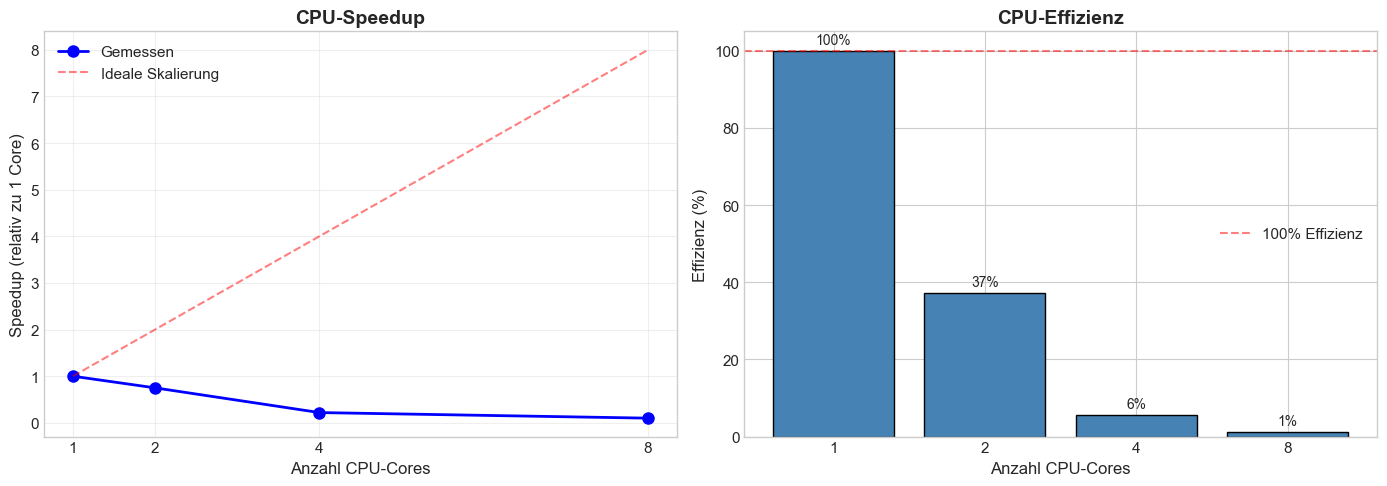

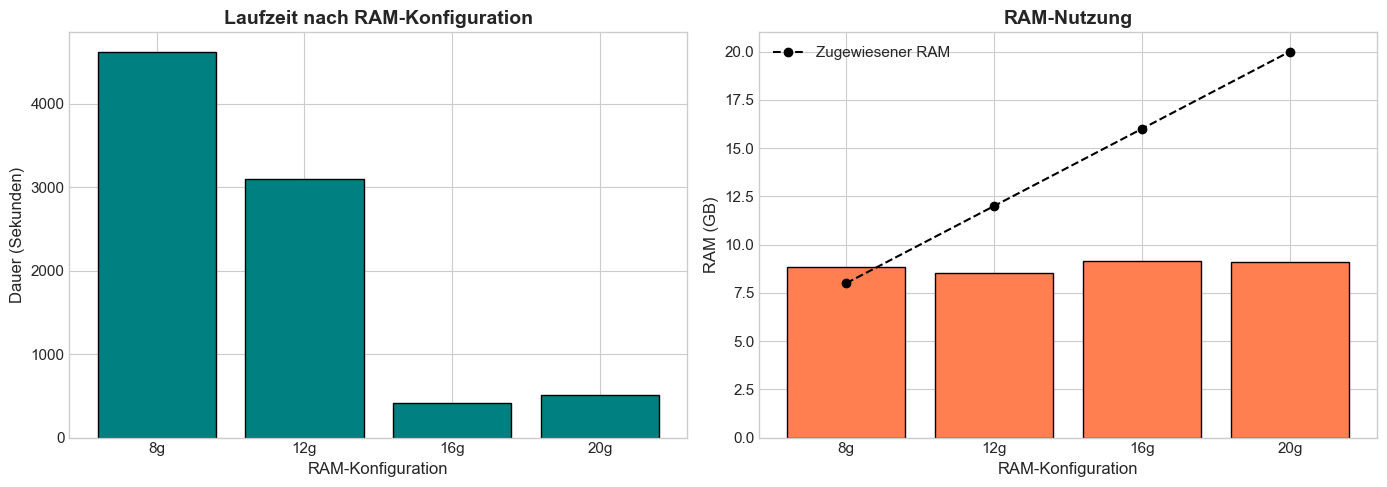

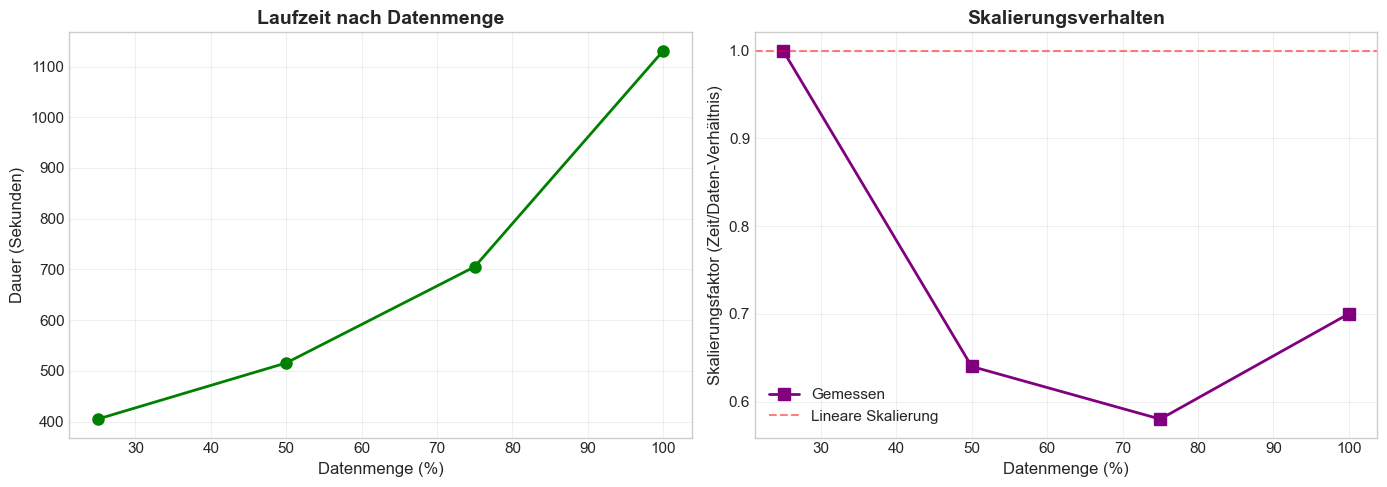

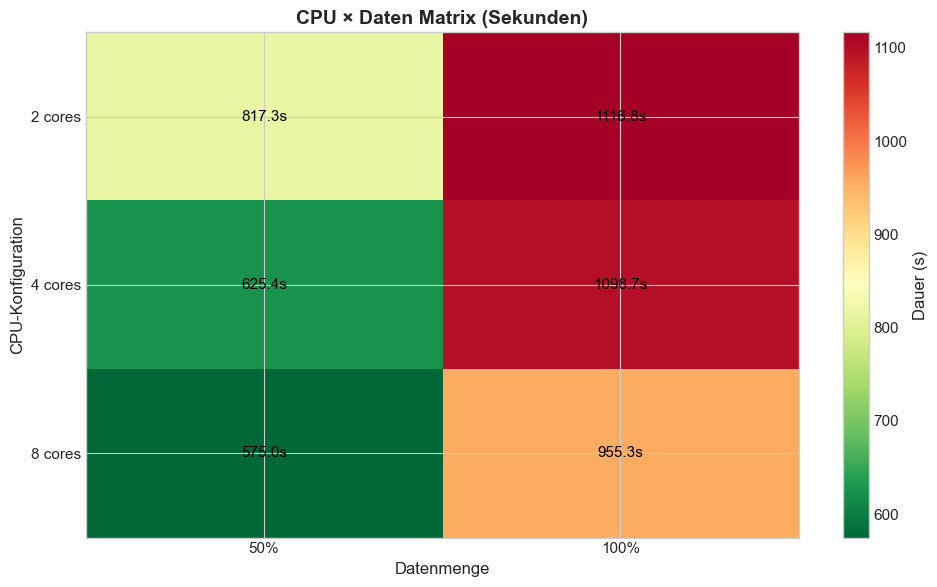

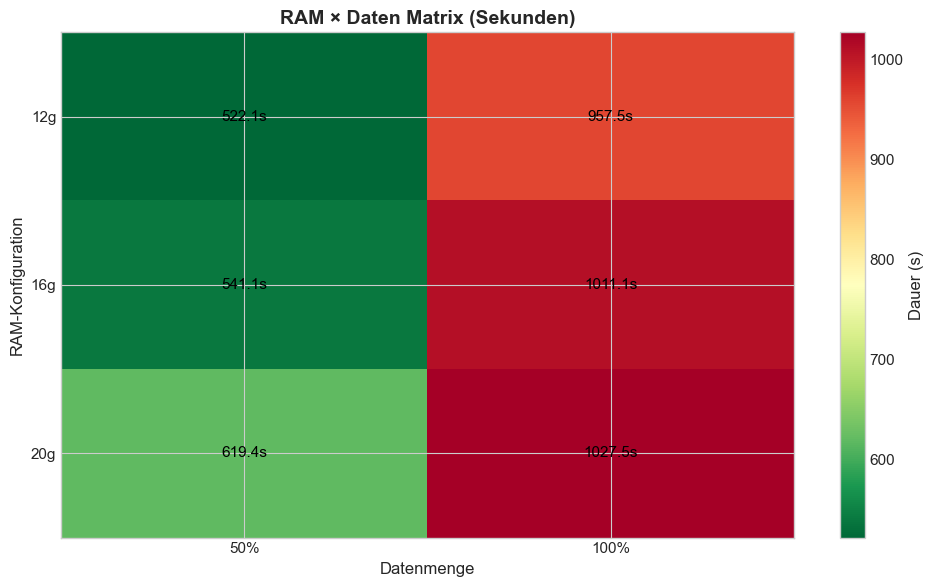

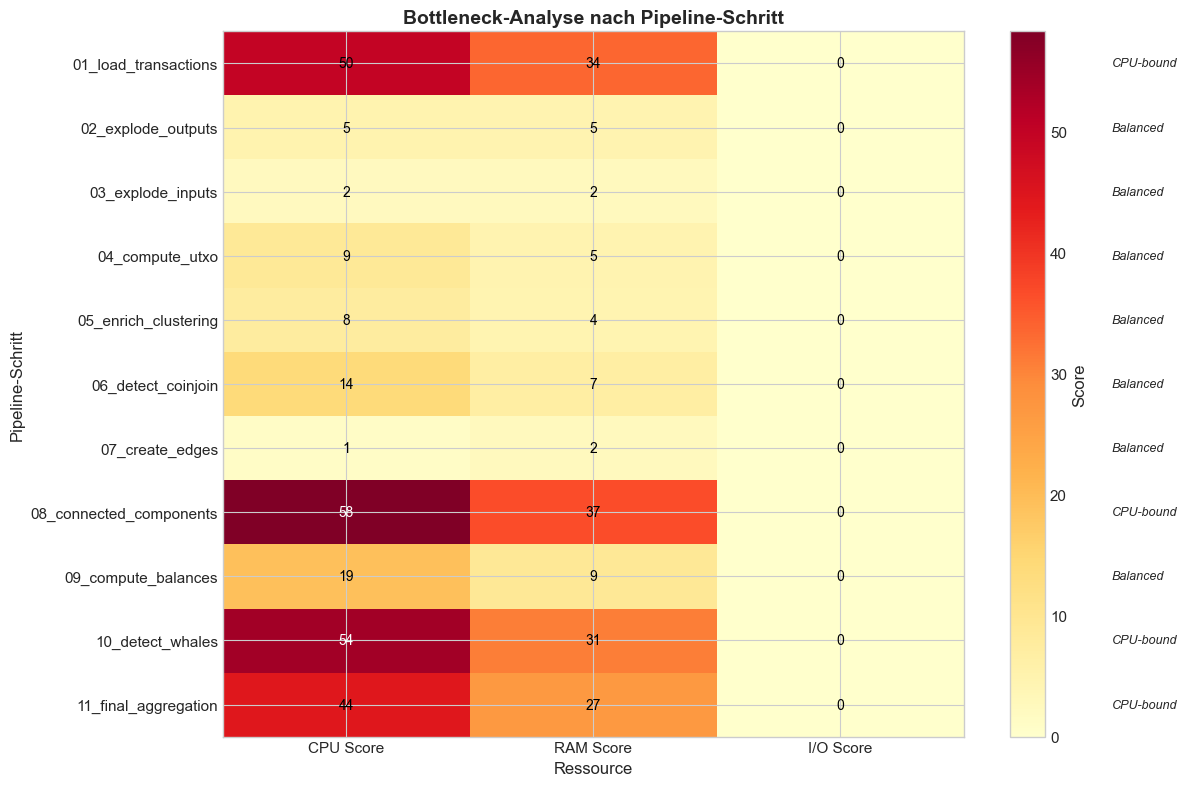

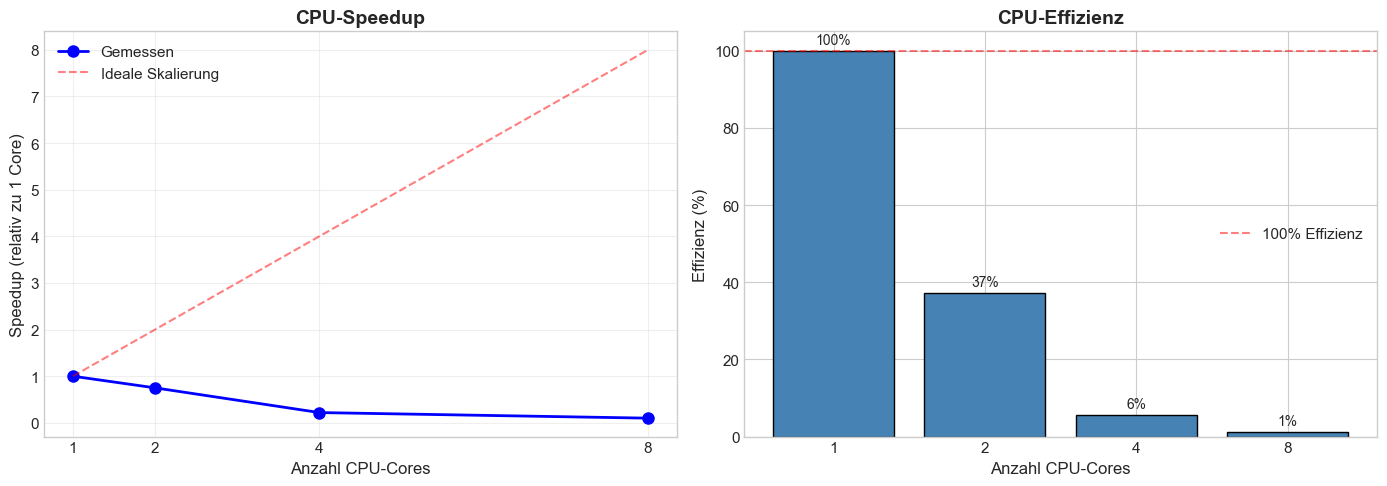

### 25.3 RAM-Skalierung Ergebnisse

,ram_config,ram_gb,duration_s,improvement_%,max_ram_used_gb
0,8g,8.000000,4626.93s,+0.0%,8.82 GB
1,12g,12.000000,3099.27s,+33.0%,8.54 GB
2,16g,16.000000,408.57s,+91.2%,9.17 GB
3,20g,20.000000,509.57s,+89.0%,9.08 GB


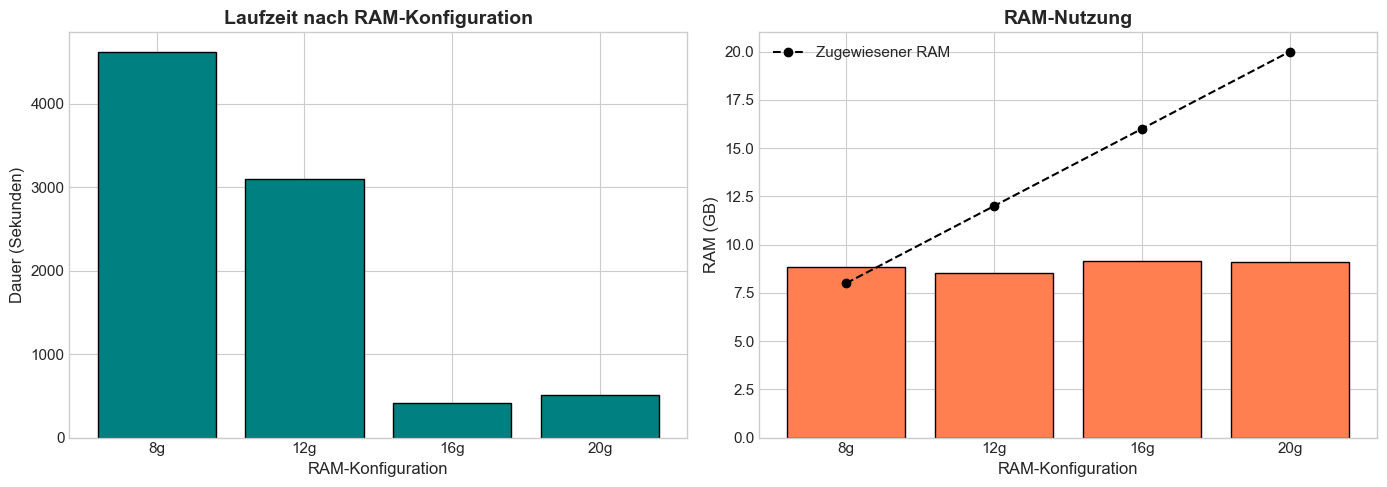

### 25.4 Daten-Skalierung Ergebnisse

,data_%,records,duration_s,data_factor,time_factor,scaling
0,25,"2,485,753",404.92s,1.00x,1.00x,1.00
1,50,"4,968,598",515.64s,2.00x,1.27x,0.64
2,75,"7,454,717",705.29s,3.00x,1.74x,0.58
3,100,"9,940,221",1131.17s,4.00x,2.79x,0.70


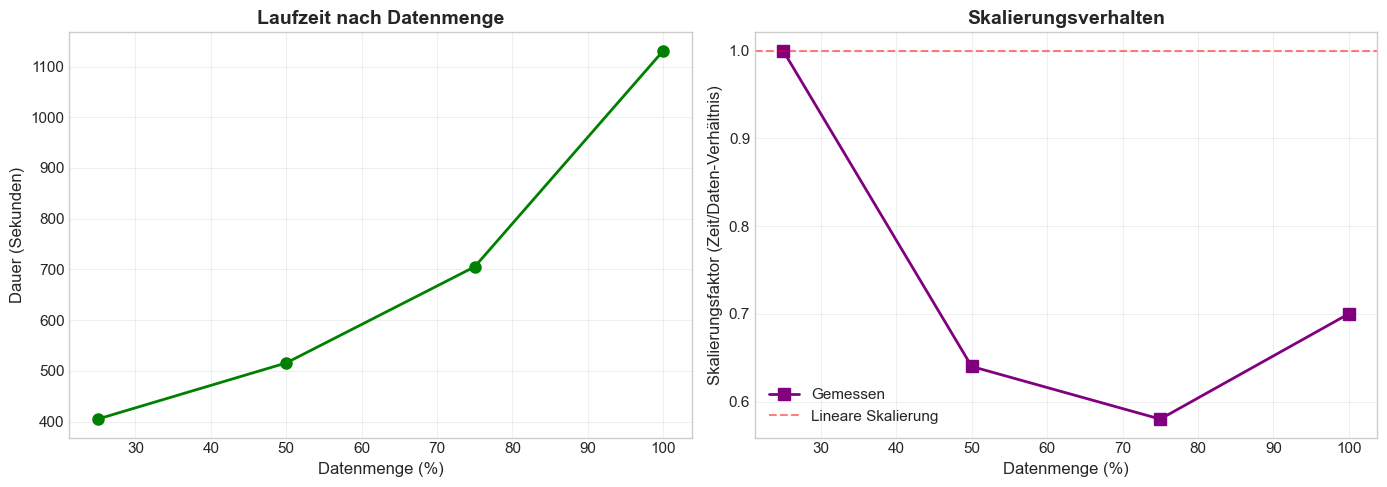

### 25.5 Kombinierte Heatmaps

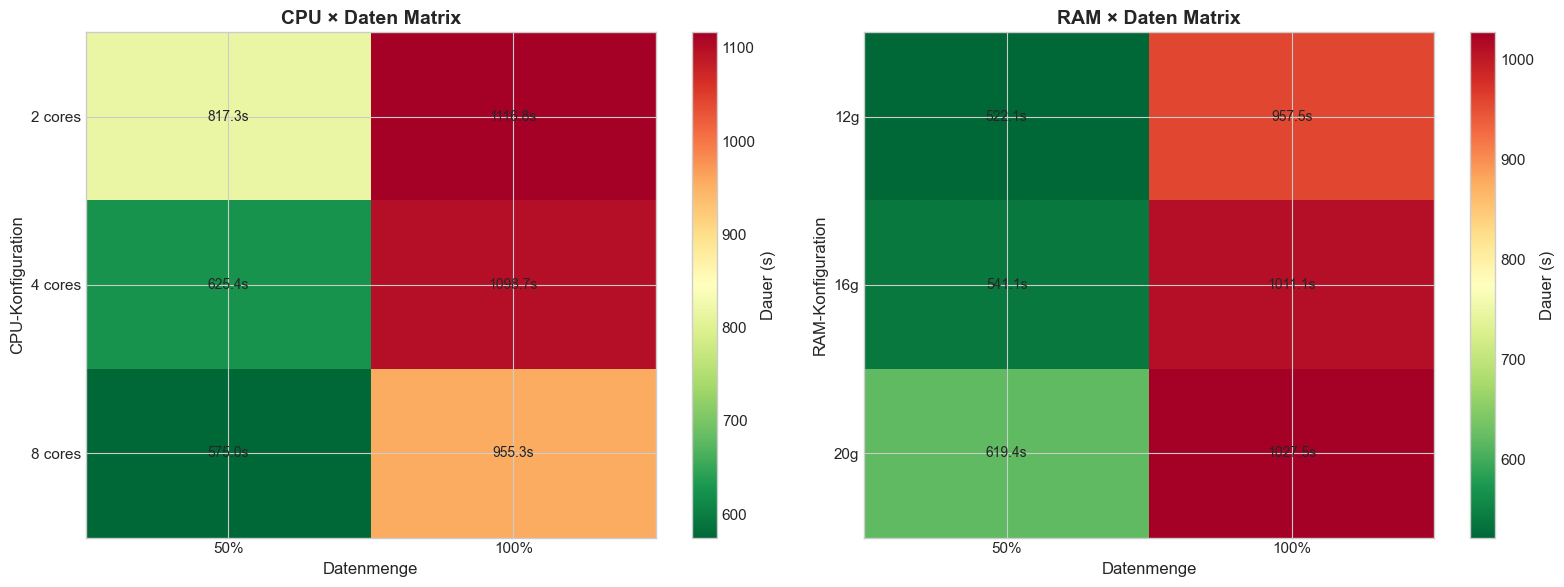

### 25.6 Bottleneck-Analyse

/var/folders/nx/qs47_8zn2jsdkcz32b7cr8_r0000gn/T/ipykernel_59123/3375000948.py:185: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled = df.style.applymap(color_bottleneck, subset=['Bottleneck'])


,Step,Bottleneck,CPU Score,RAM Score,I/O Score,Confidence
0,01_load_transactions,CPU-bound,49.800000,33.700000,0.000000,66%
1,02_explode_outputs,Balanced,4.900000,4.700000,0.000000,80%
2,03_explode_inputs,Balanced,2.100000,2.300000,0.000000,80%
3,04_compute_utxo,Balanced,8.700000,4.600000,0.000000,80%
4,05_enrich_clustering,Balanced,7.500000,4.500000,0.000000,80%
5,06_detect_coinjoin,Balanced,13.700000,6.700000,0.000000,80%
6,07_create_edges,Balanced,1.100000,2.400000,0.000000,80%
7,08_connected_components,CPU-bound,58.300000,36.600000,0.000000,72%
8,09_compute_balances,Balanced,19.200000,9.100000,0.000000,80%
9,10_detect_whales,CPU-bound,54.200000,30.800000,0.000000,73%


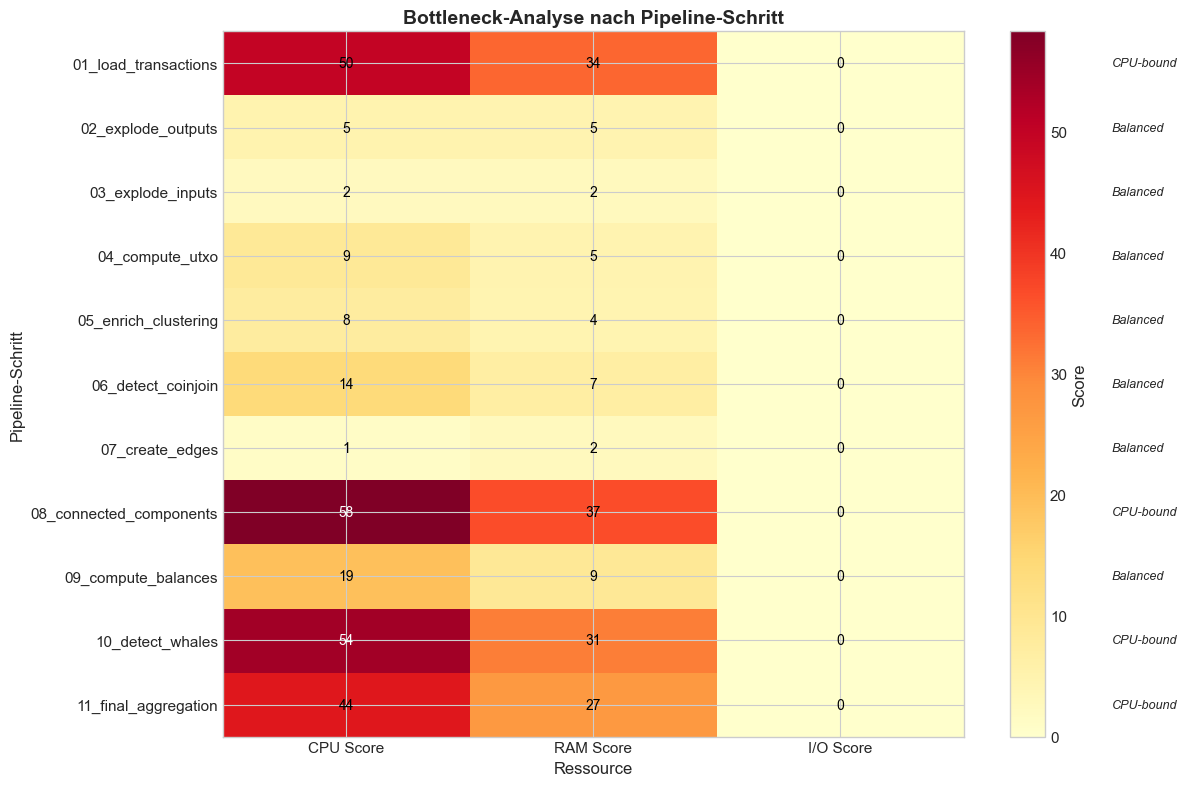

---

*Experiment abgeschlossen.*


✅ Alle Experimente abgeschlossen!
   Ergebnisse in: ../output/experiments


In [42]:
# =============================================================================
# EXPERIMENTE STARTEN
# =============================================================================
# Diese Zelle führt alle Experimente aus und zeigt die Ergebnisse an.
# Voraussetzung: EXPERIMENT_MODE=true in der .env Datei

if EXPERIMENT_MODE:
    print("🚀 Starte Experimente...")
    print(f"   CPU-Configs: {EXPERIMENT_CPU_CONFIGS}")
    print(f"   RAM-Configs: {EXPERIMENT_RAM_CONFIGS}")
    print(f"   Data-Fractions: {EXPERIMENT_DATA_FRACTIONS}")
    print(f"   Repetitions: {EXPERIMENT_REPETITIONS}")
    print()
    
    # Alle Experimente ausführen
    experiment_results = run_all_experiments()
    
    print("\n✅ Alle Experimente abgeschlossen!")
    print(f"   Ergebnisse in: {EXPERIMENT_OUTPUT_DIR}")
else:
    print("⚠️ EXPERIMENT_MODE ist deaktiviert.")
    print("   Setze EXPERIMENT_MODE=true in der .env Datei und führe das Notebook erneut aus.")
